# Análisis del impacto educacional del uso de IA

---

In [278]:
import os, sys
import polars as pl

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact_analysis import (
    group_stats,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

In [279]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,mejora,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,chat_first_timestamp,chat_last_timestamp,interactions_last_timestamp,chat_usage_time_interval,chat_mean_time_per_interaction,chat_median_time_per_interaction,interactions_usage_time_interval,consultive_chat_used,evaluator_chat_used,chat_freq_use,chat_freq_use_v2,WSDI,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,experimental_type_freq_quality_v1,experimental_type_freq_quality_v2,experimental_type_freq_quality_v3,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,bool,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,datetime[μs],datetime[μs],datetime[μs],f64,f64,f64,f64,bool,bool,str,str,f64,str,str,str,f64,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",true,"""bien""","""sobresaliente""","""18/02/2026 9:07:05""","""18/02/2026 9:43:17""",0.6,0.2,0.8,0.4,"""Media""","""Baja""","""Media""","""Baja""",1.0,0.4,1.0,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.8,0.43,0.27,"""Media""","""Media""","""Baja""",2,5,true,2026-02-18 08:28:04.426,2026-02-18 08:31:26.747,2026-02-18 08:31:26.747,3.372017,3.372017,3.372017,3.372017,true,true,"""Media""","""Baja""",2.5,"""Profunda""","""Profunda""","""true""",0.0,"""ExpBA""","""ExpMA""","""ExpBA""","""ExpBA""","""ExpMA""","""ExpBA""",36.2,"""IES Ramiro de Maeztu (Madrid)""","""Calle Serrano 127, 28006 Madri…","""1ºBACHILLERATO""",40.44281,-3.687886,2807905002,"""Madrid""","""Madrid""",44450,104774,36918
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alta""","""Baja""","""Alta""",true,"""notable""","""sobresaliente""","""18/02/2026 9:05:17""","""18/02/2026 9:43:40""",0.8,0.48,1.0,0.6,"""Alta""","""Media""","""Alta""","""Media""",1.0,0.55,1.0,1.0,"""Alta""","""Media""","""Media""","""Alta""",0.2,0.4,0.27,"""Baja""","""Media""","""Baja""",8,5,false,2026-02-18 08:12:09.910,2026-02-18 08:38:20.082,2026-02-18 08:38:20.082,26.169533,3.738505,2.646283,26.169533,true,true,"""Alta""","""Alta""",1.5,"""Superficial""","""Superficial""","""false""",0.5,"""ExpAB""","""ExpAB""","""ExpAB""","""ExpAB""","""ExpAB""","""ExpAB""",38.383333,"""IES Ramiro de Maeztu (Madrid)""","""Calle Serrano 127, 28006 Madri…","""1ºBACHILLERATO""",40.44281,-3.687886,2807905002,"""Madrid""","""Madrid""",44450,104774,36918
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",true,"""bien""","""sobresaliente""","""18/02/2026 9:05:30""","""18/02/2026 9:44:03""",0.6,0.45,0.6,0.6,"""Media""","""Media""","""Baja""","""Media""",1.0,0.4,1.0,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.57,0.6,0.47,"""Baja""","""Alta""","""Media""",7,5,true,2026-02-18 08:12:22.212,2026-02-18 08:38:32.086,2

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [280]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""experimental""",94
"""control""",97


In [281]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
null,100
"""Media""",24
"""Alta""",29
"""No Usado""",29
"""Baja""",9


In [282]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [283]:
forms_interactions_df['grupo'].value_counts().filter(pl.col('grupo') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [284]:
forms_interactions_df.filter(
    pl.col('grupo') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,mejora,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,chat_first_timestamp,chat_last_timestamp,interactions_last_timestamp,chat_usage_time_interval,chat_mean_time_per_interaction,chat_median_time_per_interaction,interactions_usage_time_interval,consultive_chat_used,evaluator_chat_used,chat_freq_use,chat_freq_use_v2,WSDI,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,experimental_type_freq_quality_v1,experimental_type_freq_quality_v2,experimental_type_freq_quality_v3,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,bool,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,datetime[μs],datetime[μs],datetime[μs],f64,f64,f64,f64,bool,bool,str,str,f64,str,str,str,f64,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [285]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,mejora,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,chat_first_timestamp,chat_last_timestamp,interactions_last_timestamp,chat_usage_time_interval,chat_mean_time_per_interaction,chat_median_time_per_interaction,interactions_usage_time_interval,consultive_chat_used,evaluator_chat_used,chat_freq_use,chat_freq_use_v2,WSDI,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,experimental_type_freq_quality_v1,experimental_type_freq_quality_v2,experimental_type_freq_quality_v3,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,bool,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,datetime[μs],datetime[μs],datetime[μs],f64,f64,f64,f64,bool,bool,str,str,f64,str,str,str,f64,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Baja""","""Baja""","""Baja""",false,"""sobresaliente""","""notable""","""11/03/2026 9:48:45""","""11/03/2026 10:27:34""",0.9,0.28,0.8,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.8,0.45,0.8,0.8,"""Media""","""Baja""","""Baja""","""Baja""",0.6,0.6,0.63,"""Baja""","""Alta""","""Alta""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,38.816667,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",false,"""notable""","""notable""","""11/03/2026 9:50:39""","""11/03/2026 10:30:02""",0.7,0.48,0.8,0.6,"""Media""","""Media""","""Media""","""Media""",0.7,0.6,0.6,0.8,"""Baja""","""Alta""","""Baja""","""Baja""",0.83,0.27,0.23,"""Media""","""Baja""","""Baja""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.383333,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Baja""","""Baja""","""Baja""",false,"""bien""","""suspenso""","""11/03/2026 9:47:27""","""11/03/2026 10:30:45""",0.6,0.45,0.8,0.4,"""Media""","""Media""","""Media""","""Baja""",0.1,0.48,0.2,0.0,"""Baja""","""Media""","""Baja""","""Baja""",0.6,0.63,0.6,"""Baja""","""Alta""","""Alta""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,43.3,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571


In [286]:
problematic_experimental_ids = forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

---

## Valores únicos

In [287]:
for col in forms_interactions_df.columns:
    print(col.upper())
    display(forms_interactions_df[col].unique().to_list())
    print('-' * 100)

ID


['RamiroMaeztu-hka',
 'RamiroMaeztu-80a',
 'JesusMaria-o95',
 'RamiroMaeztu-8jb',
 'JesusMaria-l57',
 'Laguna-p8n',
 'Laguna-mzg',
 'Laguna-rjb',
 'RamiroMaeztu-st5',
 'JoseGarciaNieto-p5c',
 'Laguna-pt8',
 'JesusMaria-s17',
 'Laguna-wk5',
 'Laguna-lqw',
 'Laguna-9wq',
 'RamiroMaeztu-zhk',
 'JoseGarciaNieto-yhk',
 'JesusMaria-hem',
 'JesusMaria-am7',
 'JoseGarciaNieto-78x',
 'Laguna-wct',
 'Laguna-yp1',
 'JesusMaria-ecq',
 'Laguna-uvx',
 'Laguna-u0e',
 'JesusMaria-xpe',
 'Laguna-yfr',
 'JesusMaria-jxz',
 'RamiroMaeztu-z2k',
 'JoseGarciaNieto-5r5',
 'JoseGarciaNieto-5zg',
 'RamiroMaeztu-skl',
 'RamiroMaeztu-cpk',
 'JesusMaria-bbc',
 'JesusMaria-hs2',
 'Laguna-2al',
 'Laguna-6vh',
 'JoseGarciaNieto-8k0',
 'RamiroMaeztu-bzv',
 'RamiroMaeztu-mw7',
 'RamiroMaeztu-ywi',
 'JoseGarciaNieto-r6z',
 'JesusMaria-3ci',
 'RamiroMaeztu-h3l',
 'JesusMaria-a6g',
 'RamiroMaeztu-5yc',
 'Laguna-q74',
 'RamiroMaeztu-08k',
 'Laguna-bej',
 'Laguna-chn',
 'RamiroMaeztu-4ux',
 'RamiroMaeztu-qzw',
 'JesusMaria-

----------------------------------------------------------------------------------------------------
CENTRO


['RamiroMaeztu', 'JoseGarciaNieto', 'Laguna', 'JesusMaria']

----------------------------------------------------------------------------------------------------
GRUPO


...

----------------------------------------------------------------------------------------------------
RENTA_MEDIA_HOGAR_EUR


[None, 28072, 34137, 104774]

----------------------------------------------------------------------------------------------------
RENTA_MEDIA_PERSONA_EUR


[None, 11432, 11571, 36918]

----------------------------------------------------------------------------------------------------


---

## Descripción general

In [288]:
forms_interactions_df.describe()

statistic,id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,mejora,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,chat_first_timestamp,chat_last_timestamp,interactions_last_timestamp,chat_usage_time_interval,chat_mean_time_per_interaction,chat_median_time_per_interaction,interactions_usage_time_interval,consultive_chat_used,evaluator_chat_used,chat_freq_use,chat_freq_use_v2,WSDI,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,experimental_type_freq_quality_v1,experimental_type_freq_quality_v2,experimental_type_freq_quality_v3,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,str,f64,f64,f64,str,str,str,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,str,str,str,f64,str,str,str,str,str,str,f64,str,str,str,f64,f64,f64,str,str,f64,f64,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",91.0,91.0,85.0,"""62""","""62""","""89""",62.0,53.0,53.0,62.0,91.0,91.0,"""91""","""91""",62.0,"""91""","""91""","""91""",62.0,"""91""","""91""","""91""","""188""","""188""","""188""",191.0,"""163""","""163""","""163""",163.0,163.0,163.0,"""163""","""163""",163.0,163.0,163.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",100.0,100.0,106.0,"""129""","""129""","""102""",129.0,138.0,138.0,129.0,100.0,100.0,"""100""","""100""",129.0,"""100""","""100""","""100""",129.0,"""100""","""100""","""100""","""3""","""3""","""3""",0.0,"""28""","""28""","""28""",28.0,28.0,28.0,"""28""","""28""",28.0,28.0,28.0
"""mean""",null,null,null,0.312508,0.209445,0.417984,null,null,null,0.717277,null,null,null,null,0.60733,0.438901,0.684817,0.529843,null,null,null,null,0.764921,0.504241,0.774869,0.754974,null,null,null,null,0.727016,0.403822,0.383194,null,null,null,2.516484,4.67033,0.505882,"""2026-03-11 01:25:18.330354""","""2026-03-11 01:34:25.646435""","""2026-03-09 14:32:29.879157""",9.121935,4.150999,3.71129,17.171322,0.681319,0.934066,null,null,1.737468,null,null,null,0.367665,null,null,null,null,null,null,32.646248,null,null,null,40.399811,-3.678199,2.8075e9,null,null,26842.638037,59652.404908,21326.760736
"""std""",null,null,null,0.632694,0.839672,0.507239,null,null,null,null,null,null,null,null,0.182234,0.128556,0.232447,0.218847,null,null,null,null,0.175843,0.117421,0.227103,0.207907,null,null,null,null,0.179405,0.215019,0.185973,null,null,null,2.583549,1.247709,null,null,null,null,7.402997,2.955282,3.065589,6.120403,null,null,null,null,0.70161,null,null

---

## Análisis de resultados


In [289]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

context_cols = ['centro', 'grupo']

centros_cols = [ 
    'nombre',
    'direccion',
    'curso',
    'lat',
    'lon',
    'seccion_censal',
    'municipio',
    'provincia',
    'mediana_renta_uc_eur',
    'renta_media_hogar_eur',
    'renta_media_persona_eur'
]

time_cols = [col for col in forms_interactions_df.columns if 'temp' in col or 'time' in col]

group_segmented_cols = [ 
    'grupo_segmented_v1',
    'grupo_segmented_v2',
    'grupo_segmented_v3',
    'grupo_segmented_v4'
]

forms_cols = [col for col in forms_interactions_df.columns if 'puntuacion' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + centros_cols + time_cols + group_segmented_cols + ['id']]
chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

In [290]:
context_cols

['centro', 'grupo']

In [291]:
centros_cols

['nombre',
 'direccion',
 'curso',
 'lat',
 'lon',
 'seccion_censal',
 'municipio',
 'provincia',
 'mediana_renta_uc_eur',
 'renta_media_hogar_eur',
 'renta_media_persona_eur']

In [292]:
time_cols

['marca temporal_pre',
 'marca temporal_post',
 'chat_first_timestamp',
 'chat_last_timestamp',
 'interactions_last_timestamp',
 'chat_usage_time_interval',
 'chat_mean_time_per_interaction',
 'chat_median_time_per_interaction',
 'interactions_usage_time_interval',
 'pre_post_time_interval']

In [293]:
forms_cols

['puntuacion_tc_hake_gain',
 'puntuacion_tc_retencion_hake_gain',
 'puntuacion_tc_transferencia_hake_gain',
 'puntuacion_tc_hake_gain_cat',
 'puntuacion_tc_retencion_hake_gain_cat',
 'puntuacion_tc_transferencia_hake_gain_cat',
 'puntuacion_tc_cat_trad_scale_pre',
 'puntuacion_tc_cat_trad_scale_post',
 'puntuacion_tc_pre',
 'puntuacion_ta_pre',
 'puntuacion_tc_retencion_pre',
 'puntuacion_tc_transferencia_pre',
 'puntuacion_tc_cat_pre',
 'puntuacion_ta_cat_pre',
 'puntuacion_tc_retencion_cat_pre',
 'puntuacion_tc_transferencia_cat_pre',
 'puntuacion_tc_post',
 'puntuacion_ta_post',
 'puntuacion_tc_retencion_post',
 'puntuacion_tc_transferencia_post',
 'puntuacion_tc_cat_post',
 'puntuacion_ta_cat_post',
 'puntuacion_tc_retencion_cat_post',
 'puntuacion_tc_transferencia_cat_post',
 'puntuacion_tcc_rel_post',
 'puntuacion_tcc_int_post',
 'puntuacion_tcc_ext_post',
 'puntuacion_tcc_rel_cat_post',
 'puntuacion_tcc_int_cat_post',
 'puntuacion_tcc_ext_cat_post']

In [294]:
chats_cols

['mejora',
 'chat_interactions_counts',
 'evaluation_answers_counts',
 'evaluation_pass',
 'consultive_chat_used',
 'evaluator_chat_used',
 'chat_freq_use',
 'chat_freq_use_v2',
 'WSDI',
 'WSDI_cat',
 'WSDI_cat_v2',
 'high_quality_use',
 'cheating_score_llm',
 'experimental_type_freq_quality_v1',
 'experimental_type_freq_quality_v2',
 'experimental_type_freq_quality_v3']

In [295]:
group_segmented_cols

['grupo_segmented_v1',
 'grupo_segmented_v2',
 'grupo_segmented_v3',
 'grupo_segmented_v4']

### Variables de contexto

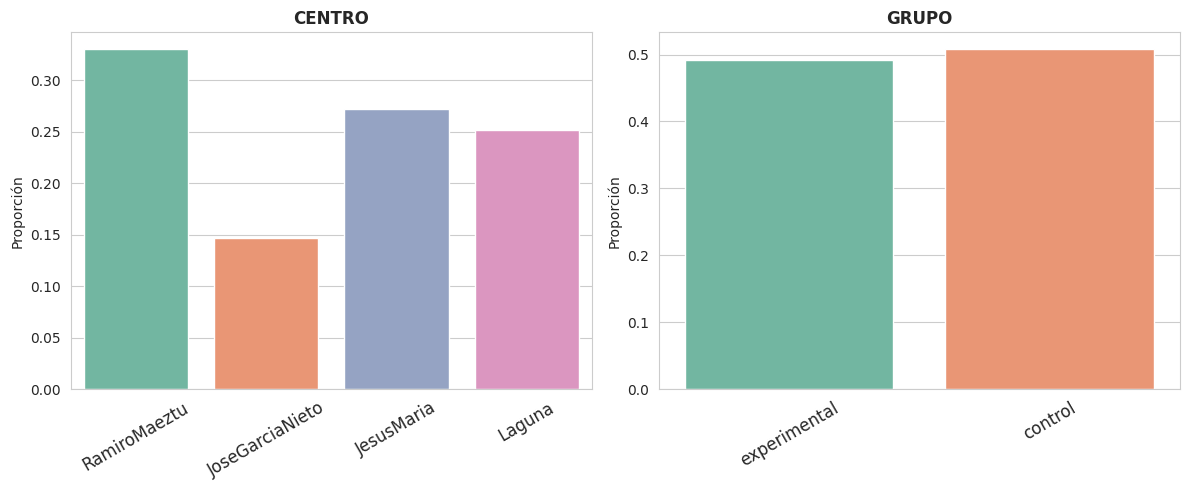

In [296]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = context_cols, 
    max_cols=3, 
    palette="Set2",
)

### Métricas de Rendimiento Forms

#### TC-Hake

In [297]:
analysis_quant_cols = [col for col in forms_quant_cols if 'hake' in col]
analysis_cat_cols = [col for col in forms_cat_cols if 'hake' in col]

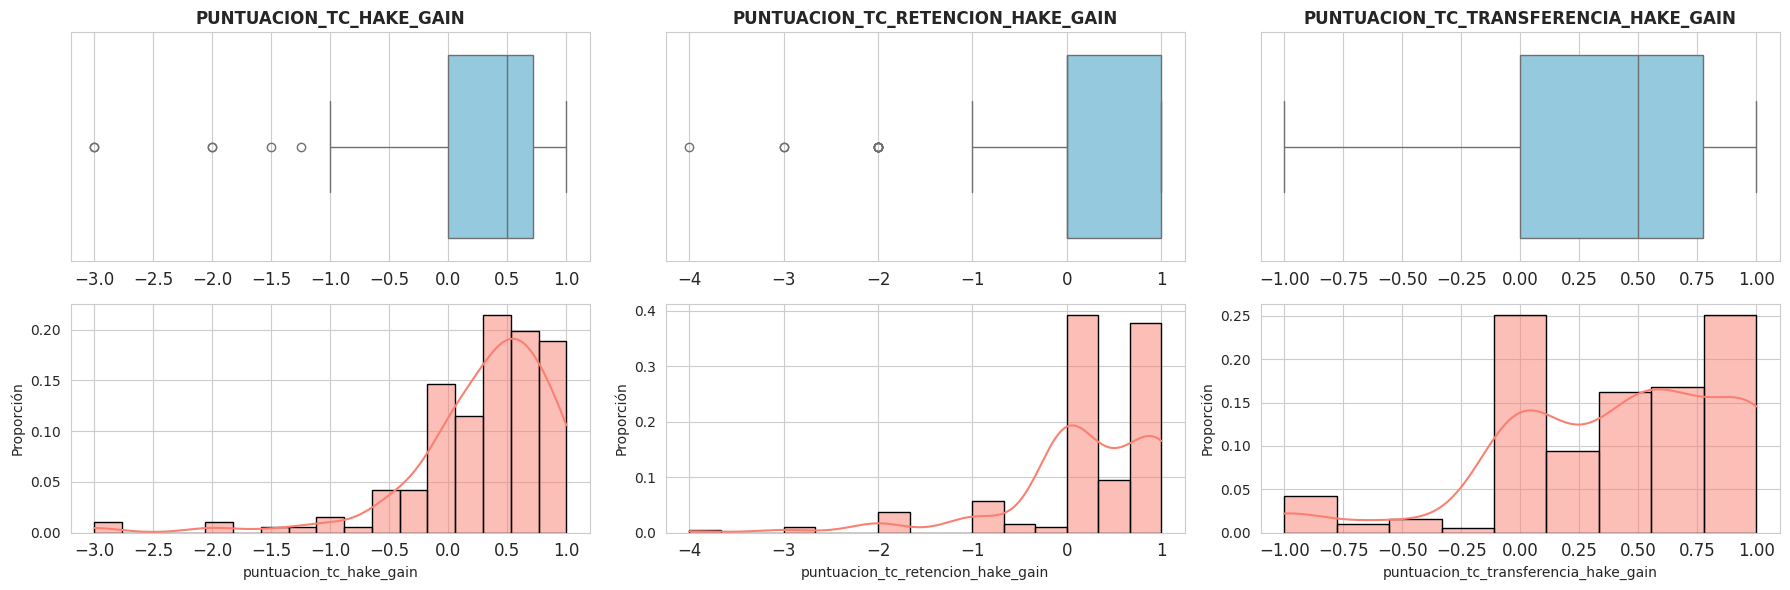

In [298]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = analysis_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

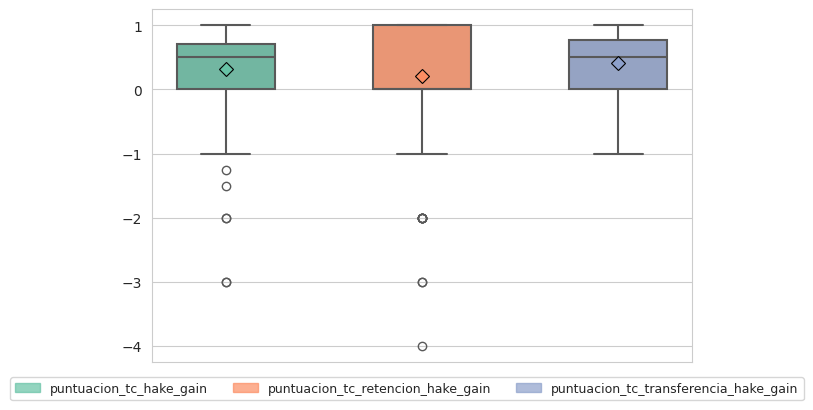

In [299]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    showfliers=True,
    title=False,
    labelbottom=False
)

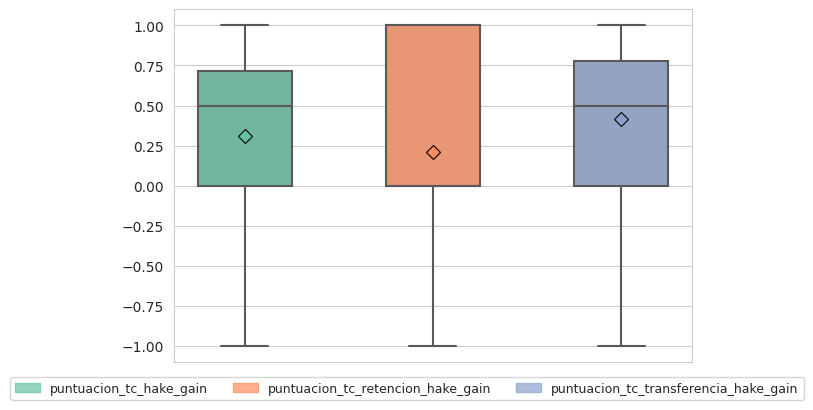

In [300]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    showfliers=False,
    title=False,
    labelbottom=False
)

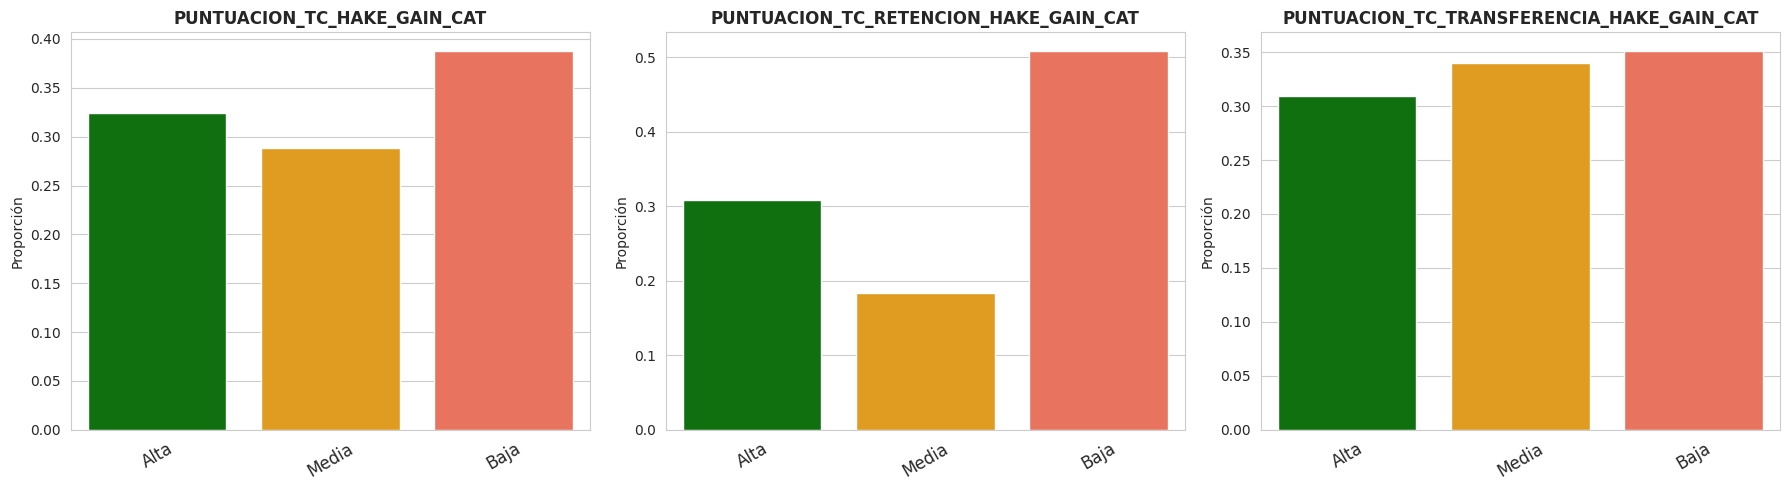

In [301]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = analysis_cat_cols, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
    max_cols=3
)

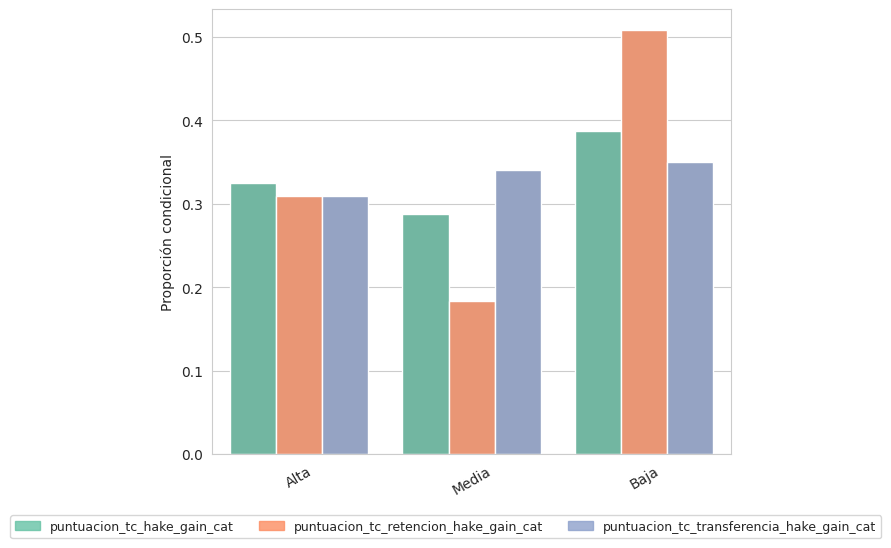

In [302]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        analysis_cat_cols
    ], 
    title=False,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja']
)


#### TC-Pre

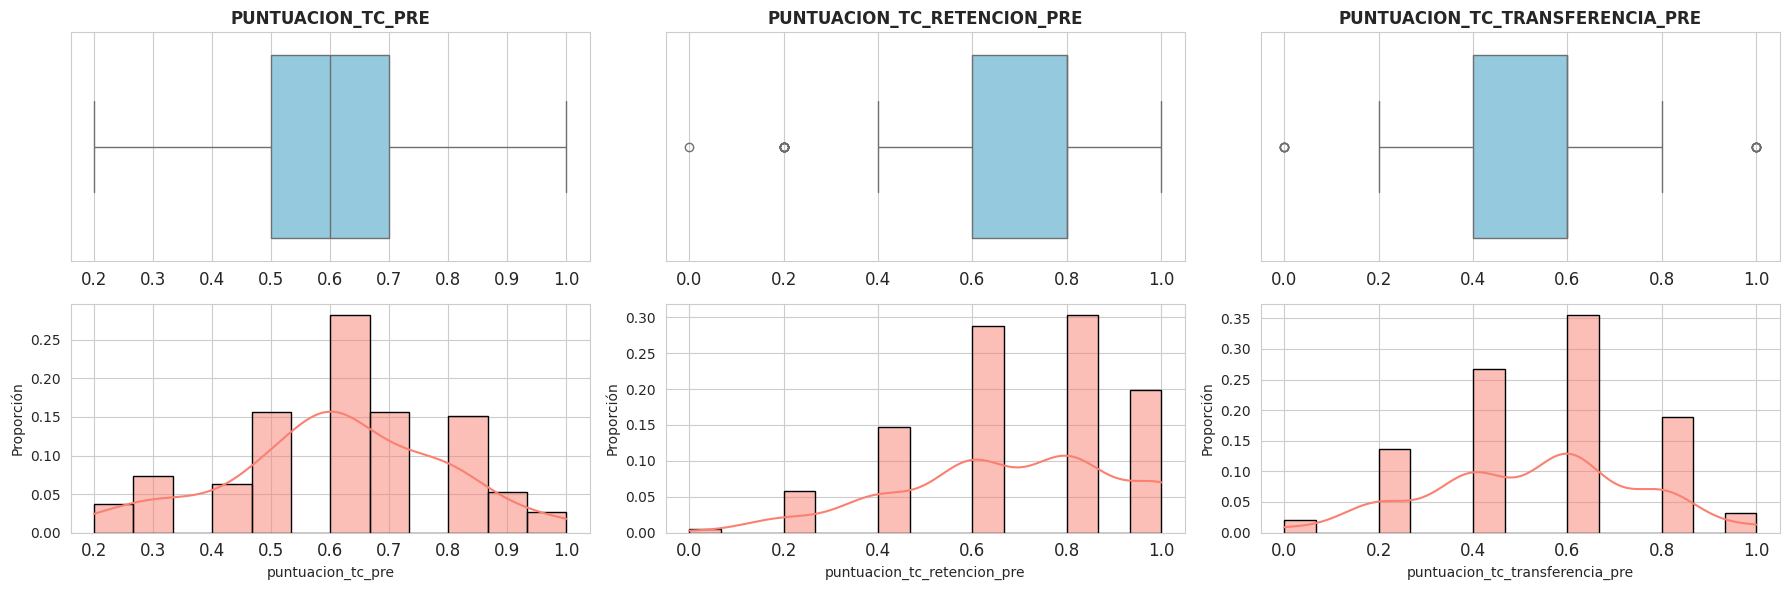

In [303]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

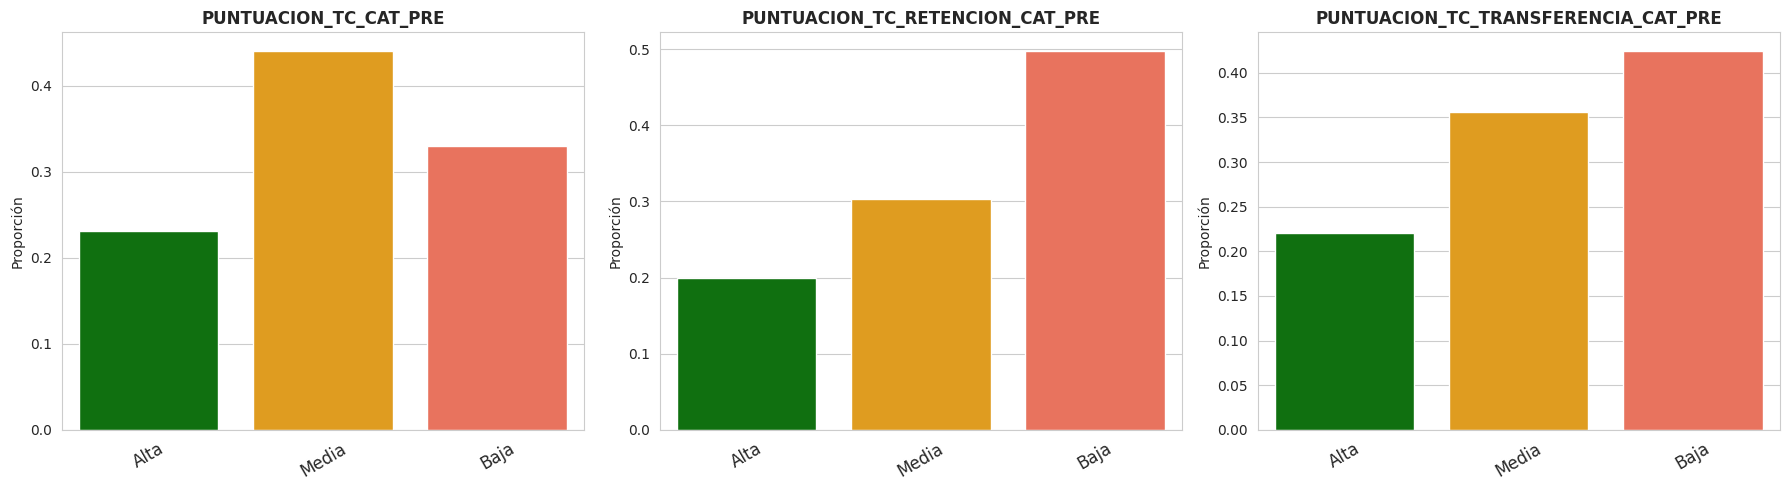

In [304]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col and col != 'puntuacion_tc_cat_trad_scale_pre'], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

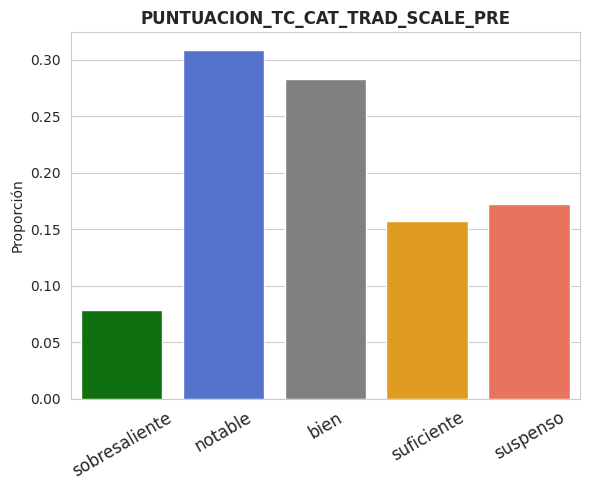

In [305]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ['puntuacion_tc_cat_trad_scale_pre'], 
    max_cols=3, 
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso'],
    palette={'sobresaliente': 'green', 'notable': 'royalblue', 'bien': 'gray', 'suficiente': 'orange', 'suspenso': 'tomato'},
)

#### TC-Post

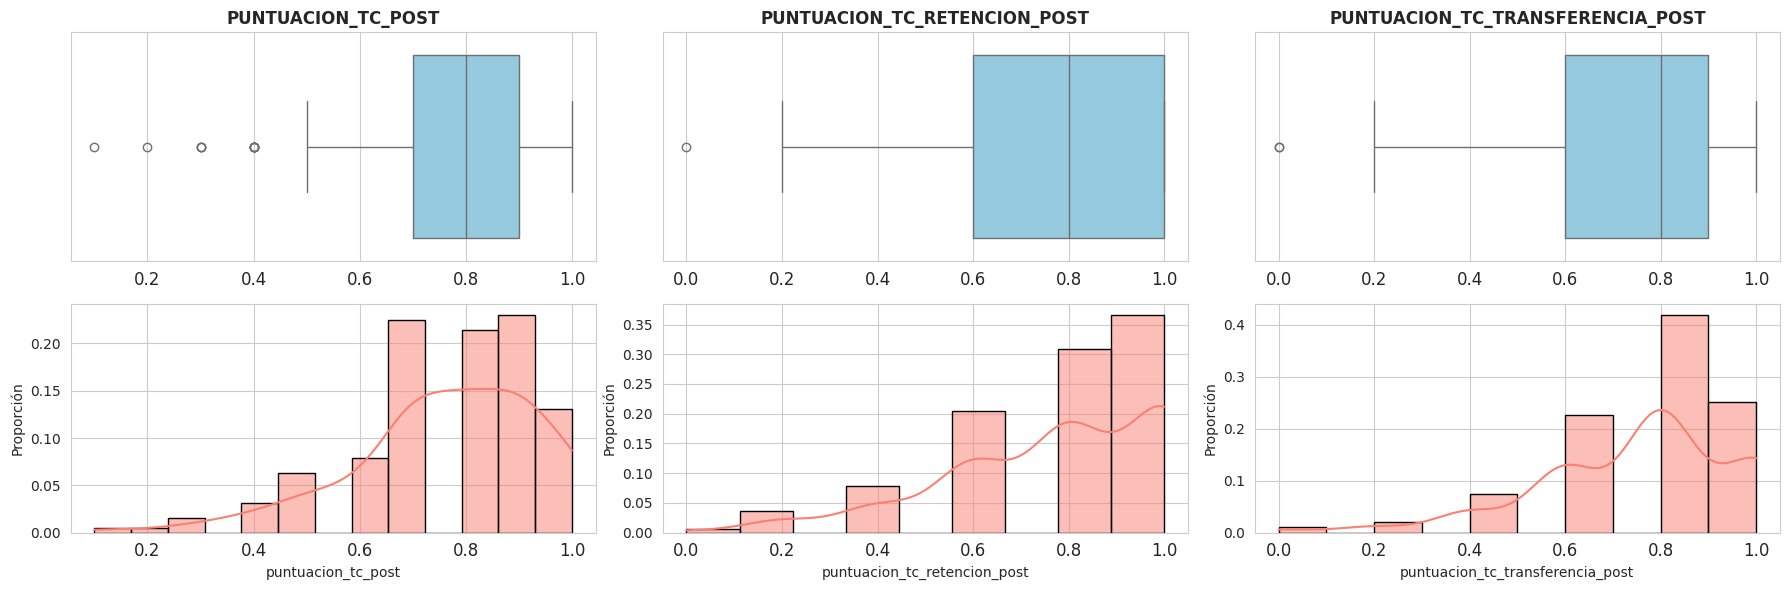

In [306]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

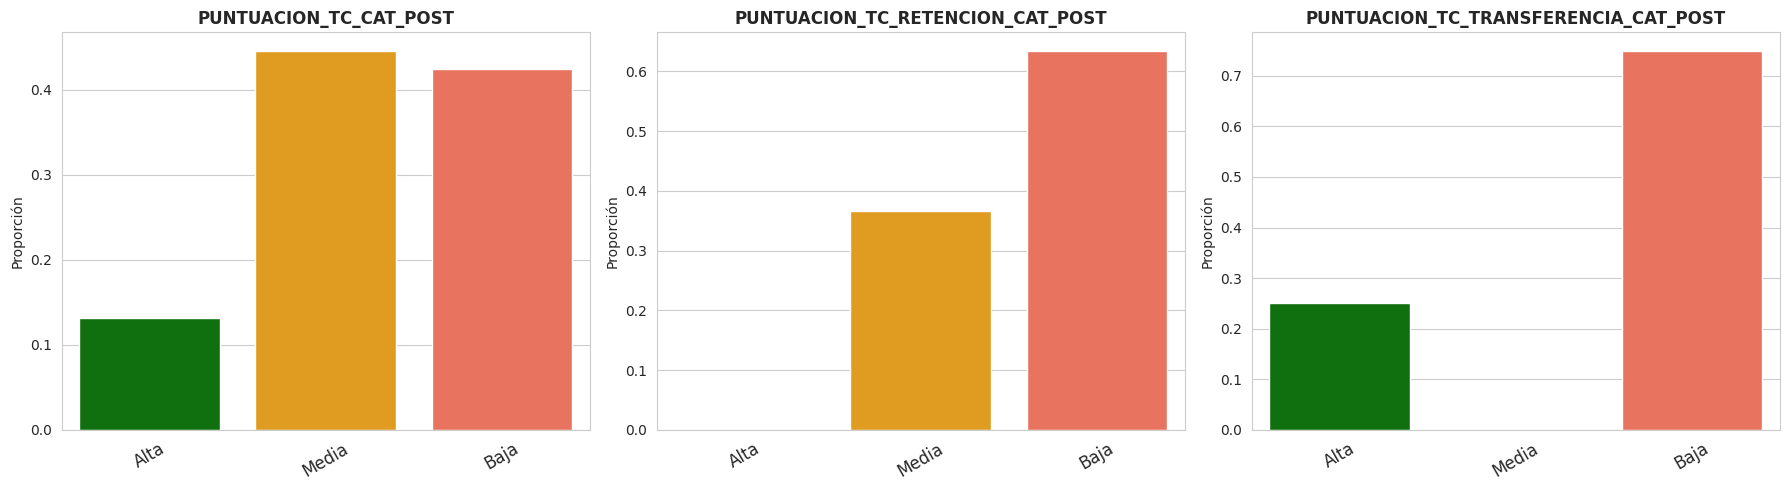

In [307]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col and col != 'puntuacion_tc_cat_trad_scale_post'], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

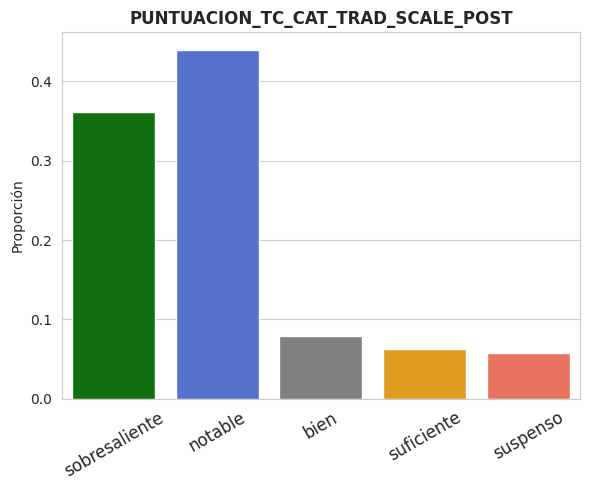

In [308]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ['puntuacion_tc_cat_trad_scale_post'], 
    max_cols=3, 
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso'],
    palette={'sobresaliente': 'green', 'notable': 'royalblue', 'bien': 'gray', 'suficiente': 'orange', 'suspenso': 'tomato'},
)

#### TC-Pre-Post Mejora

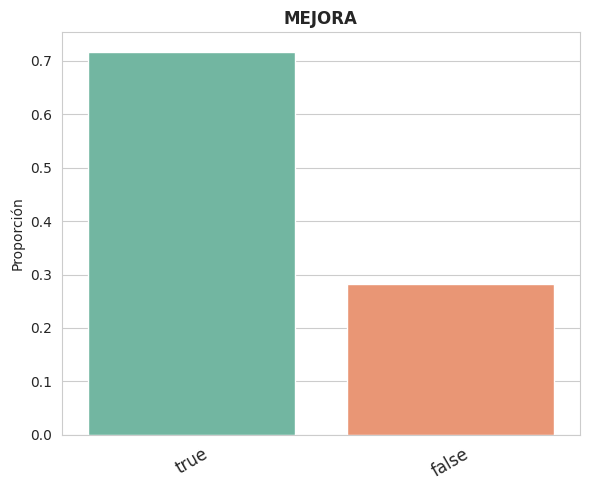

In [309]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ['mejora'], 
    max_cols=3, 
)

#### TA-Pre-Post

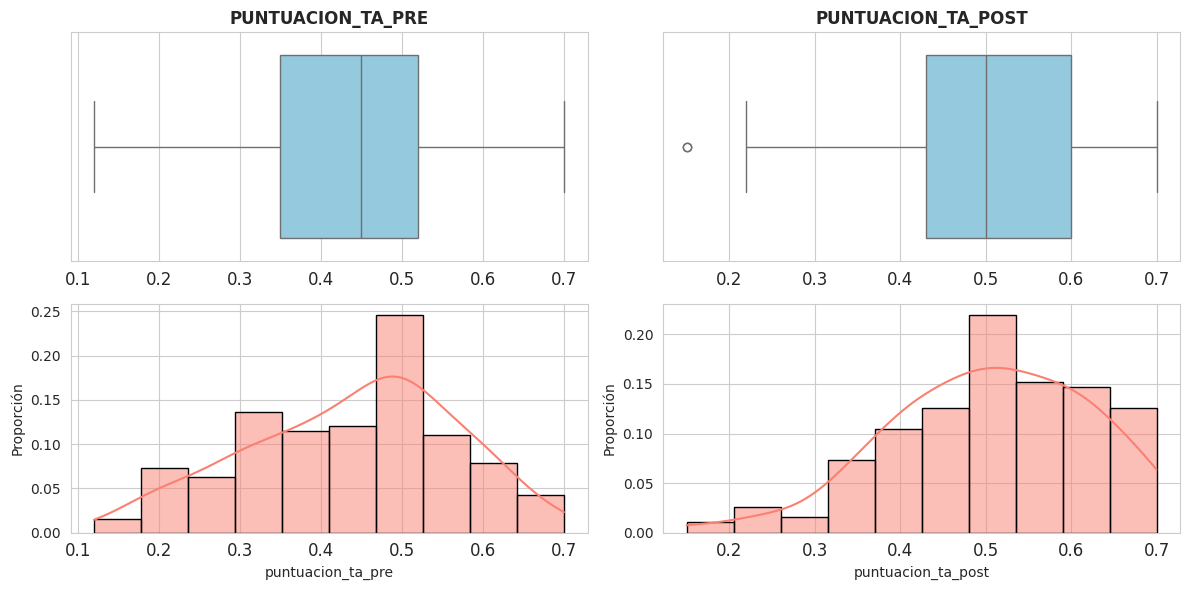

In [310]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'ta_' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

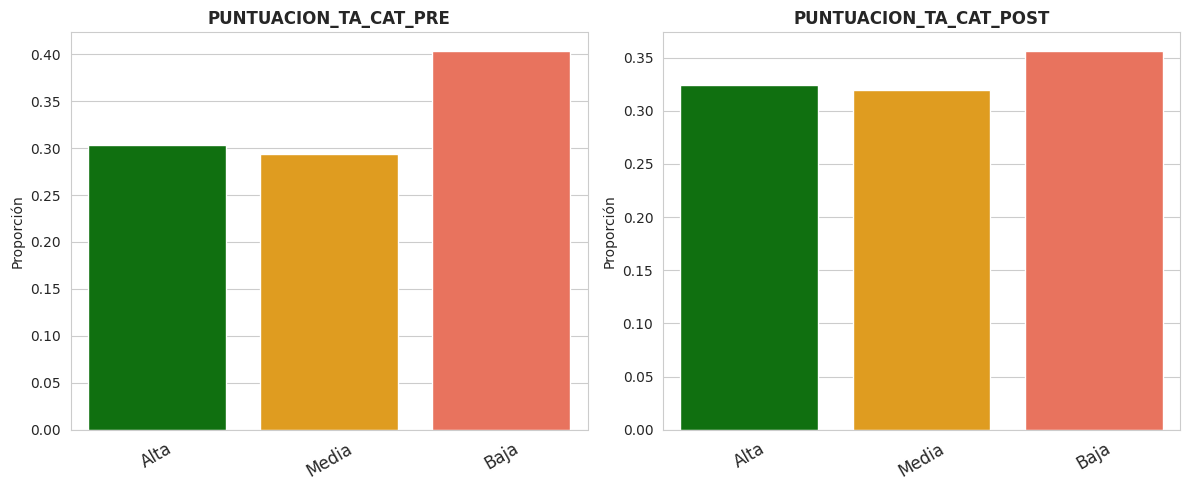

In [311]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'ta_' in col], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

#### TCC-Post

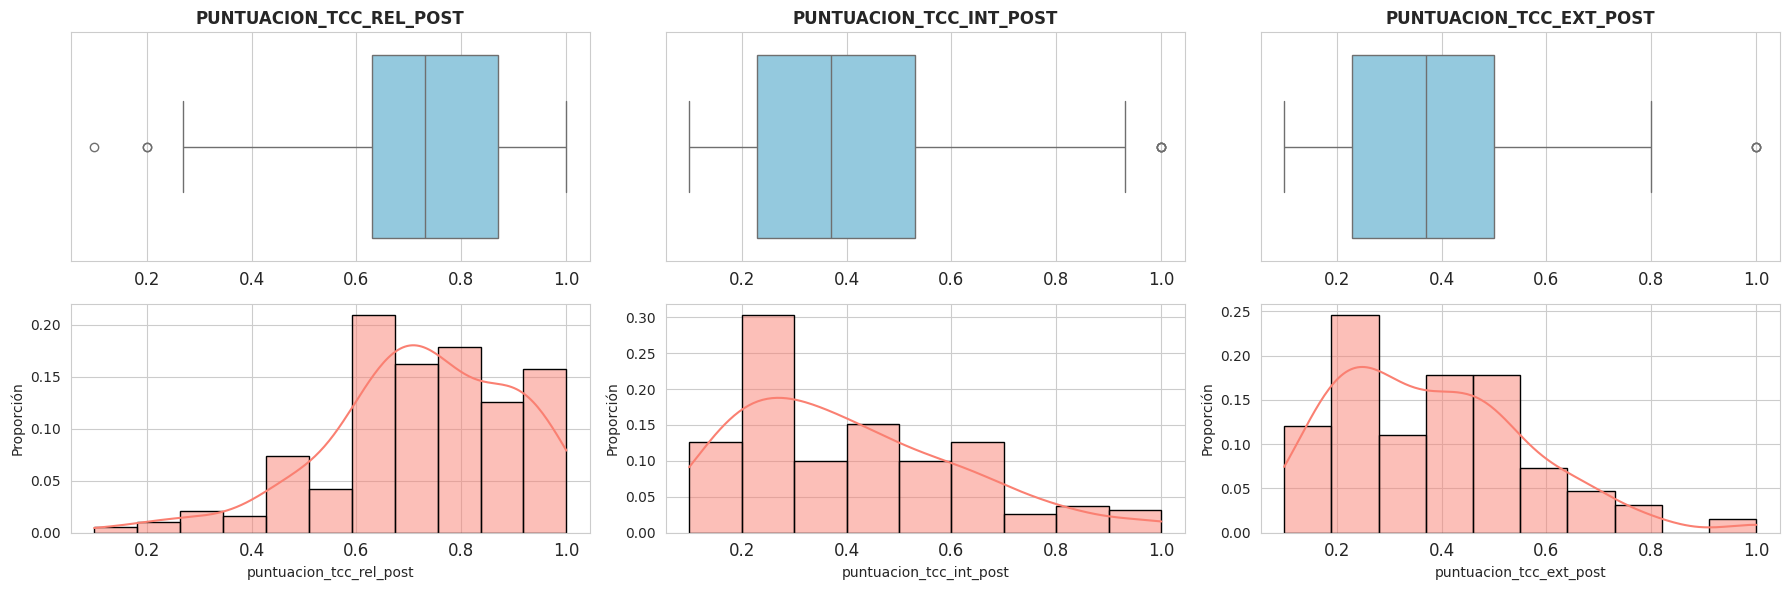

In [312]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tcc_' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

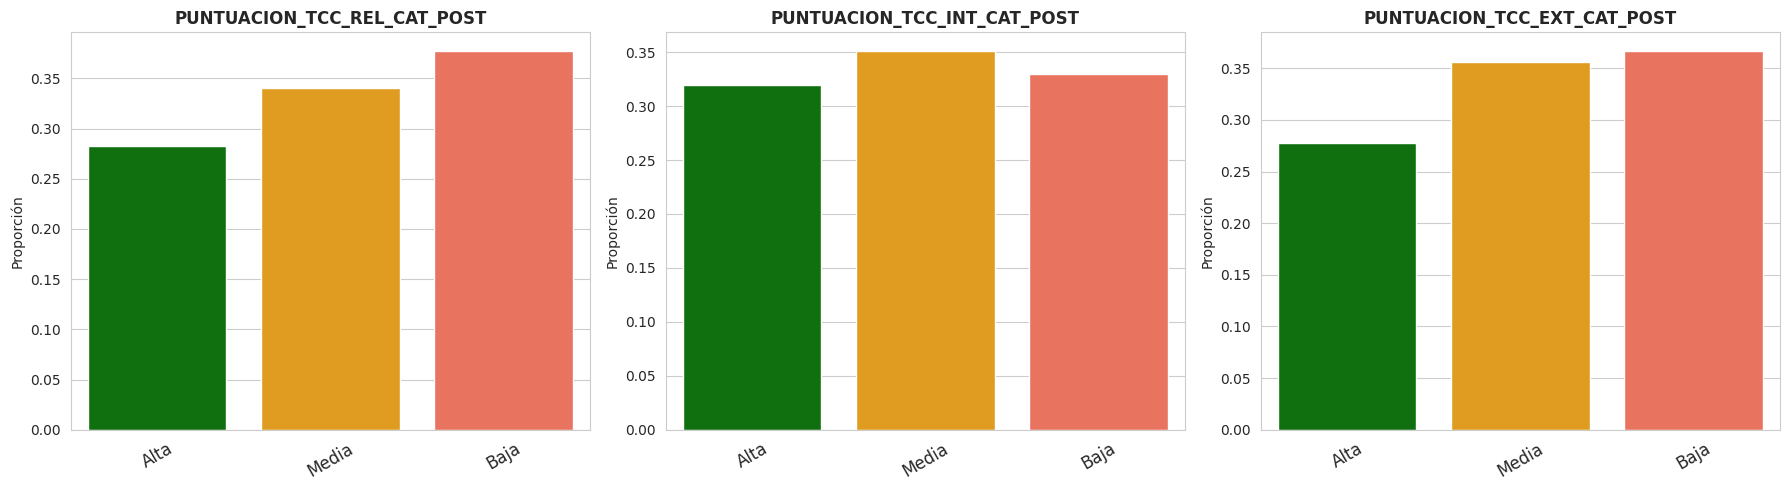

In [313]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tcc_' in col], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

### Métricas Interacciones Herramienta

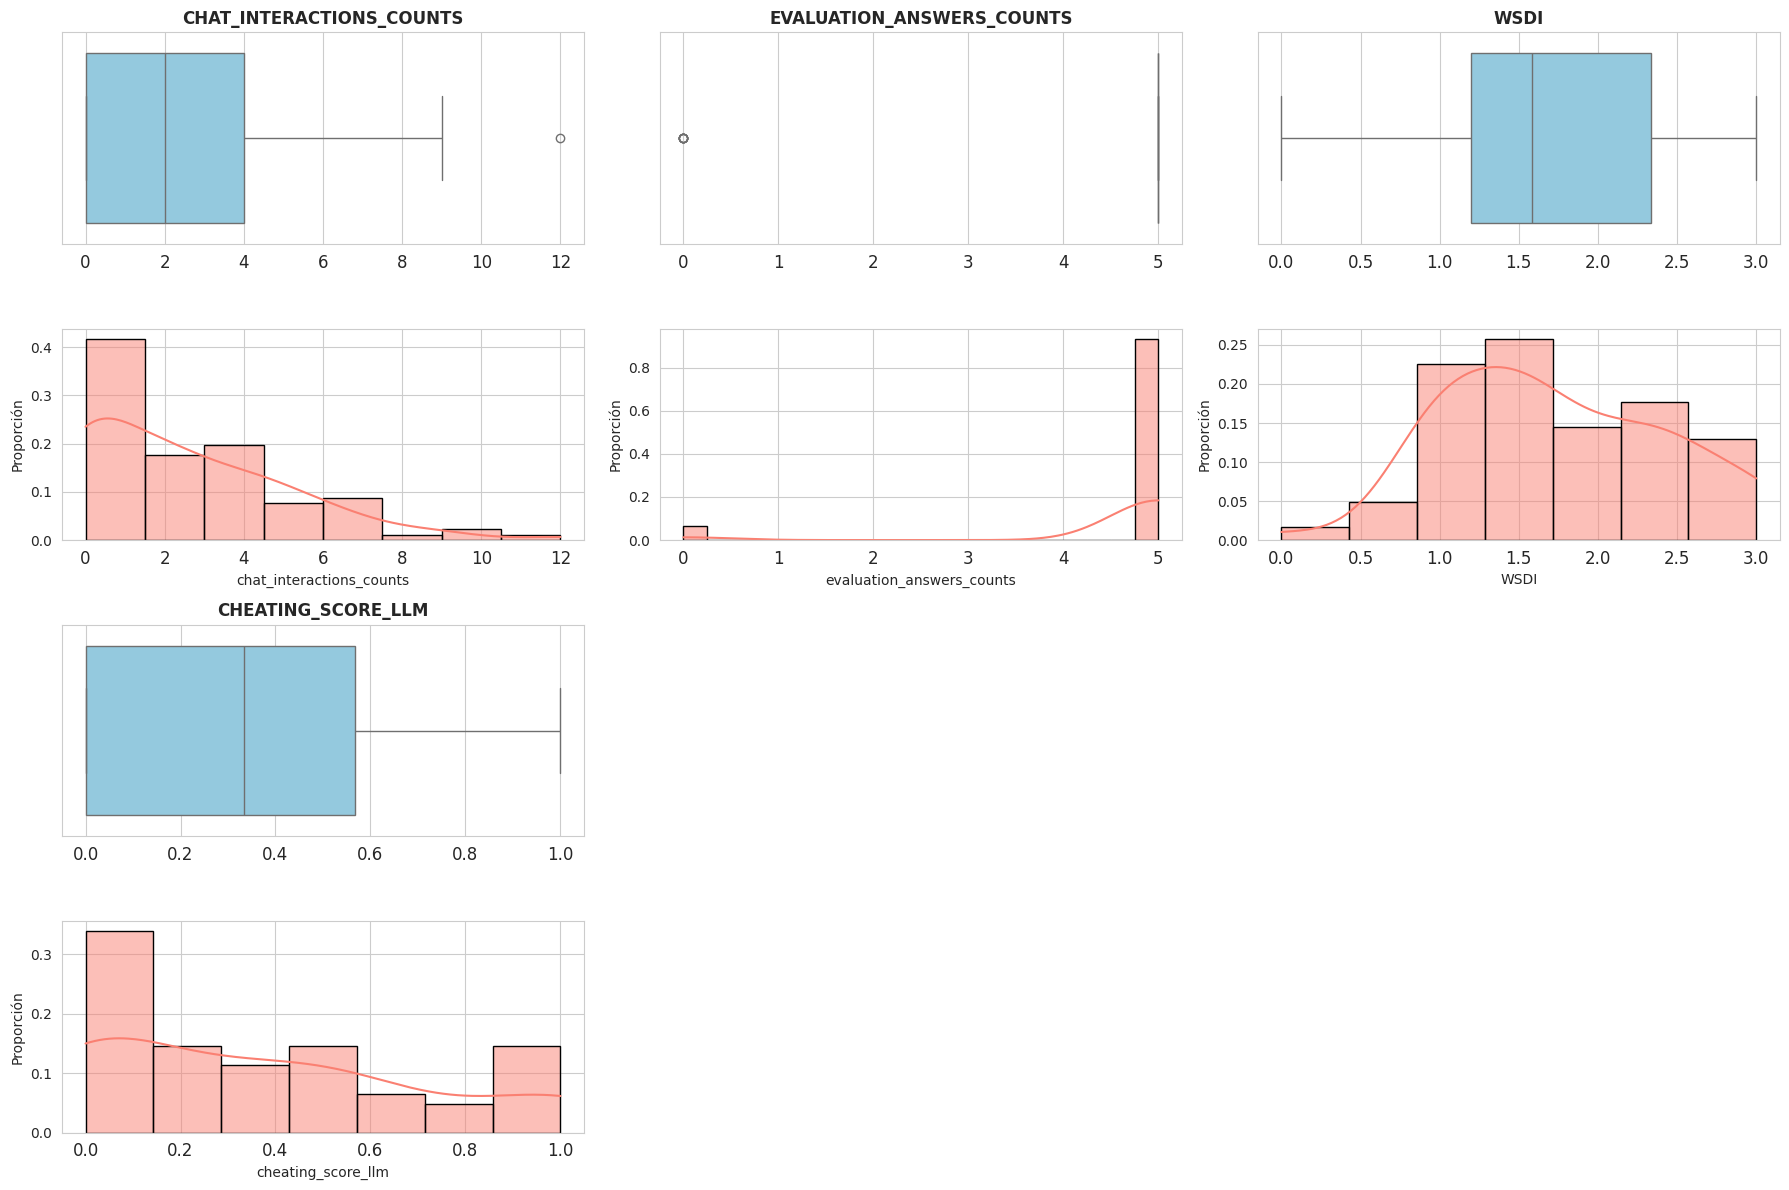

In [314]:
plot_quant_distribution(
    df = forms_interactions_df.filter(
        pl.col('grupo') == 'experimental',
        ~ pl.col('id').is_in(problematic_experimental_ids)
    ), 
    quant_cols = chats_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon")


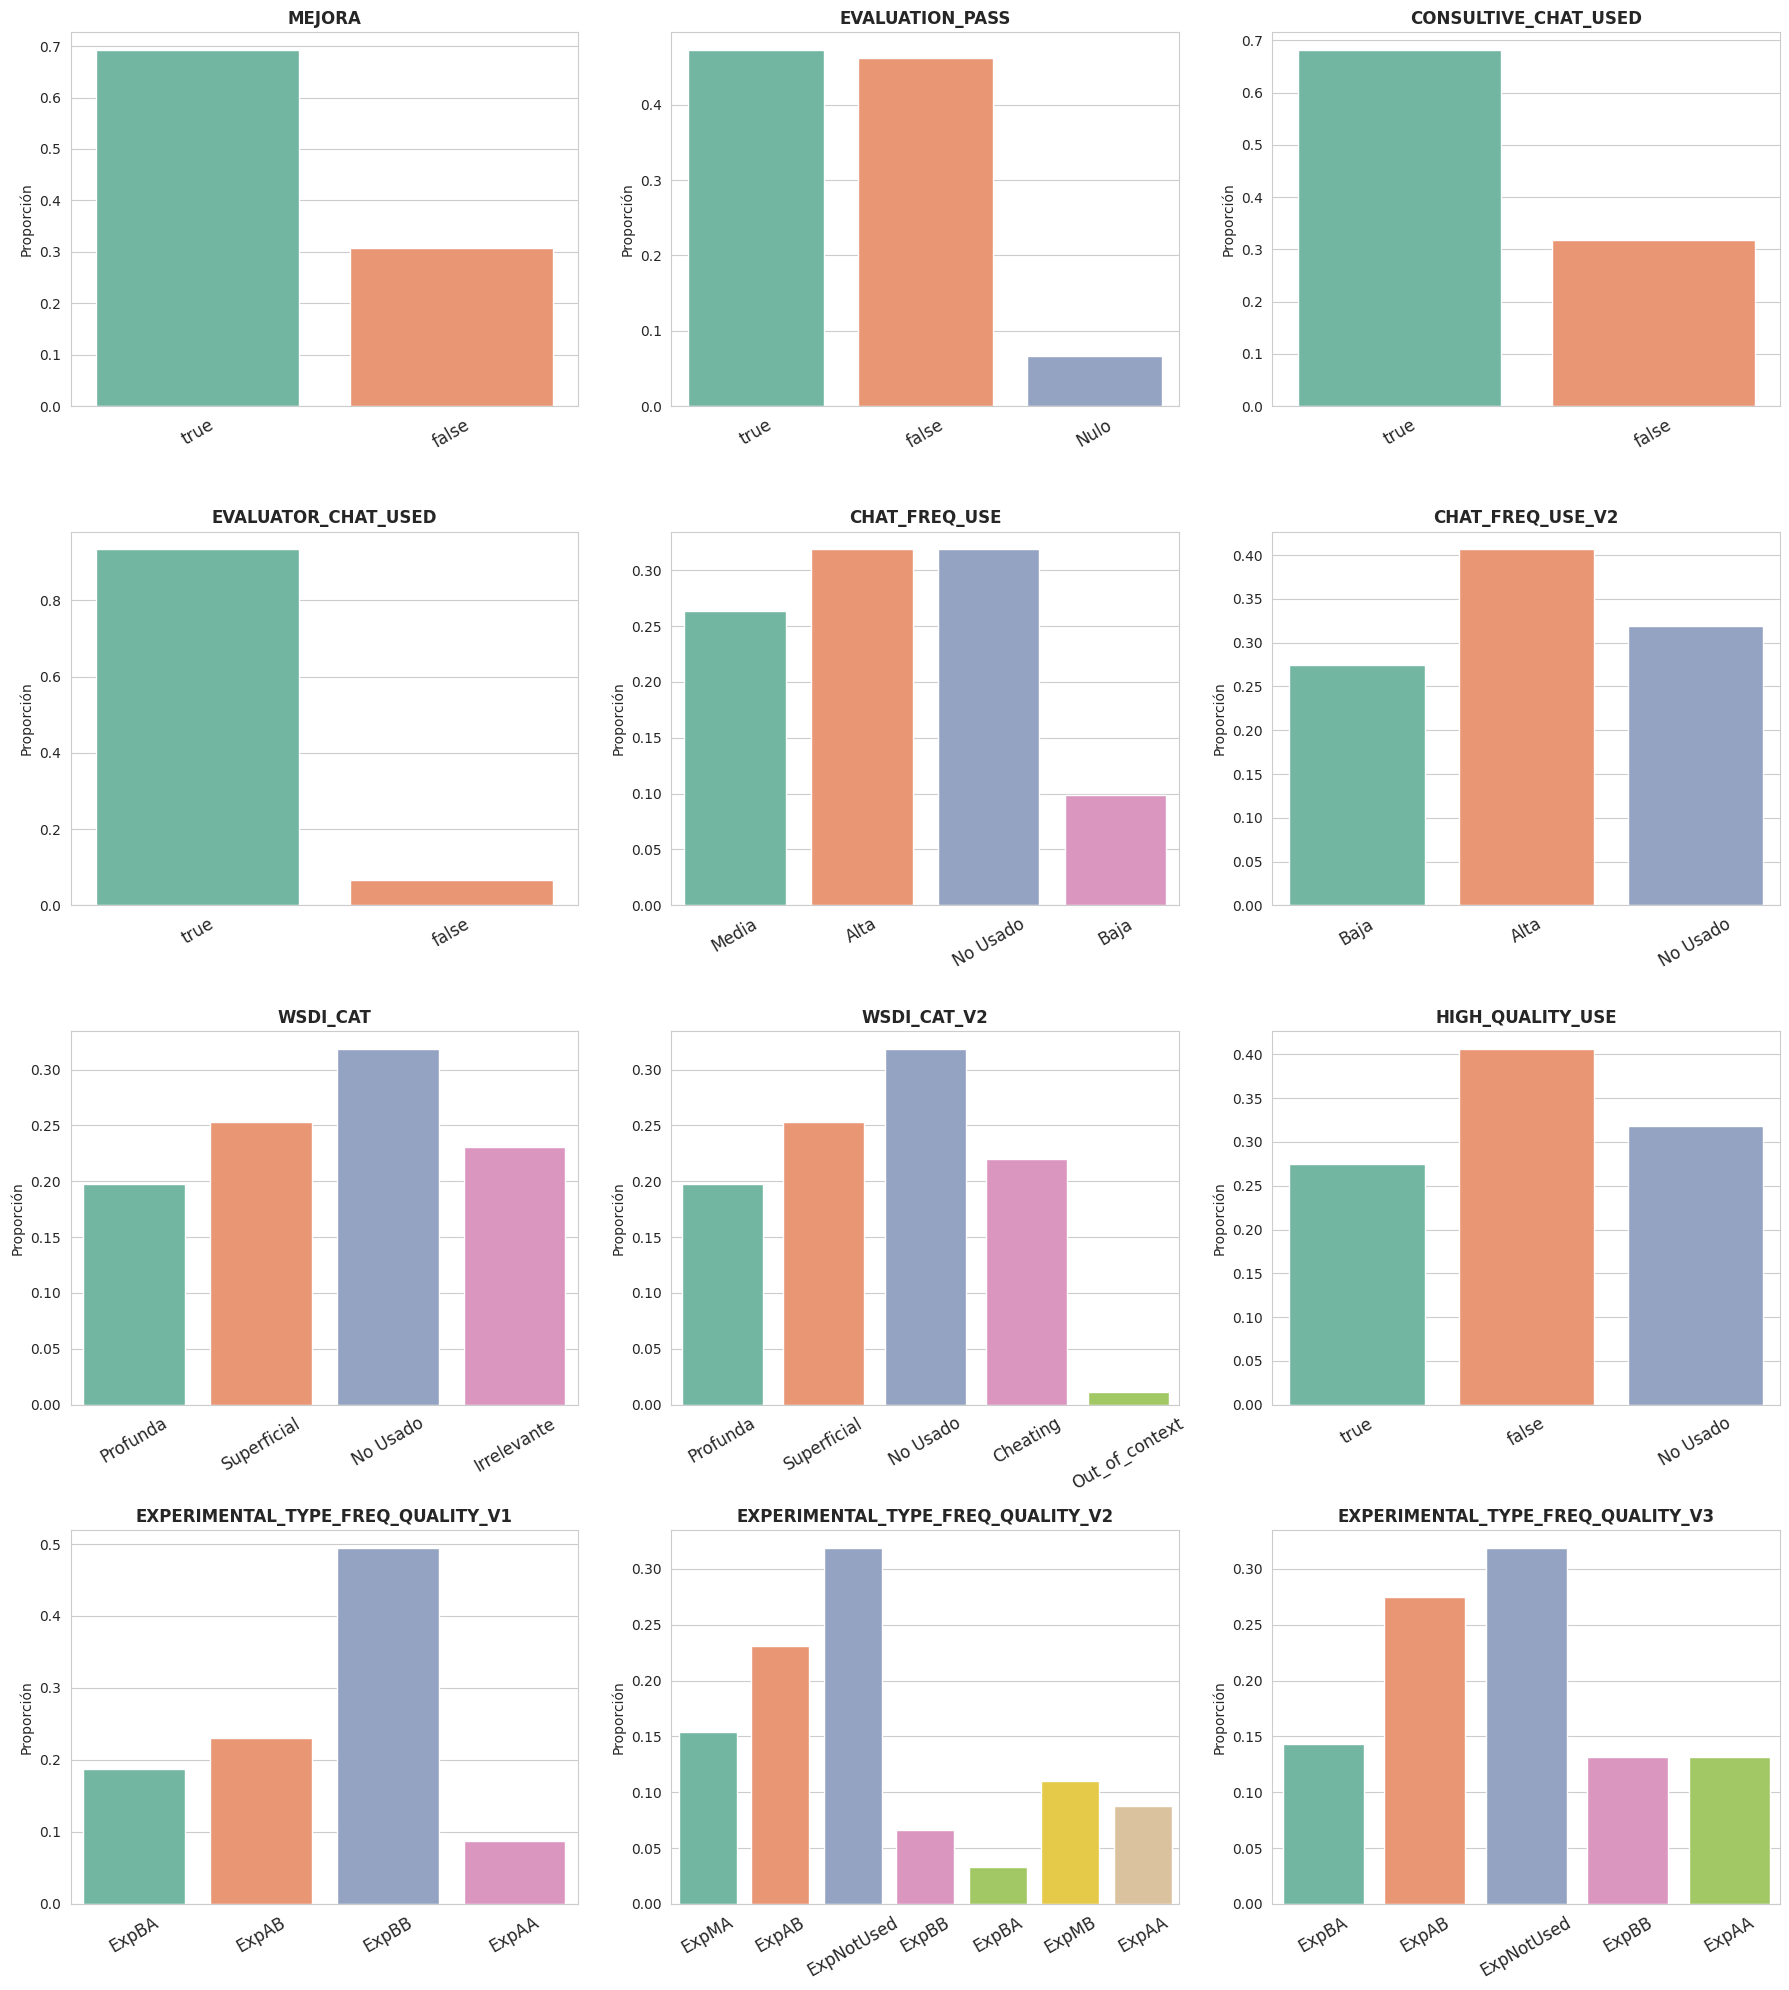

In [315]:
plot_cat_distribution(
    df = forms_interactions_df.filter(
        pl.col('grupo') == 'experimental',
        ~ pl.col('id').is_in(problematic_experimental_ids)
    ), 
    cat_cols = chats_cat_cols, 
    max_cols=3, 
    palette="Set2"
)

### Análisis Cruzado (Rendimiento Forms - Interacciones Herramienta)

#### TC-Hake por Grupos (Control vs Experimental)

In [316]:
for col in analysis_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)), 
            cols =  [col], 
            group_by = 'grupo'
        ).sort('grupo')
    )

PUNTUACION_TC_HAKE_GAIN


grupo,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.405216,0.554484,0.167,0.5,0.75,-2.0,1.0
"""experimental""",0.248714,0.675574,0.0,0.4,0.6,-3.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.301577,0.80297,0.0,0.5,1.0,-4.0,1.0
"""experimental""",0.162099,0.811226,0.0,0.0,1.0,-3.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.481639,0.481089,0.0,0.5,1.0,-1.0,1.0
"""experimental""",0.365747,0.523519,0.0,0.5,0.75,-1.0,1.0


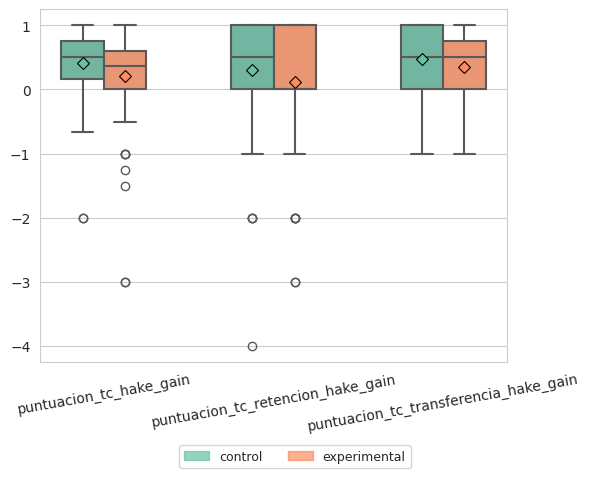

In [317]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

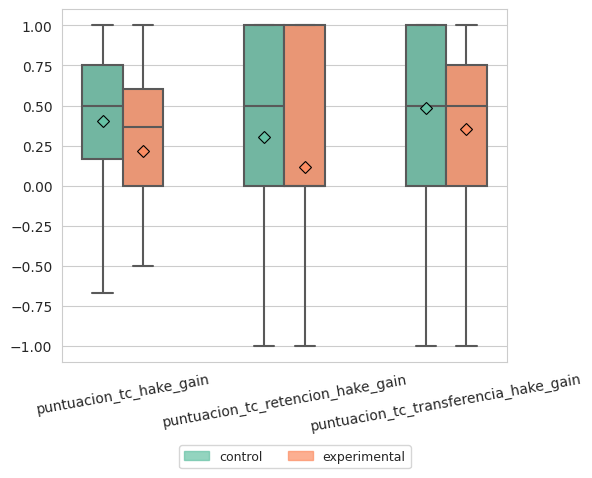

In [318]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

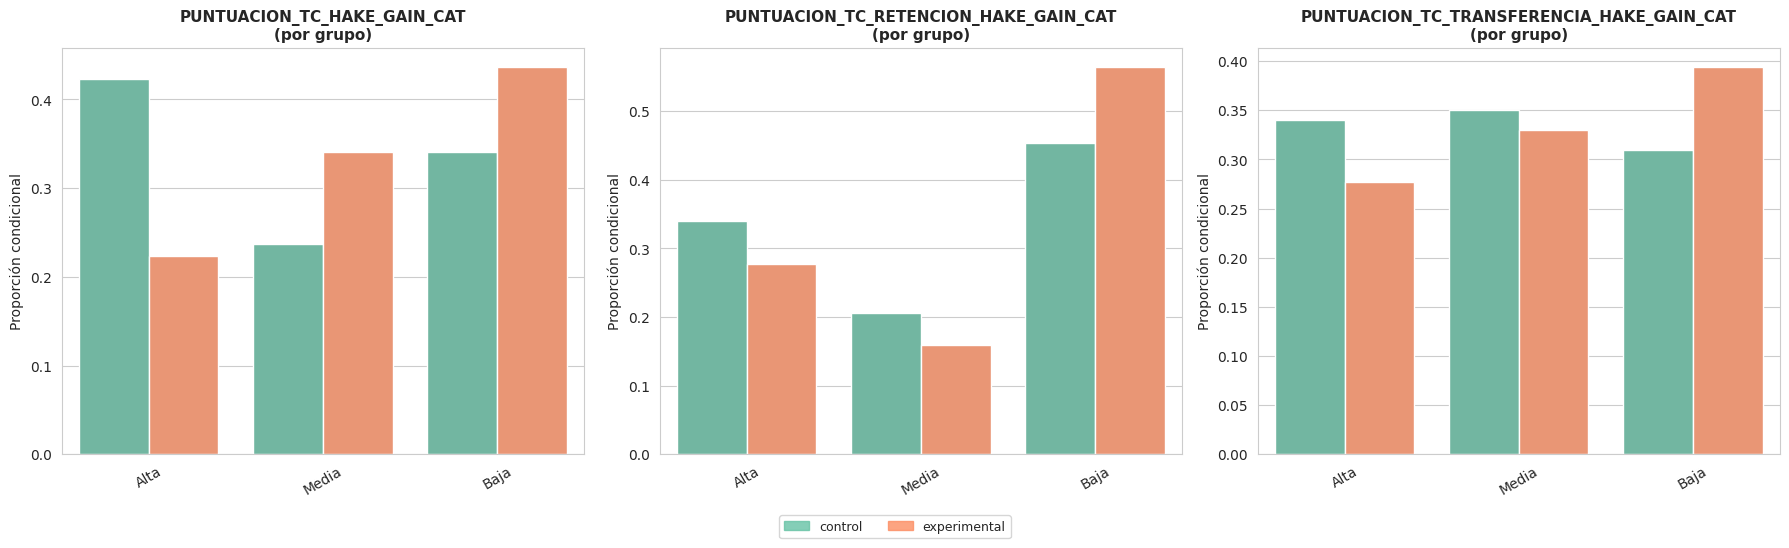

In [319]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_hake_gain_cat'],
        ['puntuacion_tc_retencion_hake_gain_cat'],
        ['puntuacion_tc_transferencia_hake_gain_cat']
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja'],
    group_by='grupo',
)


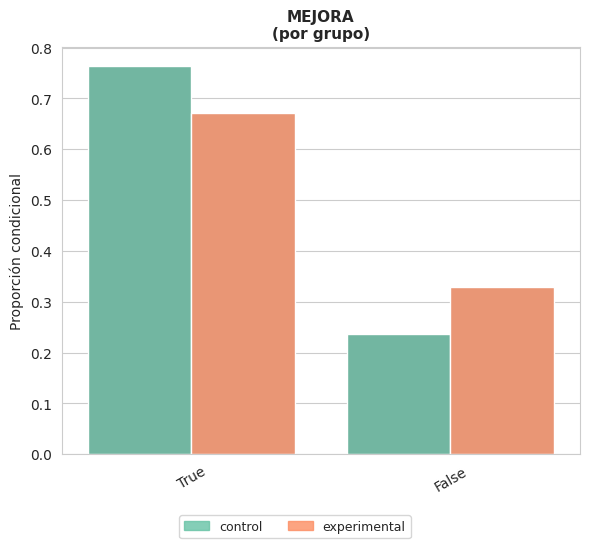

In [320]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo',
)


#### TC-Hake por Grupos Avanzado (Control vs Tipos de Experimental)

In [323]:
for col in analysis_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)), 
            cols =  [col], 
            group_by = 'grupo_segmented_v3'
        ).sort('grupo_segmented_v3')
    )

PUNTUACION_TC_HAKE_GAIN


grupo_segmented_v3,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpAA""",0.294417,0.522189,0.0,0.5,0.5,-1.0,1.0
"""ExpAB""",0.0416,1.042429,0.0,0.333,0.6,-3.0,1.0
"""ExpBA""",0.533846,0.27853,0.4,0.5,0.75,0.0,1.0
"""ExpBB""",0.394,0.332276,0.25,0.4,0.5,0.0,1.0
"""ExpNotUsed""",0.220414,0.514796,0.0,0.25,0.5,-1.5,1.0
"""control""",0.405216,0.554484,0.167,0.5,0.75,-2.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo_segmented_v3,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpAA""",0.388917,0.488952,0.0,0.0,1.0,0.0,1.0
"""ExpAB""",-0.08668,0.993165,0.0,0.0,0.5,-3.0,1.0
"""ExpBA""",0.365385,0.781394,0.0,0.75,1.0,-1.0,1.0
"""ExpBB""",0.305583,0.589631,0.0,0.5,0.667,-1.0,1.0
"""ExpNotUsed""",0.132207,0.819383,0.0,0.0,0.667,-2.0,1.0
"""control""",0.301577,0.80297,0.0,0.5,1.0,-4.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo_segmented_v3,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpAA""",0.291667,0.334279,0.0,0.5,0.5,0.0,1.0
"""ExpAB""",0.33796,0.67517,0.0,0.5,1.0,-1.0,1.0
"""ExpBA""",0.583385,0.390904,0.333,0.667,1.0,0.0,1.0
"""ExpBB""",0.486083,0.321519,0.333,0.5,0.667,0.0,1.0
"""ExpNotUsed""",0.273,0.547782,0.0,0.25,0.75,-1.0,1.0
"""control""",0.481639,0.481089,0.0,0.5,1.0,-1.0,1.0


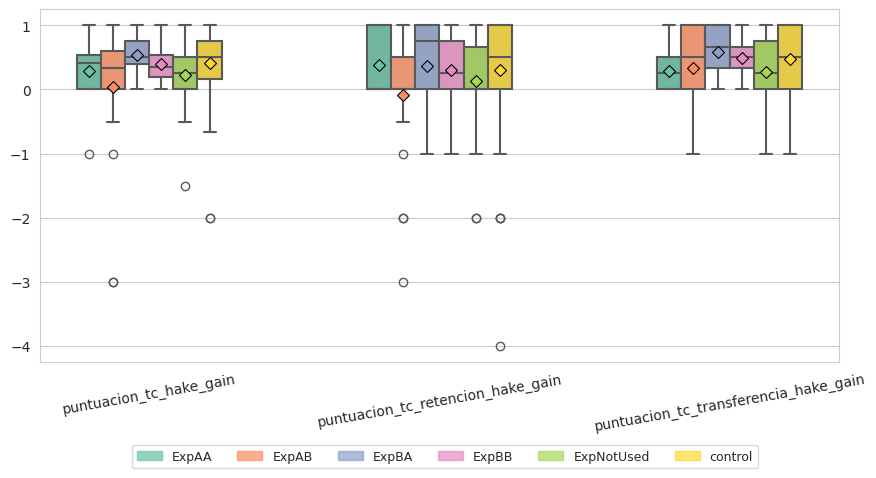

In [324]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)),
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

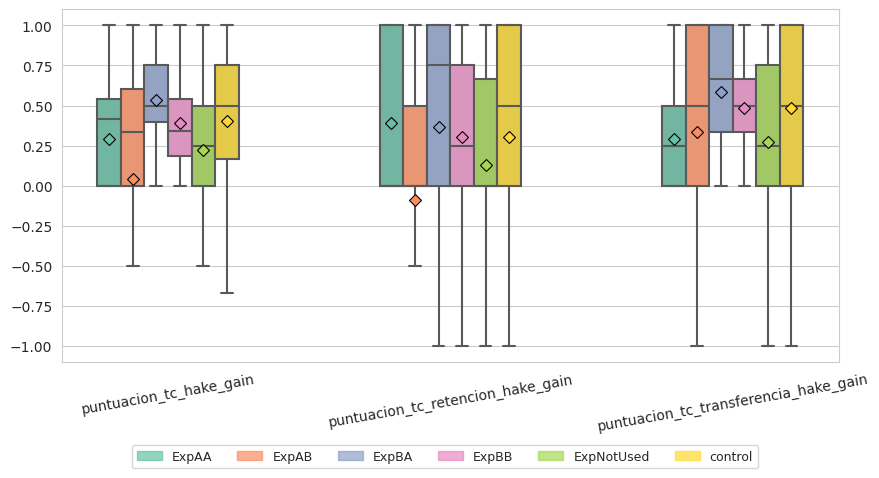

In [325]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)),
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

---
---
---

In [326]:
forms_cat_cols

['puntuacion_tc_hake_gain_cat',
 'puntuacion_tc_retencion_hake_gain_cat',
 'puntuacion_tc_transferencia_hake_gain_cat',
 'puntuacion_tc_cat_trad_scale_pre',
 'puntuacion_tc_cat_trad_scale_post',
 'puntuacion_tc_cat_pre',
 'puntuacion_ta_cat_pre',
 'puntuacion_tc_retencion_cat_pre',
 'puntuacion_tc_transferencia_cat_pre',
 'puntuacion_tc_cat_post',
 'puntuacion_ta_cat_post',
 'puntuacion_tc_retencion_cat_post',
 'puntuacion_tc_transferencia_cat_post',
 'puntuacion_tcc_rel_cat_post',
 'puntuacion_tcc_int_cat_post',
 'puntuacion_tcc_ext_cat_post']

CENTRO

── CONDICIÓN: JesusMaria ──

n = 49


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",4,0.08
"""ExpAA""",5,0.1
"""ExpNotUsed""",2,0.04
"""ExpBB""",4,0.08
"""control""",27,0.55
"""ExpAB""",7,0.14


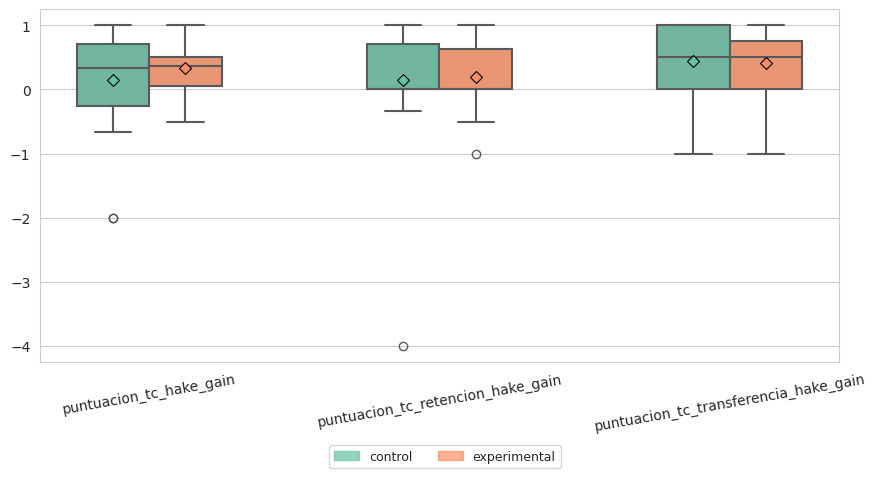

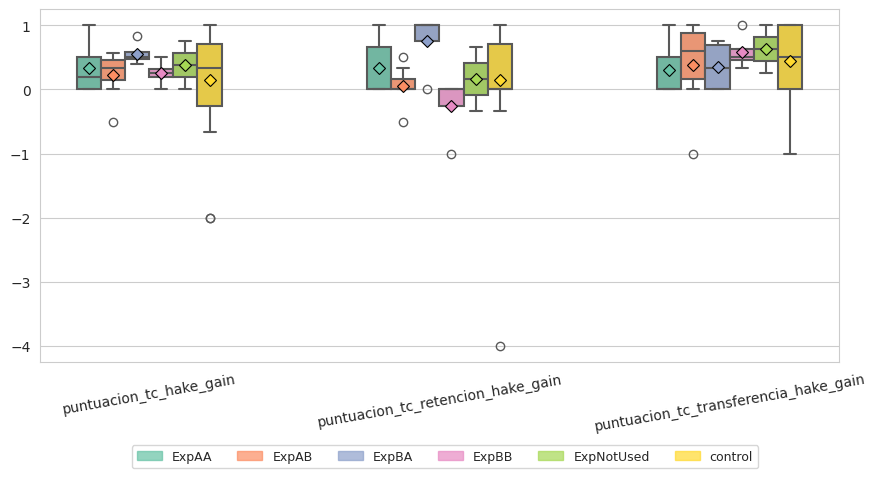

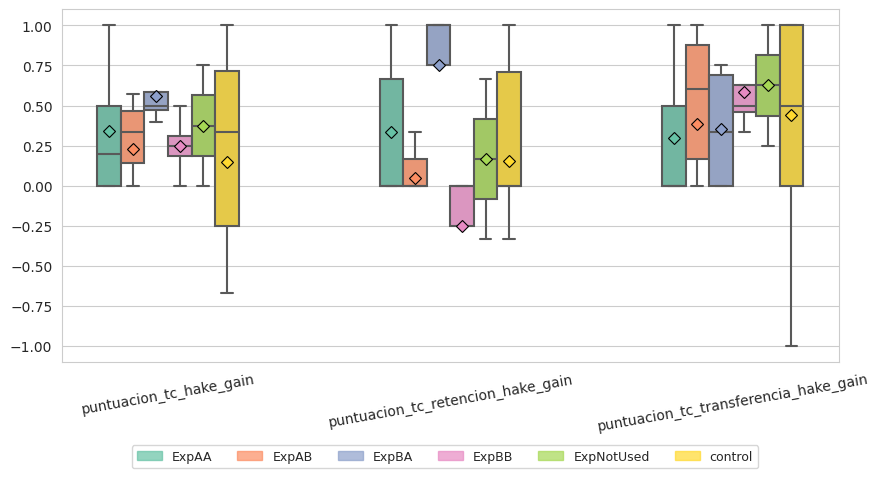


── CONDICIÓN: RamiroMaeztu ──

n = 63


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAA""",1,0.02
"""ExpNotUsed""",19,0.3
"""ExpAB""",6,0.1
"""ExpBB""",3,0.05
"""control""",31,0.49
"""ExpBA""",3,0.05


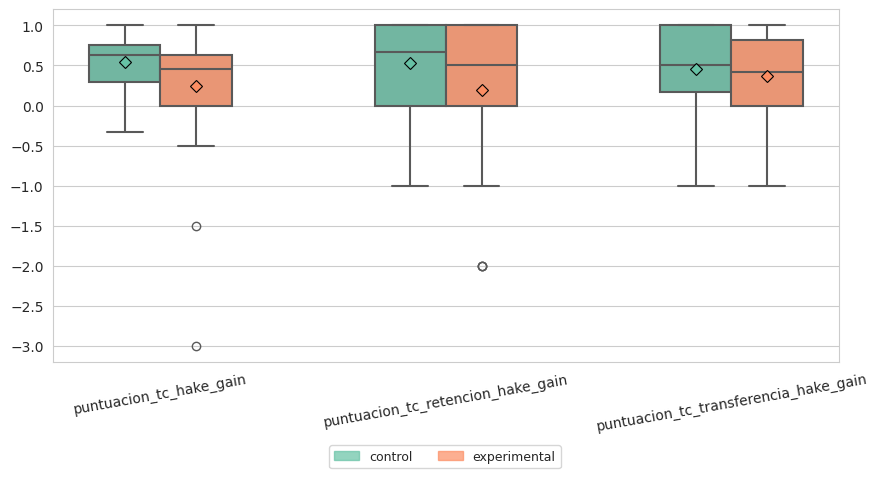

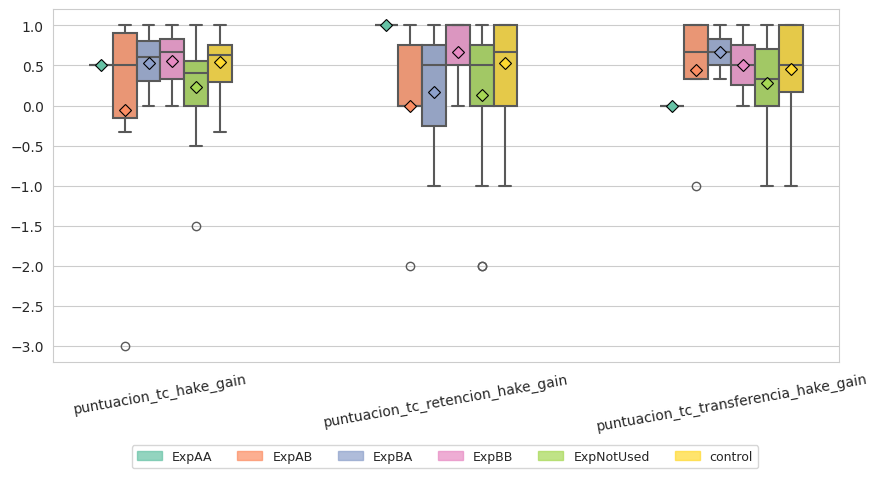

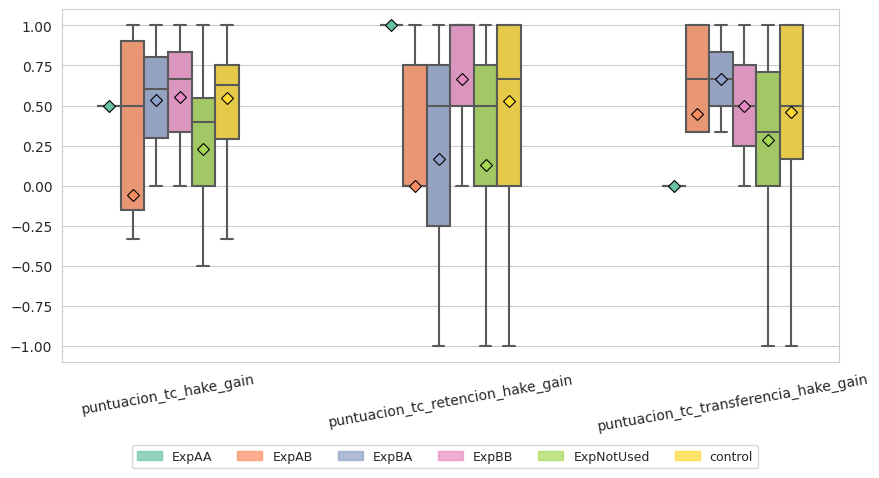


── CONDICIÓN: JoseGarciaNieto ──

n = 28


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",5,0.18
"""ExpBB""",1,0.04
"""control""",14,0.5
"""ExpAA""",4,0.14
"""ExpBA""",4,0.14


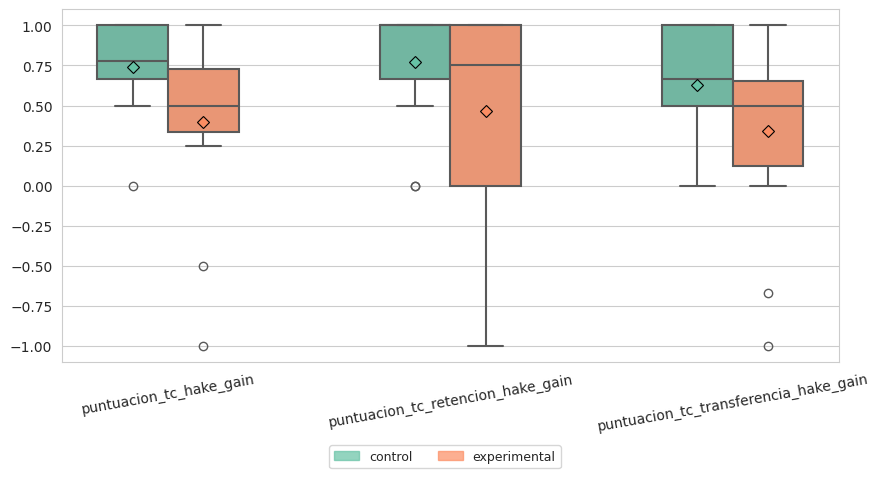

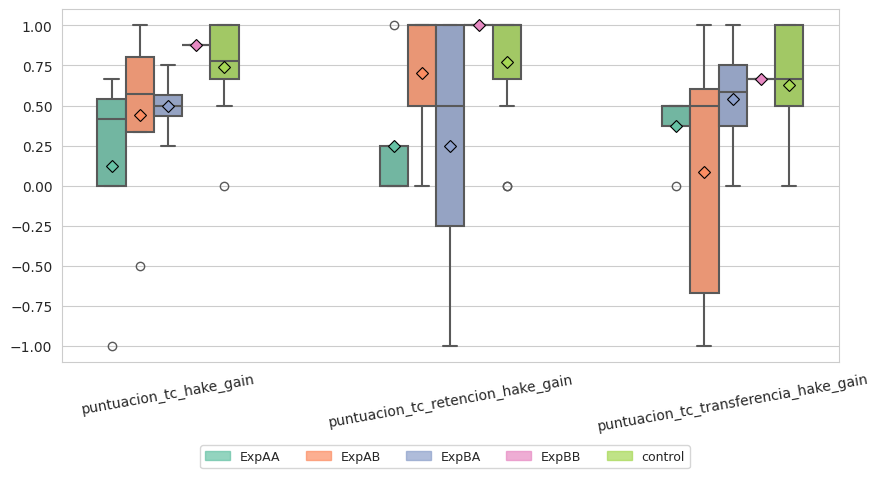

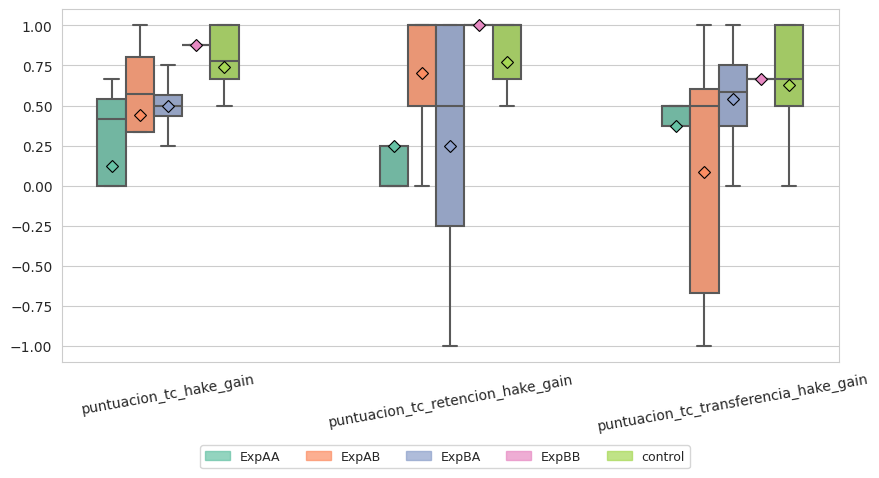


── CONDICIÓN: Laguna ──

n = 48


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBB""",4,0.08
"""ExpAA""",2,0.04
"""ExpBA""",2,0.04
"""ExpAB""",7,0.15
"""ExpNotUsed""",8,0.17
"""control""",25,0.52


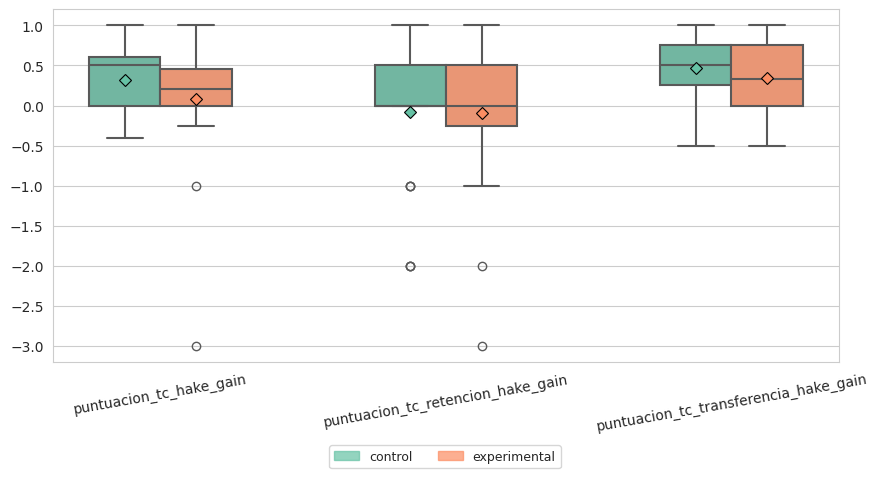

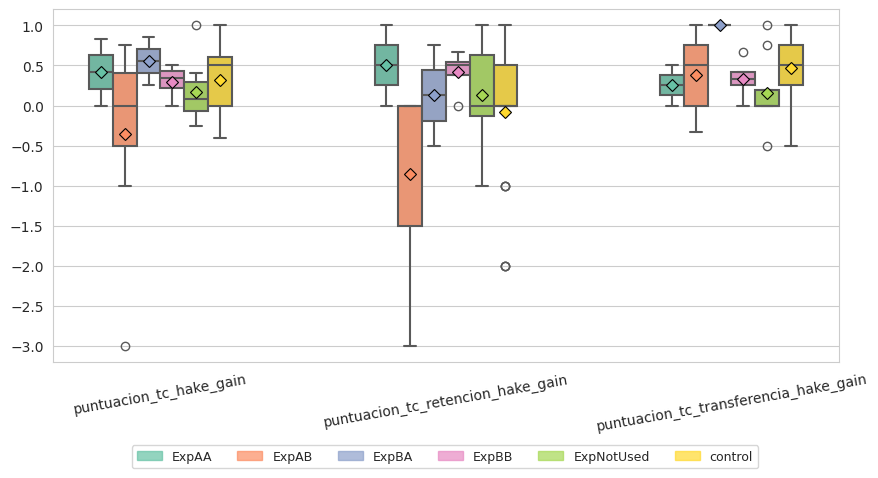

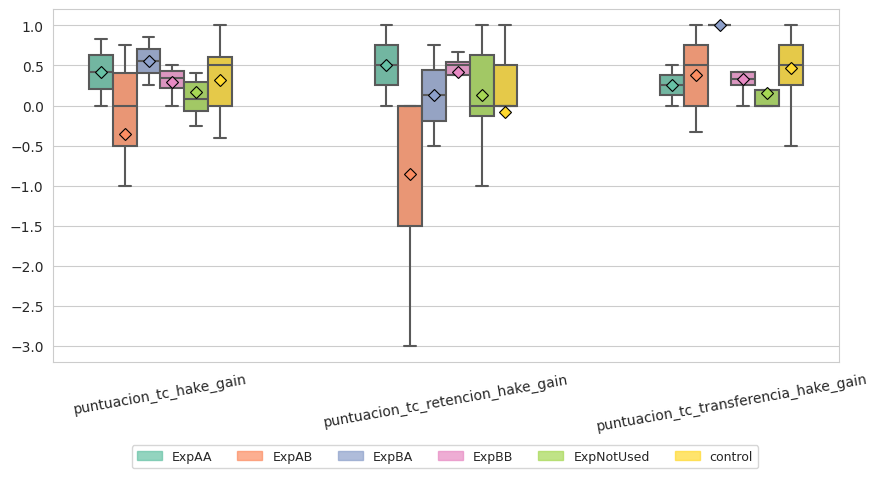

PUNTUACION_TC_HAKE_GAIN_CAT

── CONDICIÓN: Alta ──

n = 62


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",4,0.06
"""ExpAB""",5,0.08
"""ExpNotUsed""",6,0.1
"""ExpBB""",3,0.05
"""ExpAA""",3,0.05
"""control""",41,0.66


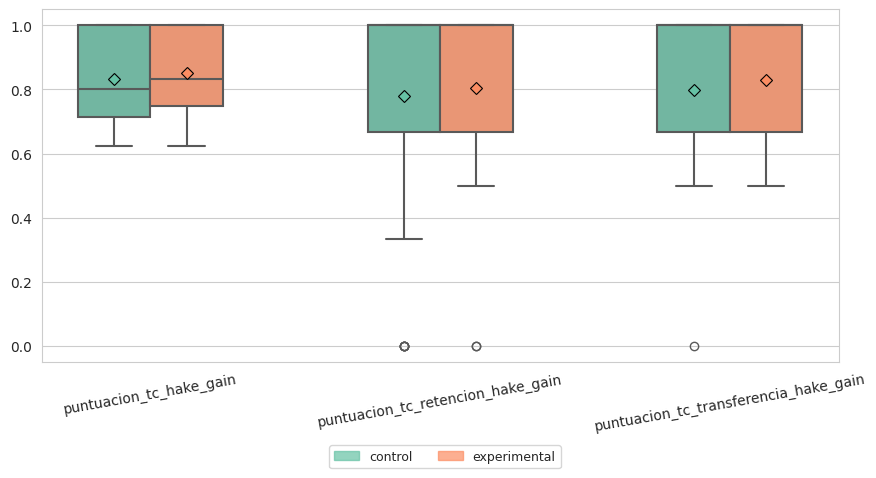

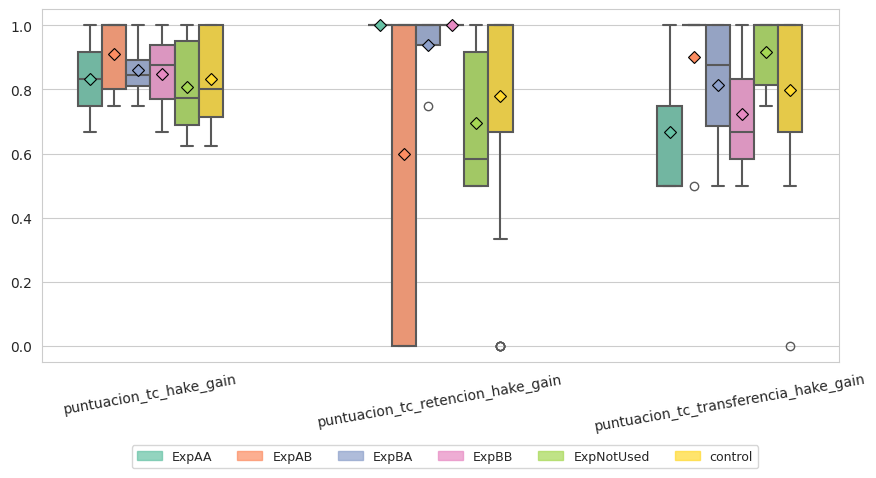

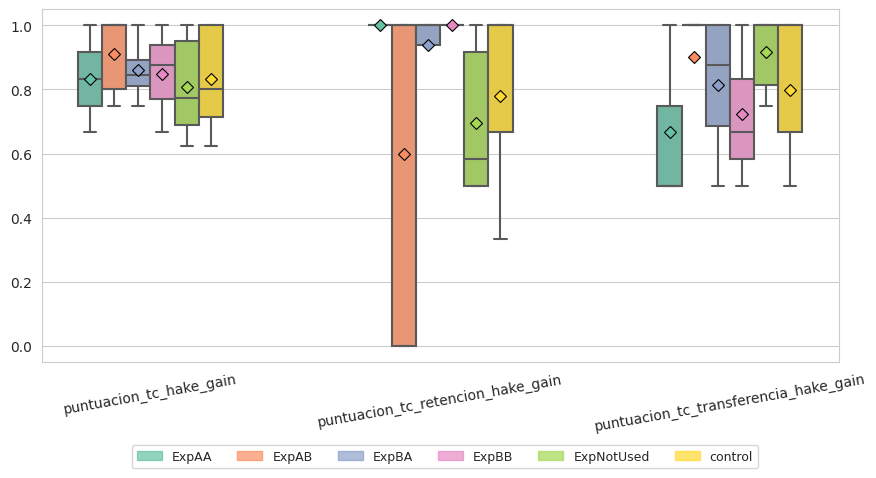


── CONDICIÓN: Baja ──

n = 71


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAA""",5,0.07
"""ExpAB""",10,0.14
"""control""",33,0.46
"""ExpBA""",3,0.04
"""ExpBB""",5,0.07
"""ExpNotUsed""",15,0.21


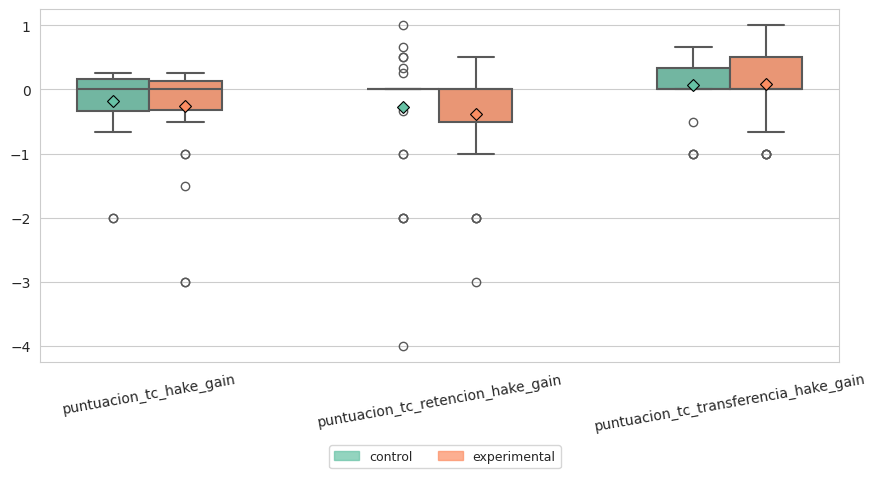

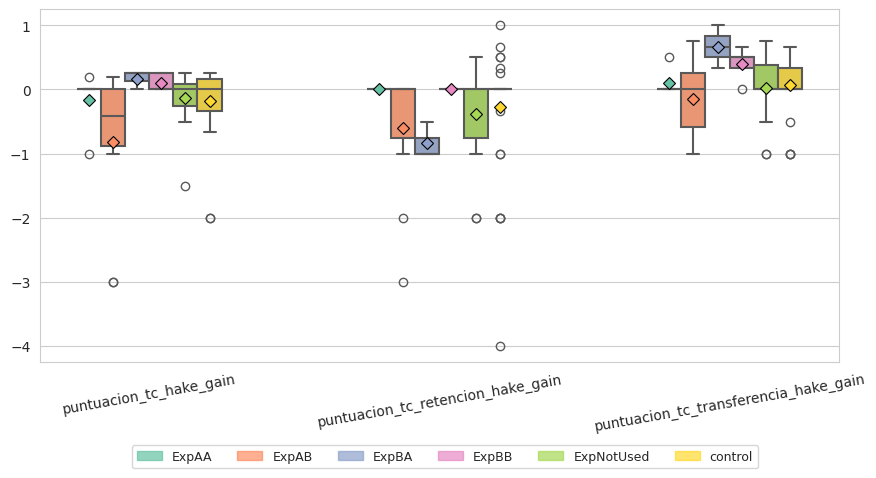

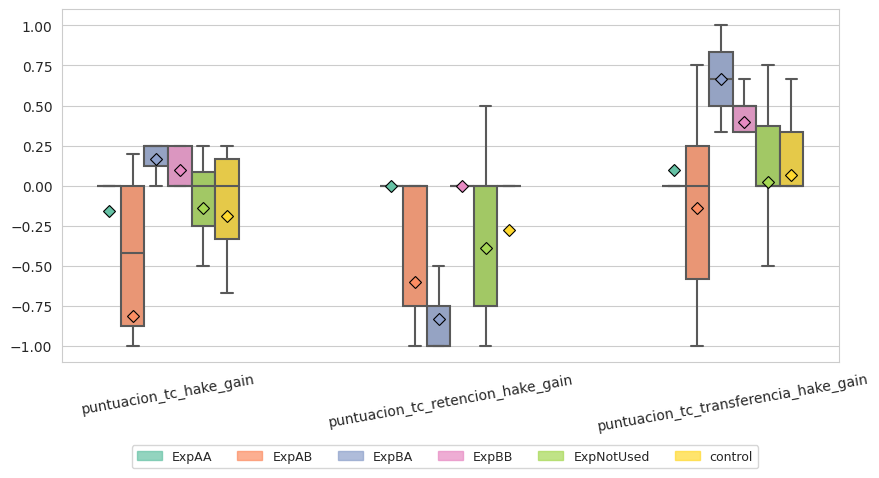


── CONDICIÓN: Media ──

n = 55


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",10,0.18
"""ExpBA""",6,0.11
"""control""",23,0.42
"""ExpBB""",4,0.07
"""ExpAA""",4,0.07
"""ExpNotUsed""",8,0.15


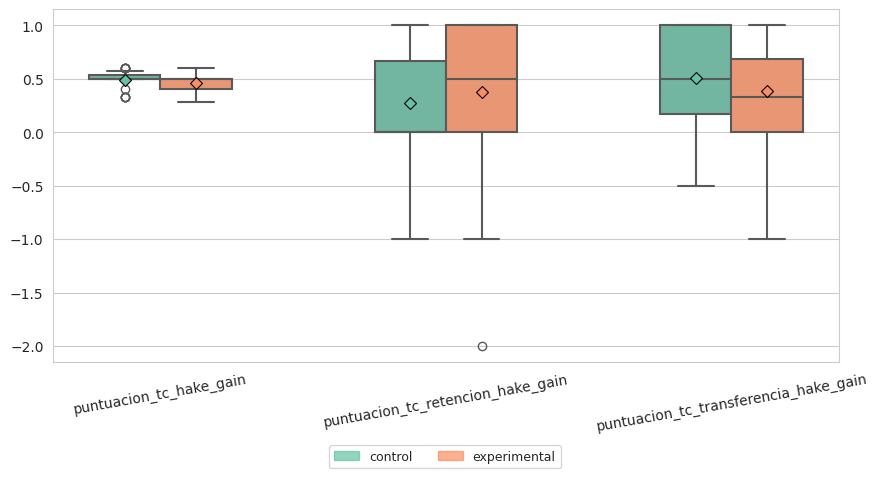

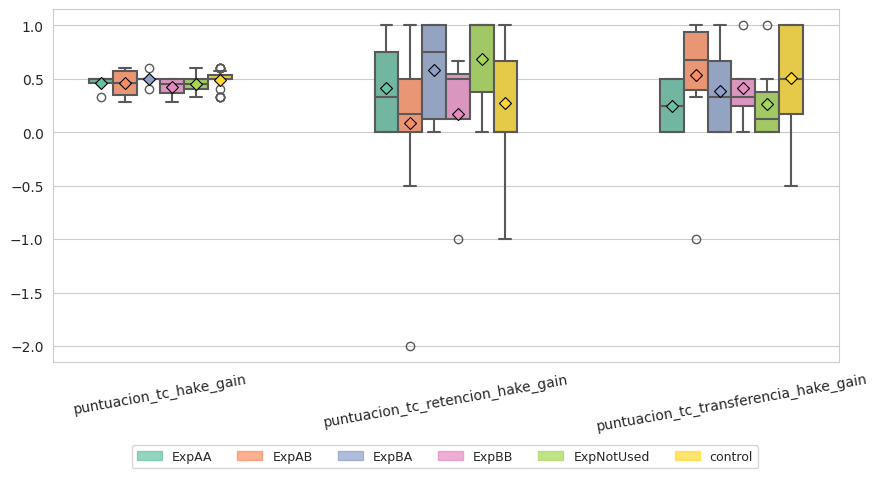

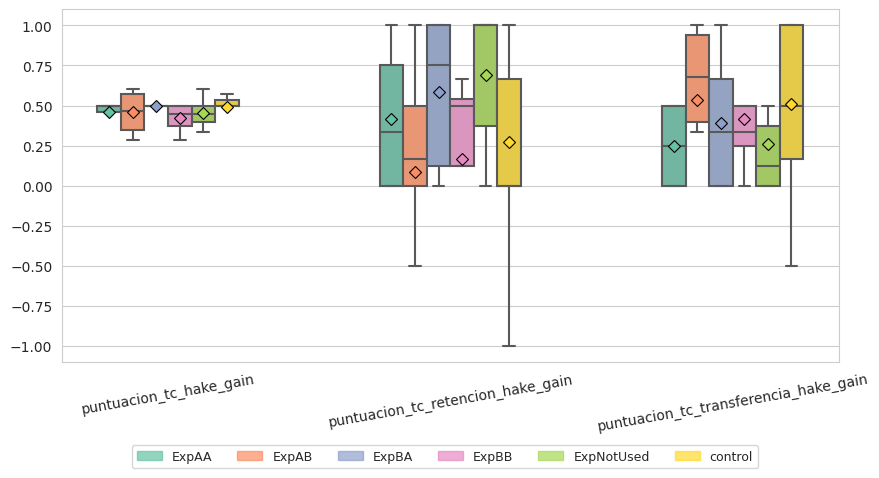

PUNTUACION_TCC_INT_CAT_POST

── CONDICIÓN: Baja ──

n = 62


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",4,0.06
"""ExpBB""",2,0.03
"""control""",37,0.6
"""ExpAA""",3,0.05
"""ExpNotUsed""",9,0.15
"""ExpAB""",7,0.11


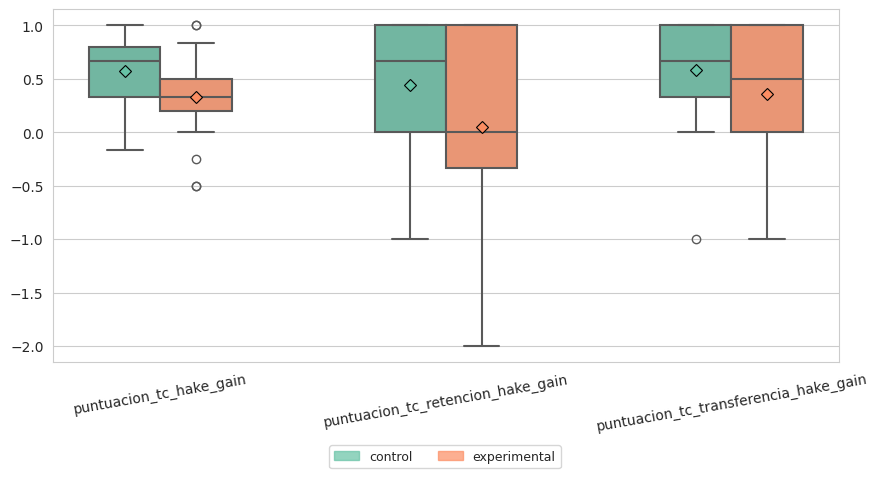

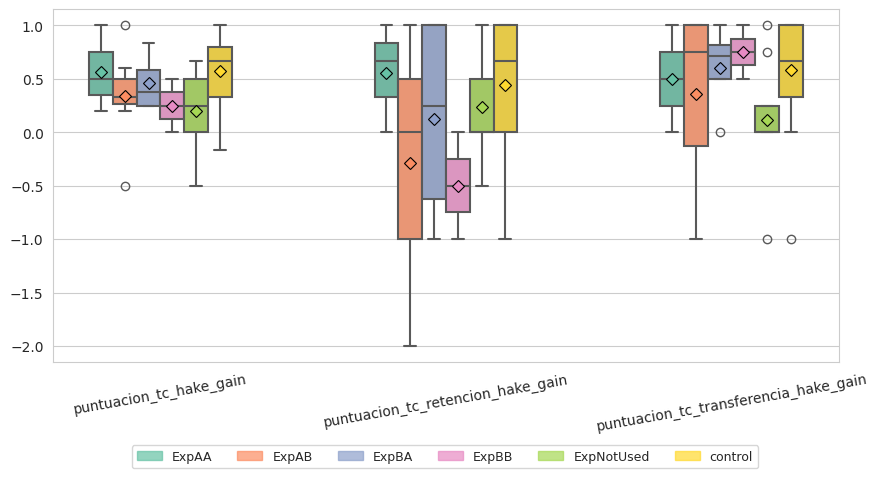

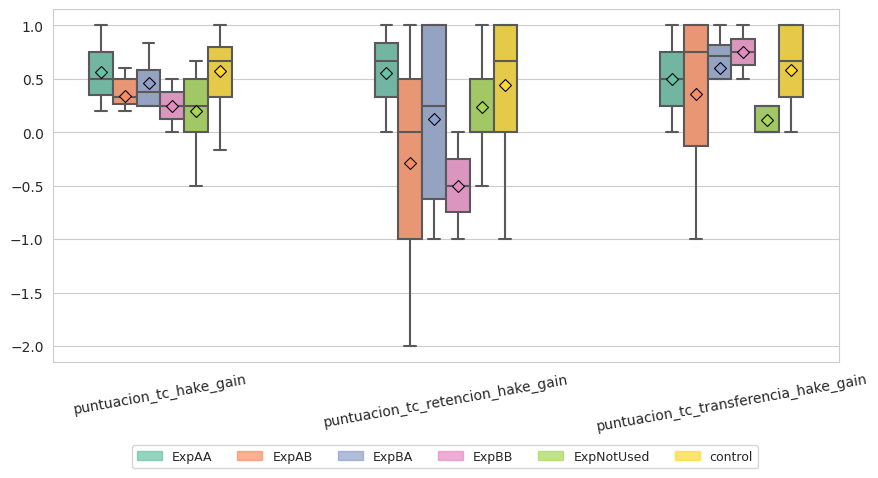


── CONDICIÓN: Alta ──

n = 59


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBB""",6,0.1
"""ExpBA""",3,0.05
"""ExpNotUsed""",12,0.2
"""control""",24,0.41
"""ExpAA""",3,0.05
"""ExpAB""",11,0.19


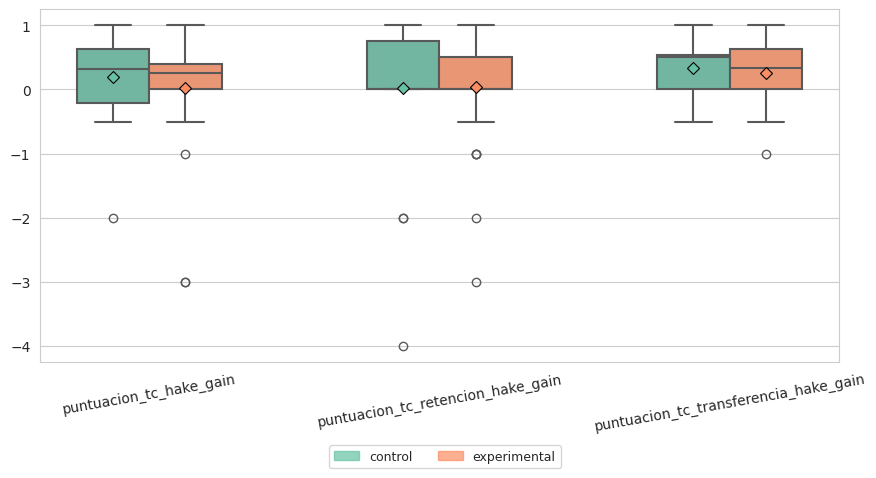

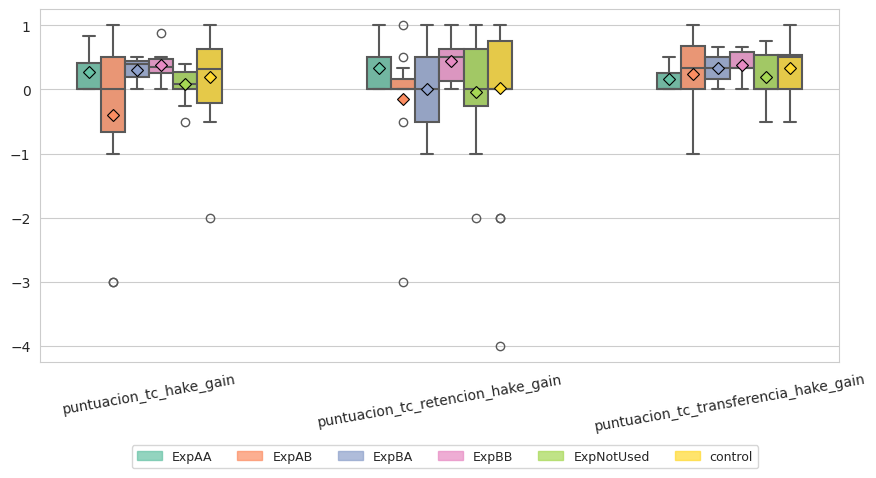

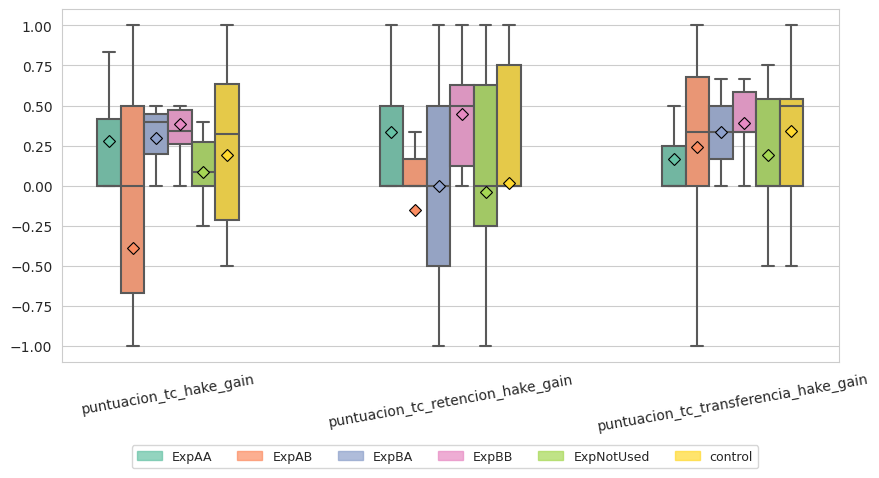


── CONDICIÓN: Media ──

n = 67


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBB""",4,0.06
"""ExpNotUsed""",8,0.12
"""control""",36,0.54
"""ExpBA""",6,0.09
"""ExpAB""",7,0.1
"""ExpAA""",6,0.09


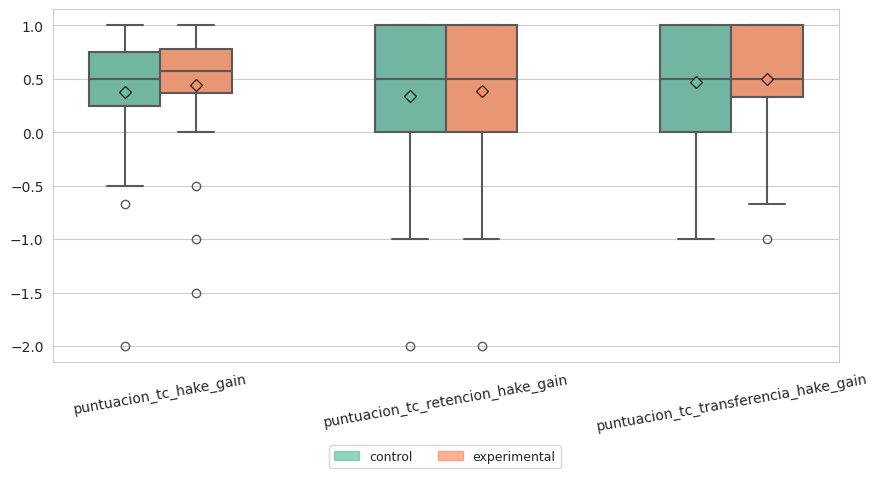

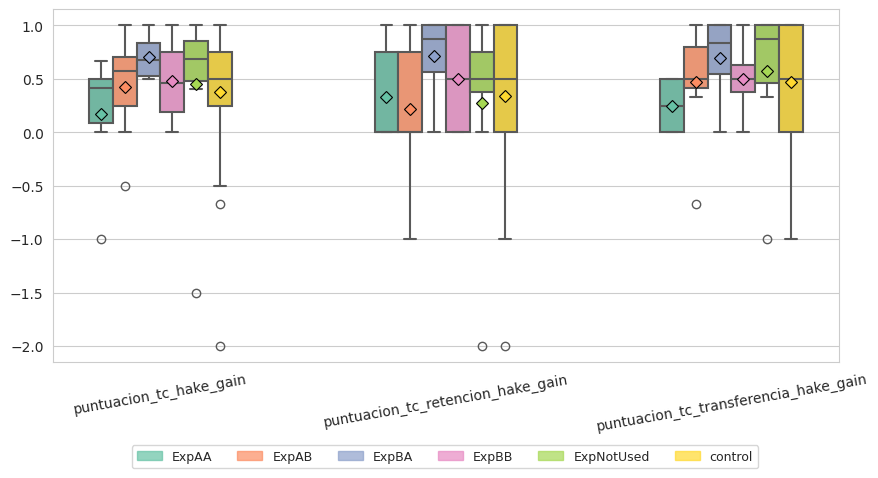

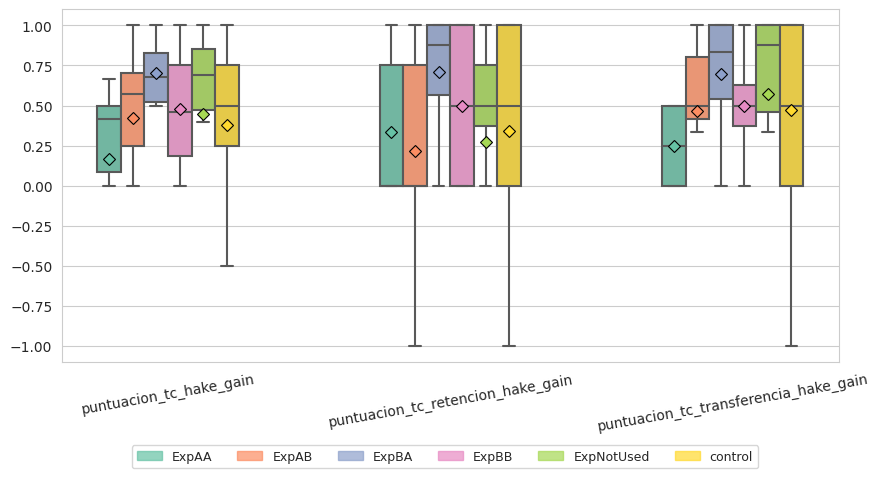

PUNTUACION_TCC_EXT_CAT_POST

── CONDICIÓN: Baja ──

n = 69


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",5,0.07
"""ExpNotUsed""",8,0.12
"""control""",45,0.65
"""ExpAB""",5,0.07
"""ExpBB""",2,0.03
"""ExpAA""",4,0.06


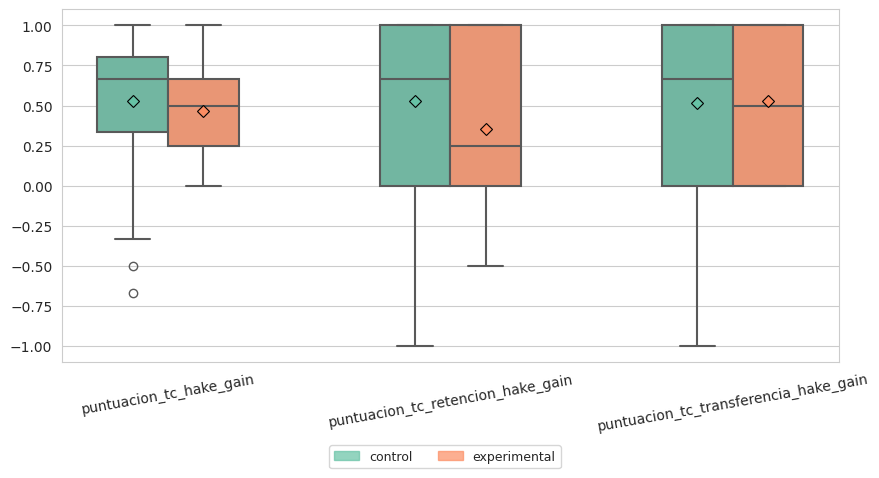

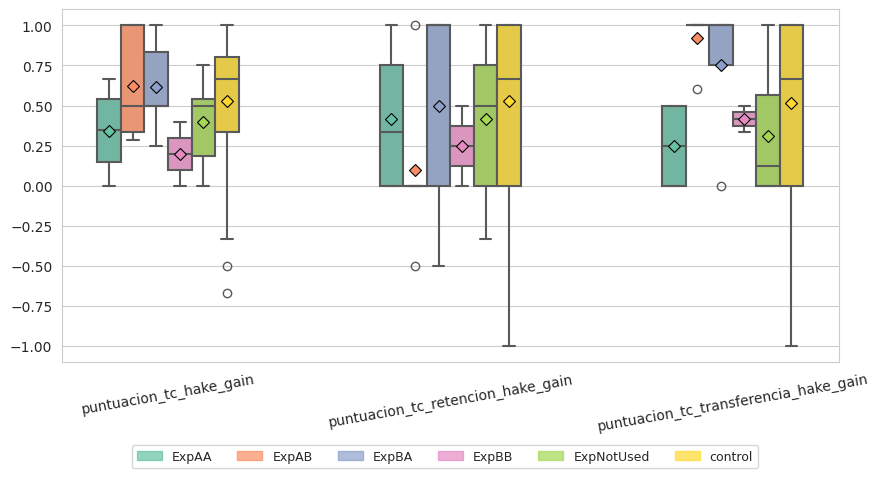

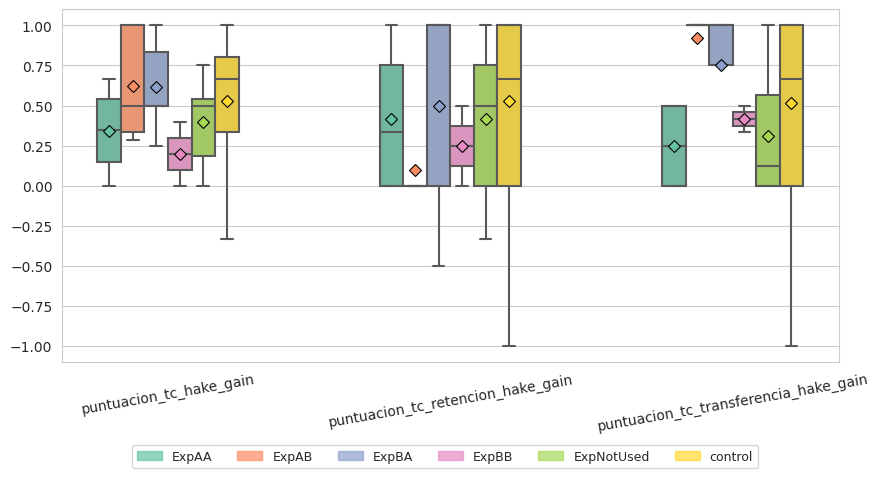


── CONDICIÓN: Media ──

n = 68


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",4,0.06
"""control""",35,0.51
"""ExpAA""",3,0.04
"""ExpBB""",5,0.07
"""ExpNotUsed""",10,0.15
"""ExpAB""",11,0.16


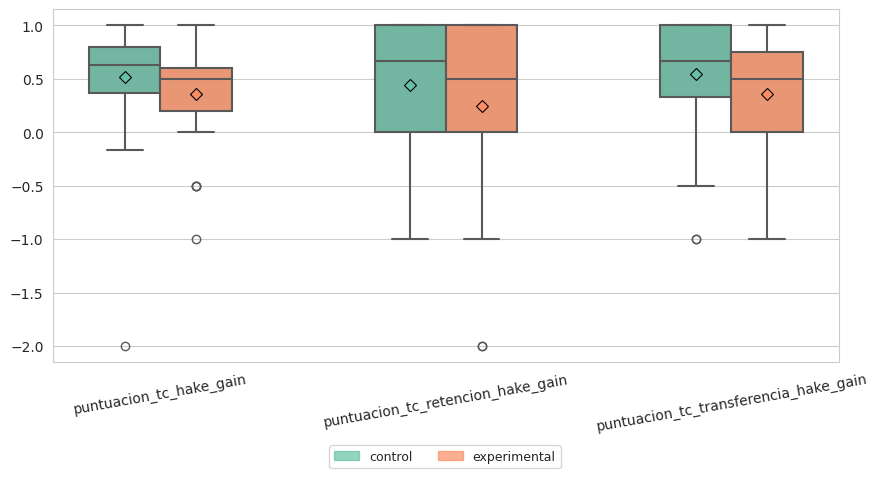

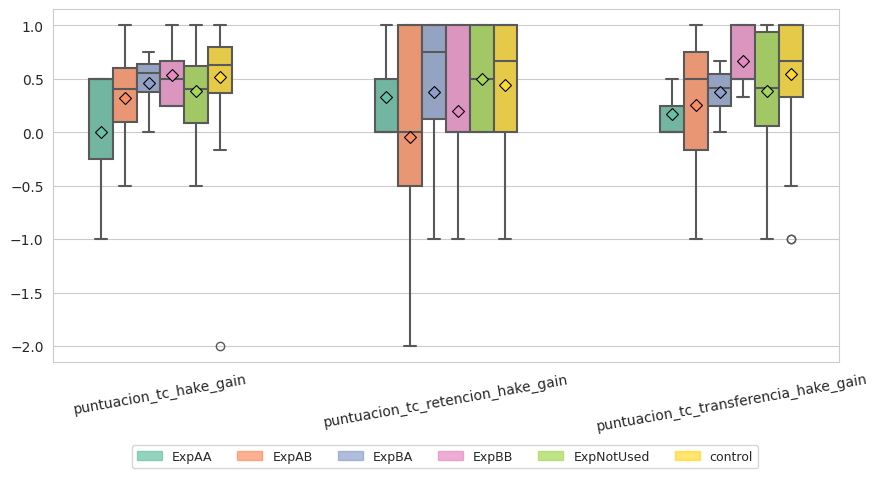

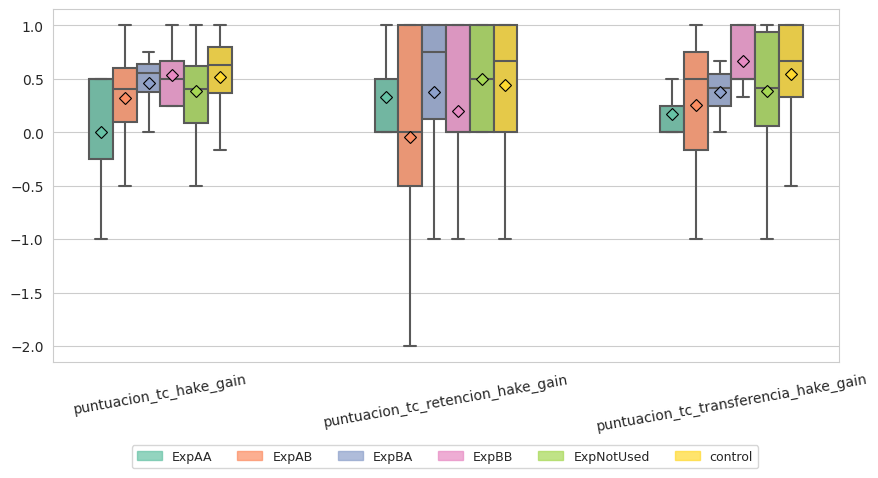


── CONDICIÓN: Alta ──

n = 51


grupo_segmented_v3,count,prop
str,u32,f64
"""control""",17,0.33
"""ExpAA""",5,0.1
"""ExpNotUsed""",11,0.22
"""ExpBB""",5,0.1
"""ExpAB""",9,0.18
"""ExpBA""",4,0.08


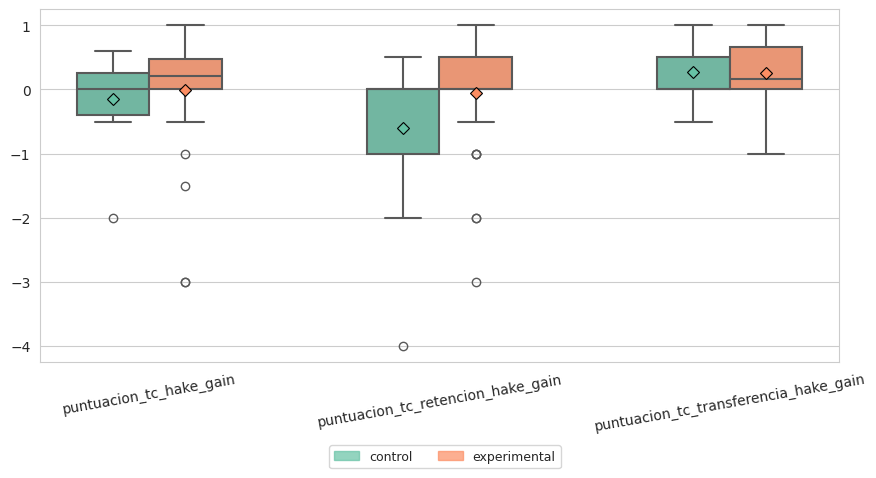

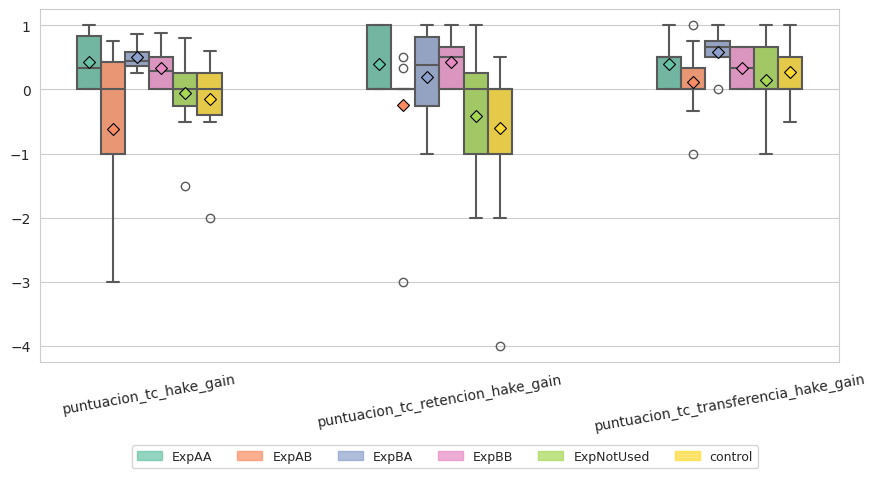

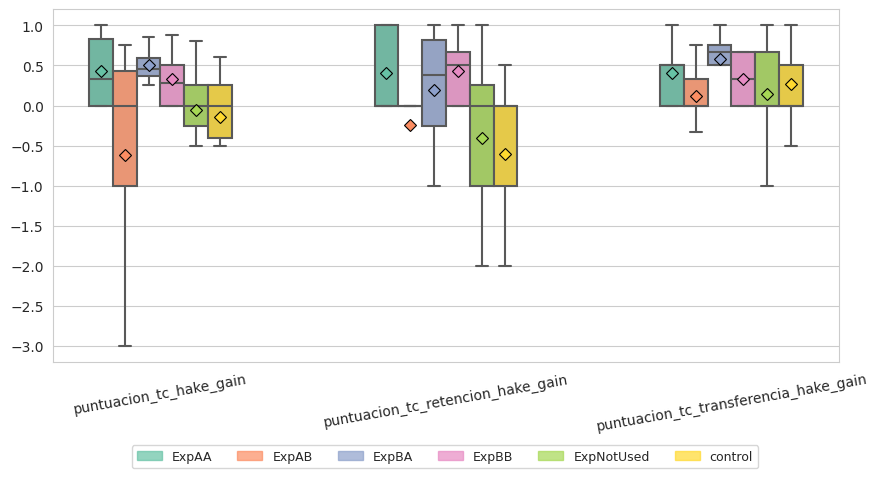

PUNTUACION_TCC_REL_CAT_POST

── CONDICIÓN: Media ──

n = 64


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpNotUsed""",11,0.17
"""ExpAB""",7,0.11
"""ExpAA""",3,0.05
"""ExpBB""",4,0.06
"""ExpBA""",4,0.06
"""control""",35,0.55


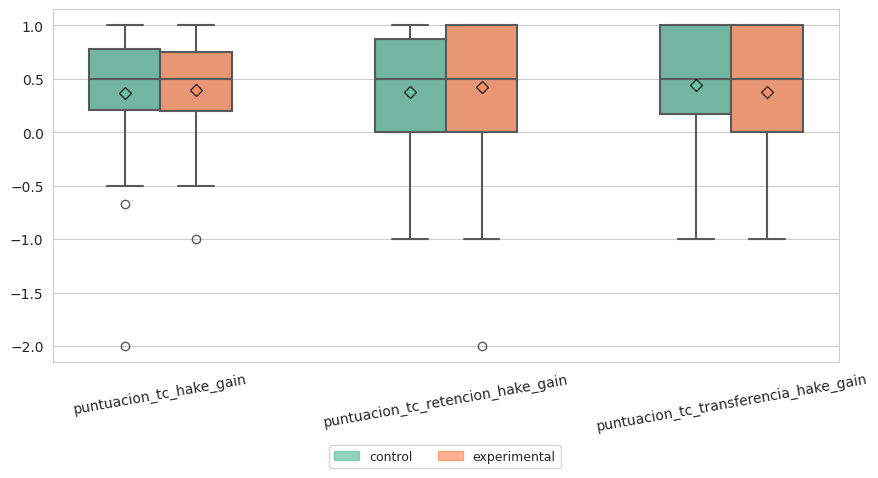

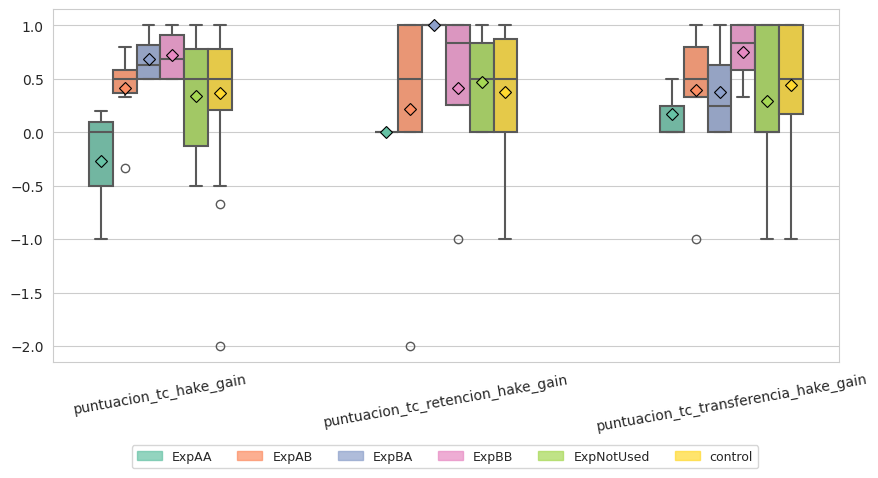

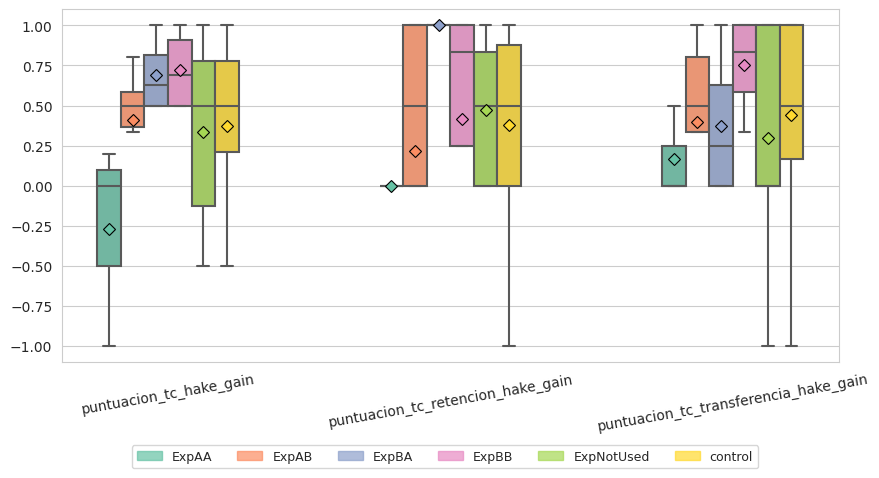


── CONDICIÓN: Baja ──

n = 70


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBB""",5,0.07
"""ExpAB""",12,0.17
"""ExpAA""",3,0.04
"""control""",36,0.51
"""ExpBA""",3,0.04
"""ExpNotUsed""",11,0.16


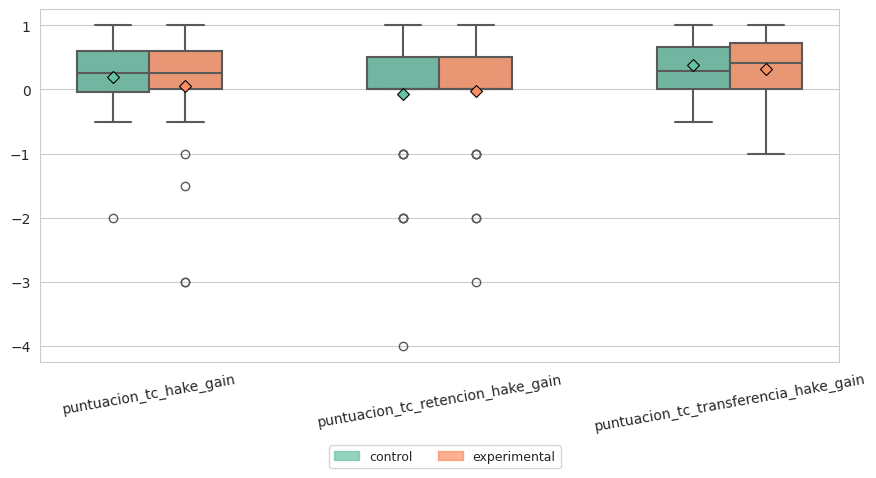

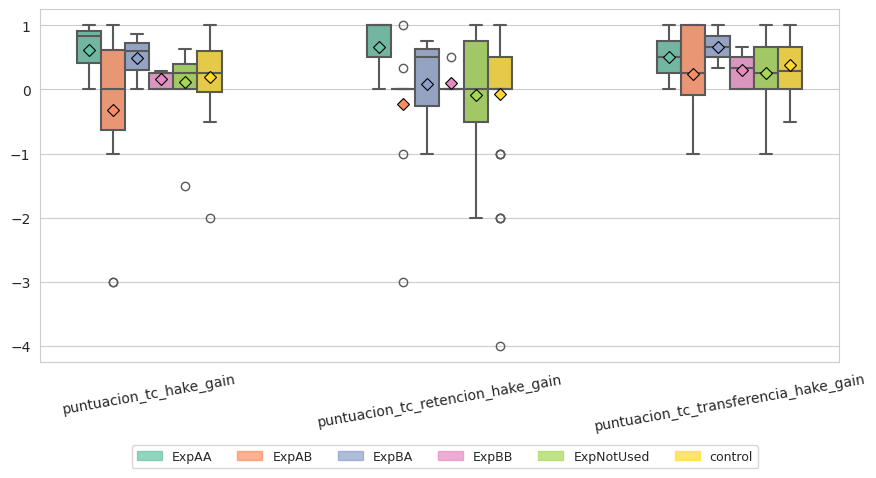

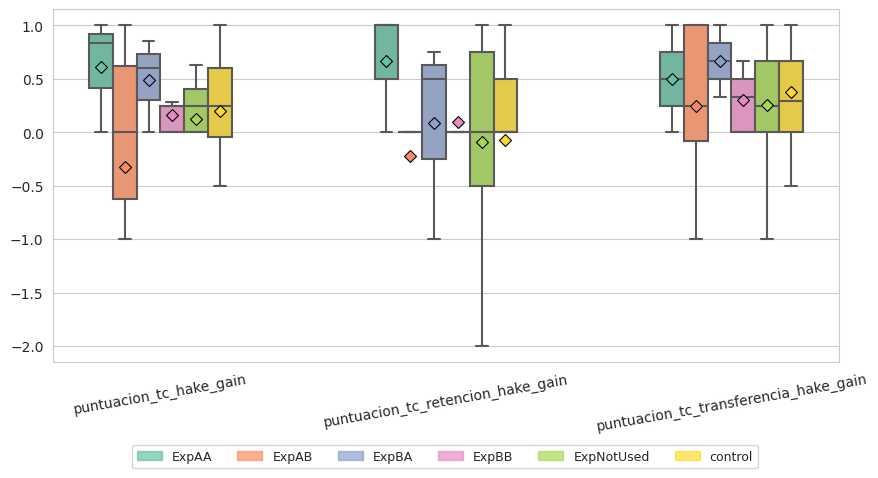


── CONDICIÓN: Alta ──

n = 54


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",6,0.11
"""control""",26,0.48
"""ExpAB""",6,0.11
"""ExpAA""",6,0.11
"""ExpNotUsed""",7,0.13
"""ExpBB""",3,0.06


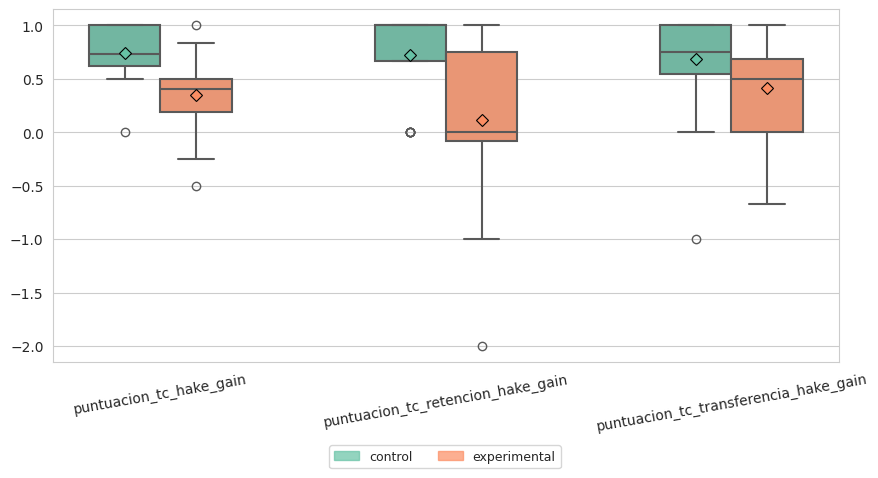

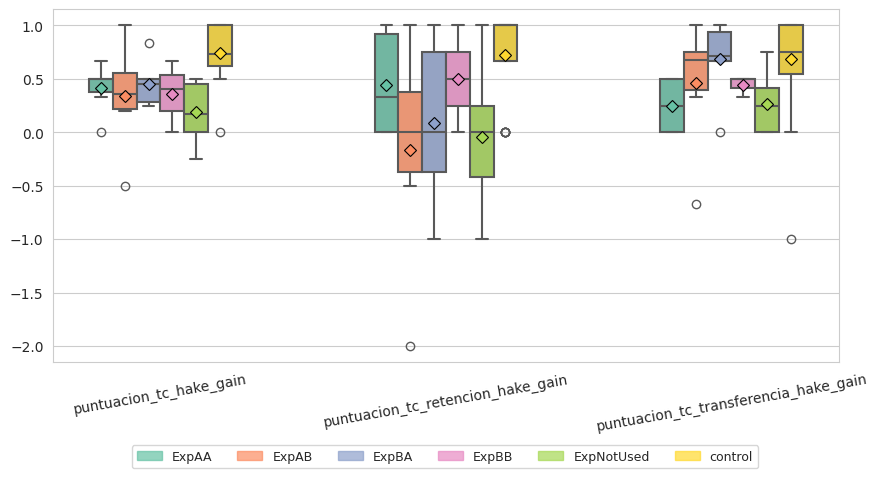

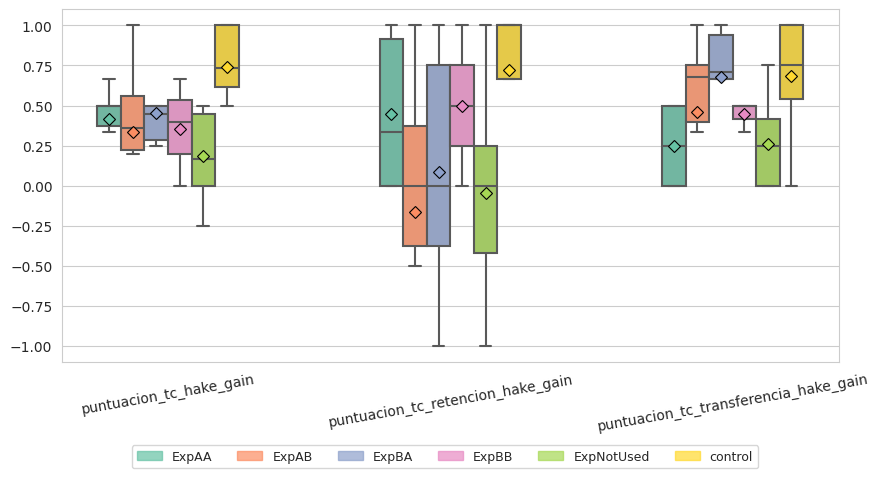

PUNTUACION_TA_CAT_PRE

── CONDICIÓN: Baja ──

n = 76


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",4,0.05
"""control""",47,0.62
"""ExpAA""",4,0.05
"""ExpNotUsed""",13,0.17
"""ExpAB""",4,0.05
"""ExpBB""",4,0.05


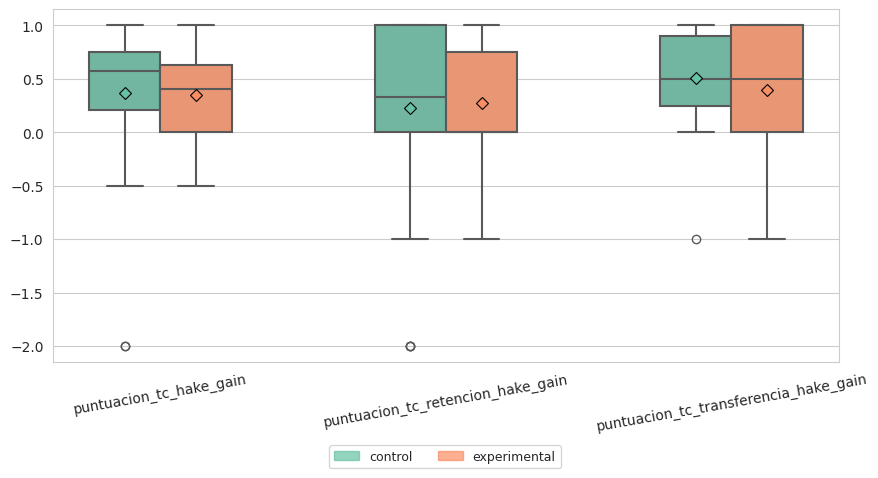

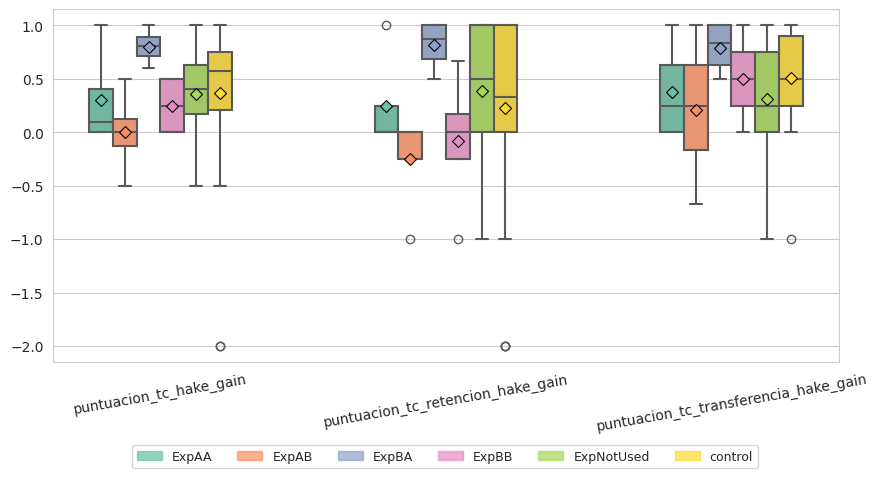

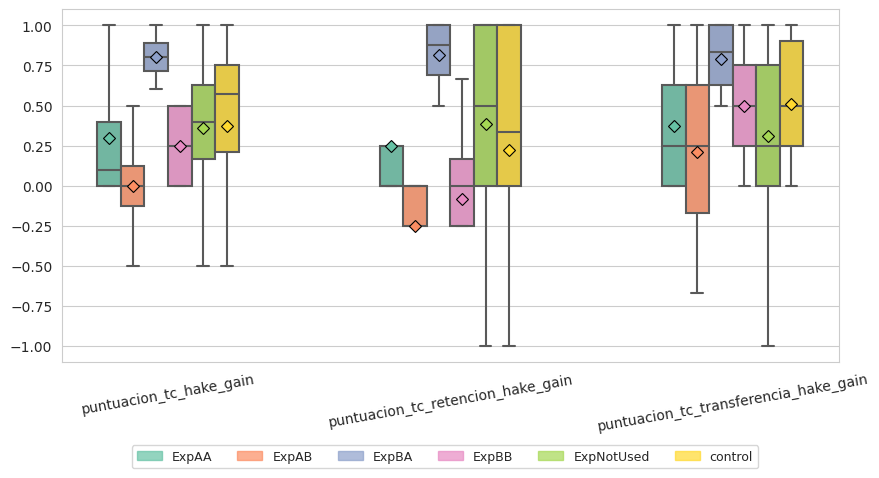


── CONDICIÓN: Media ──

n = 54


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",2,0.04
"""ExpNotUsed""",9,0.17
"""control""",29,0.54
"""ExpAB""",7,0.13
"""ExpAA""",3,0.06
"""ExpBB""",4,0.07


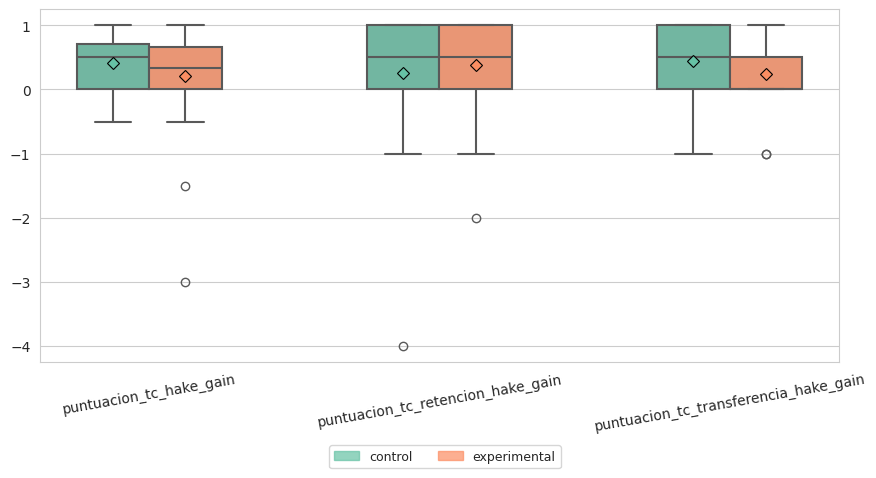

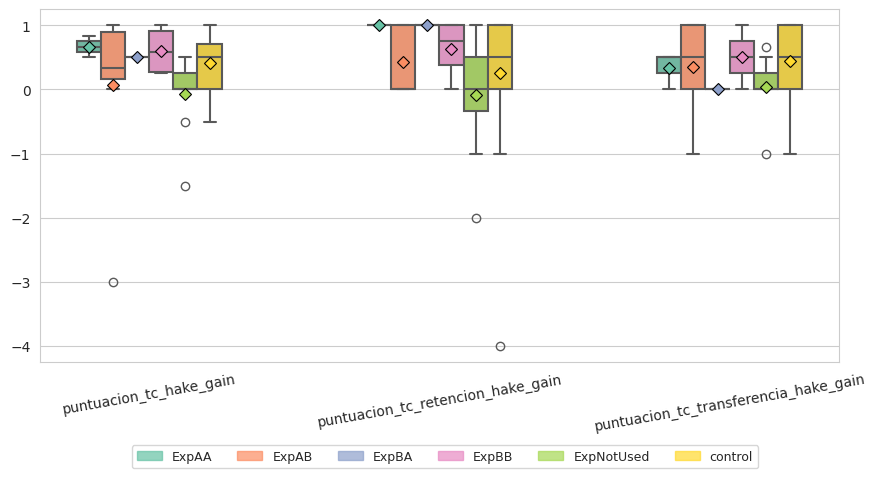

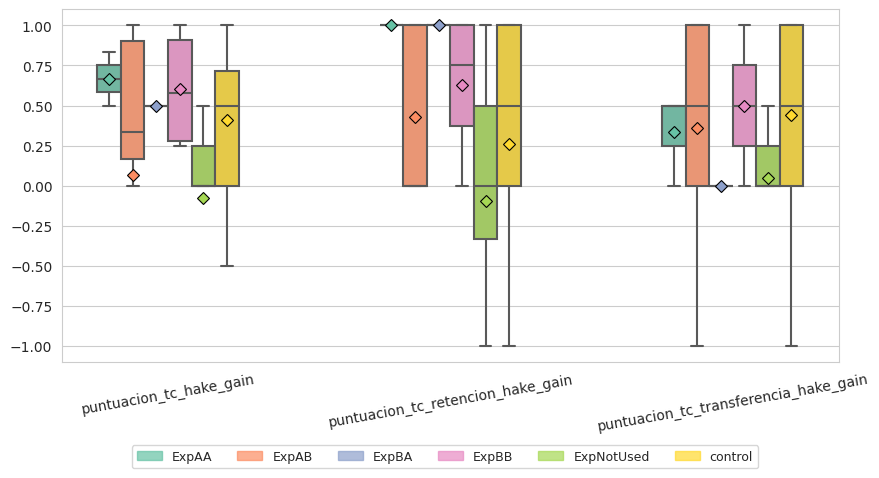


── CONDICIÓN: Alta ──

n = 58


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",7,0.12
"""control""",21,0.36
"""ExpBB""",4,0.07
"""ExpAB""",14,0.24
"""ExpAA""",5,0.09
"""ExpNotUsed""",7,0.12


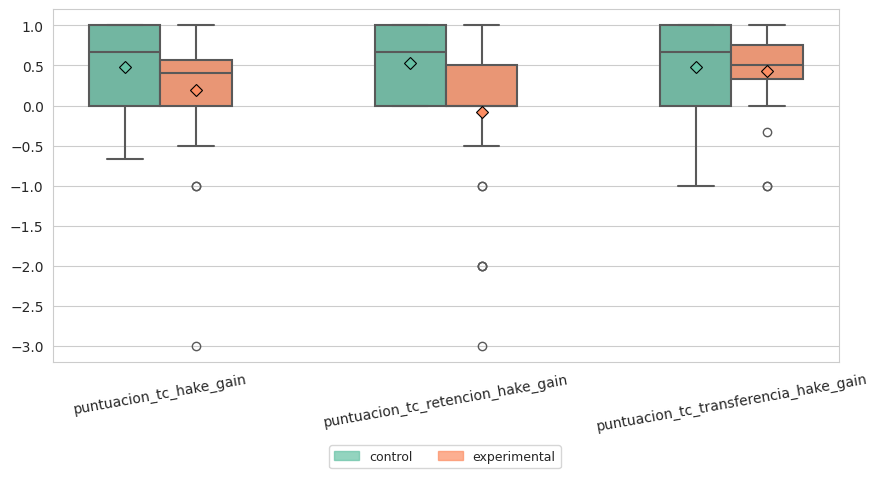

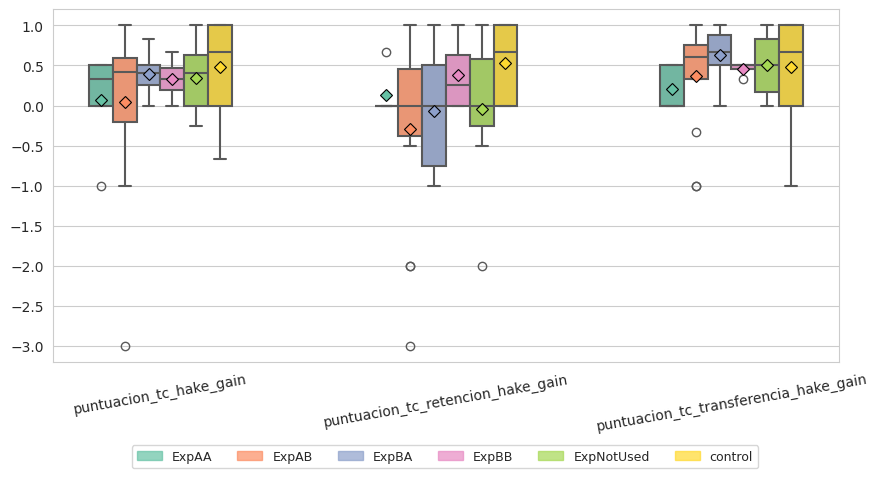

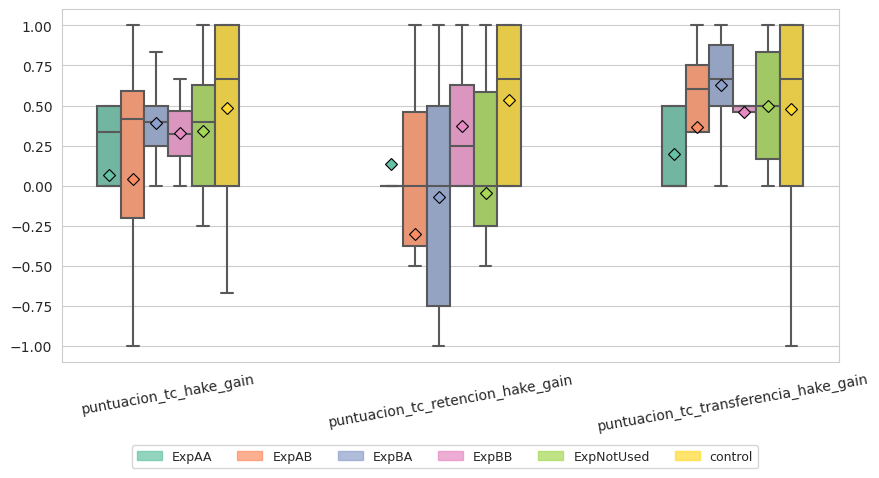

PUNTUACION_TA_CAT_POST

── CONDICIÓN: Baja ──

n = 67


grupo_segmented_v3,count,prop
str,u32,f64
"""control""",36,0.54
"""ExpBA""",4,0.06
"""ExpAB""",8,0.12
"""ExpNotUsed""",12,0.18
"""ExpAA""",2,0.03
"""ExpBB""",5,0.07


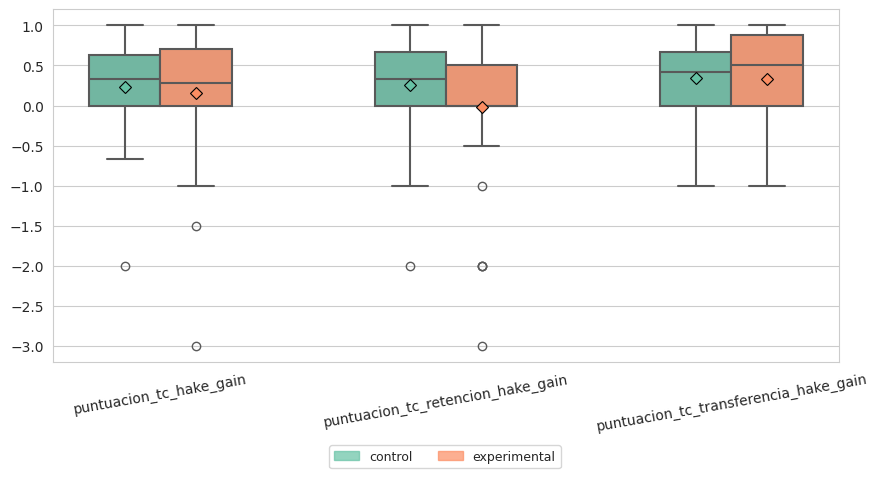

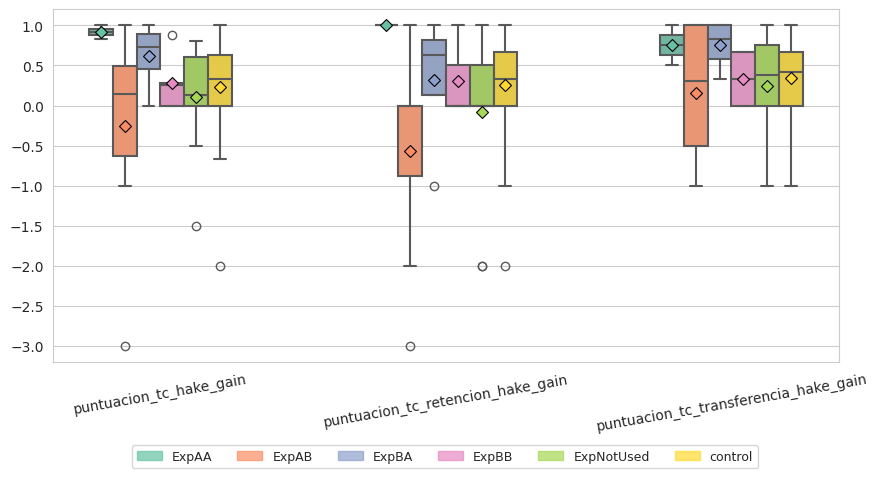

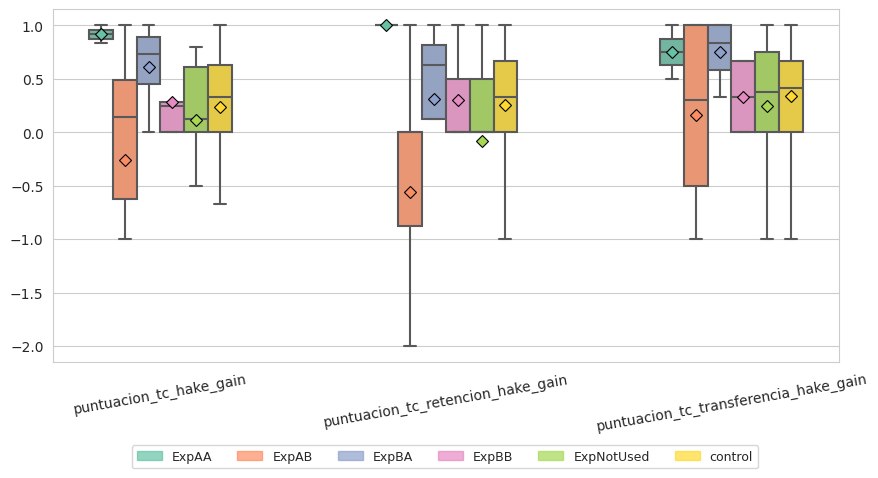


── CONDICIÓN: Media ──

n = 60


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",2,0.03
"""ExpBB""",4,0.07
"""ExpAA""",3,0.05
"""ExpAB""",7,0.12
"""control""",35,0.58
"""ExpNotUsed""",9,0.15


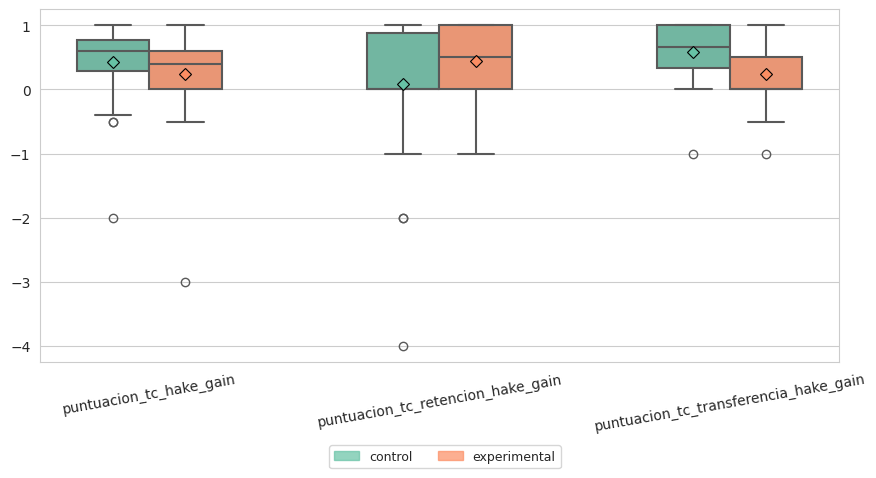

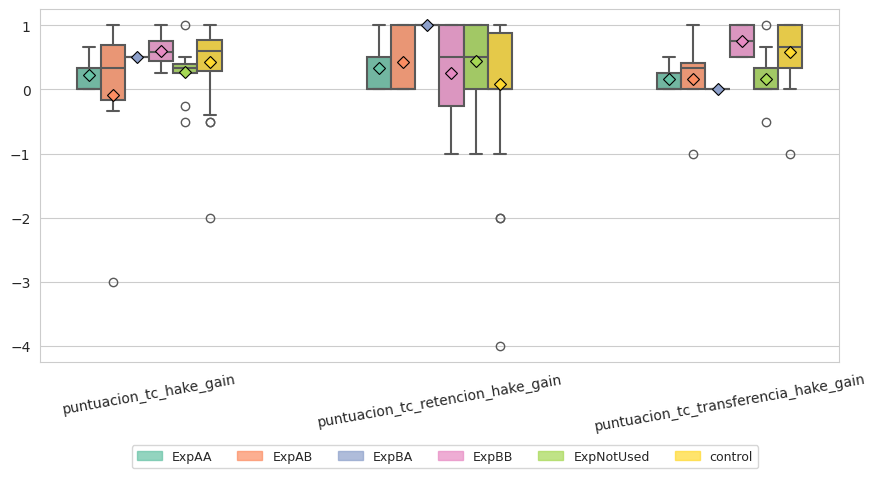

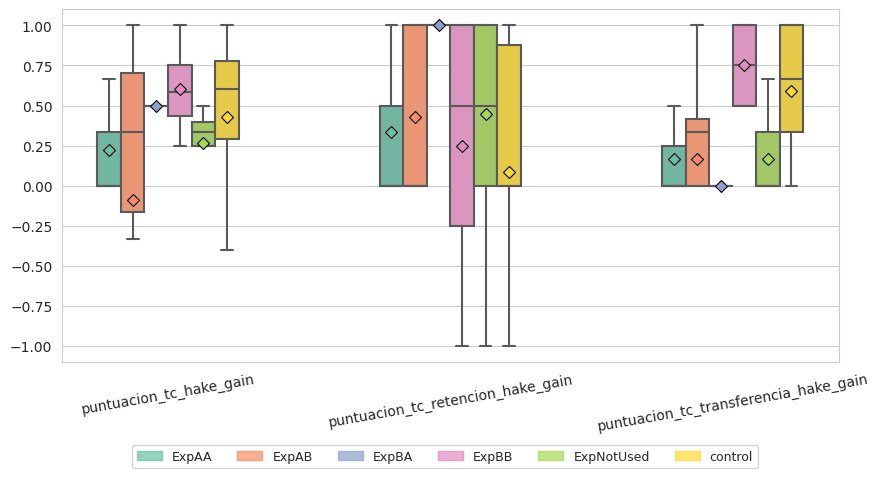


── CONDICIÓN: Alta ──

n = 61


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBB""",3,0.05
"""ExpNotUsed""",8,0.13
"""ExpAB""",10,0.16
"""ExpBA""",7,0.11
"""ExpAA""",7,0.11
"""control""",26,0.43


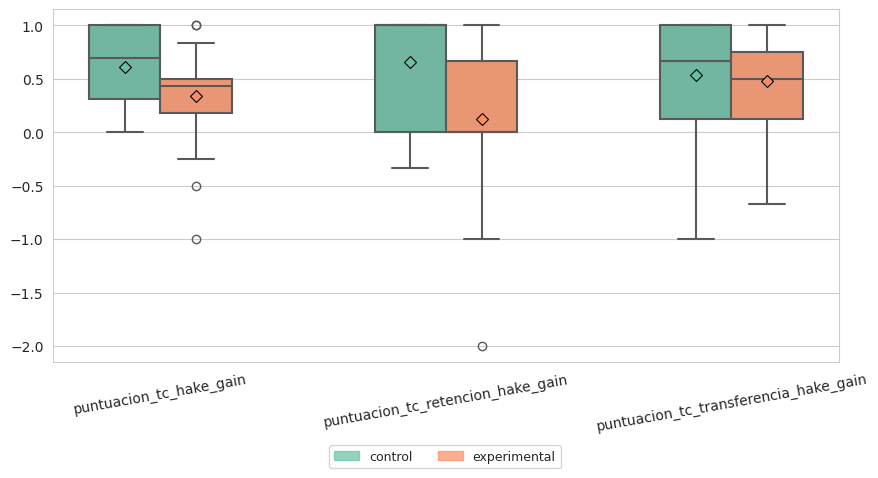

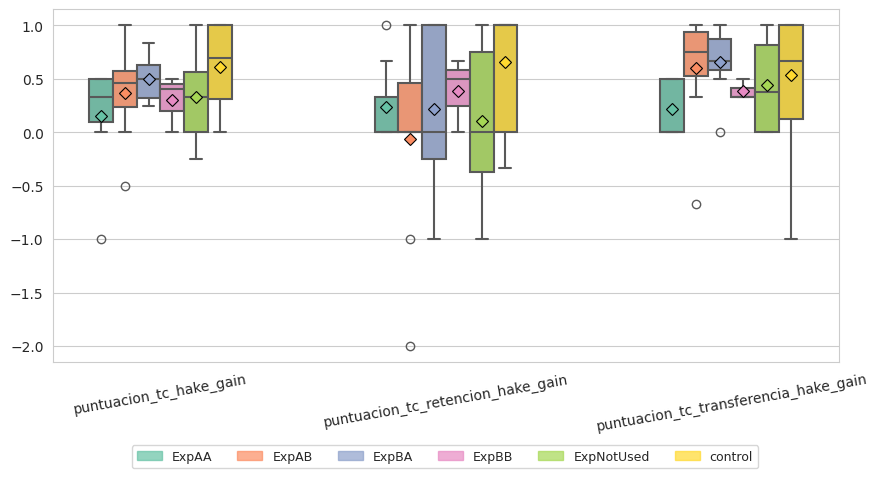

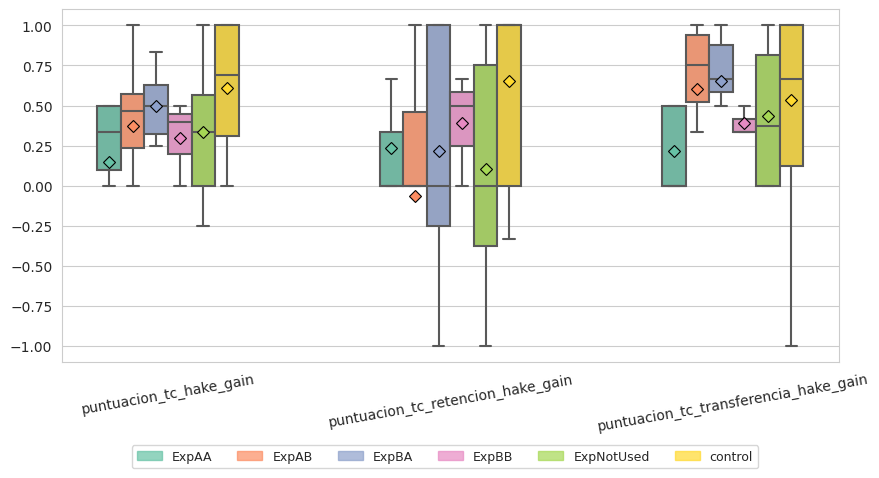

PUNTUACION_TC_CAT_PRE

── CONDICIÓN: Alta ──

n = 43


grupo_segmented_v3,count,prop
str,u32,f64
"""control""",21,0.49
"""ExpBA""",2,0.05
"""ExpNotUsed""",9,0.21
"""ExpBB""",2,0.05
"""ExpAA""",5,0.12
"""ExpAB""",4,0.09


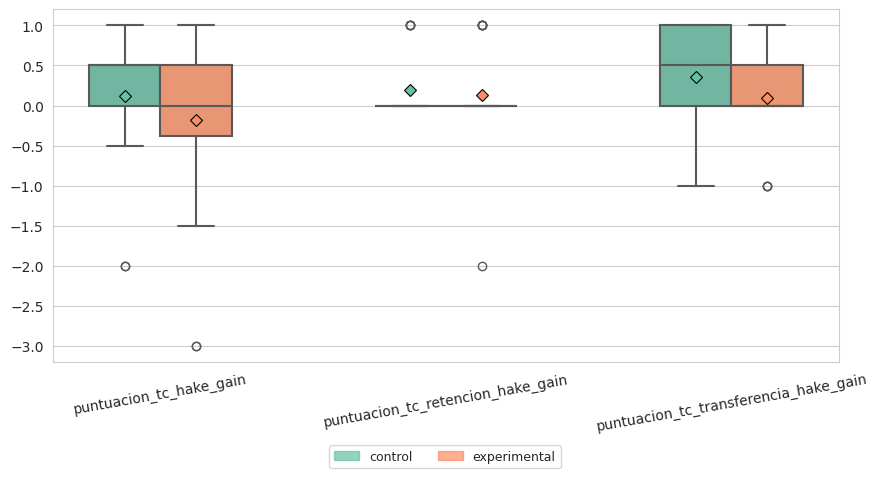

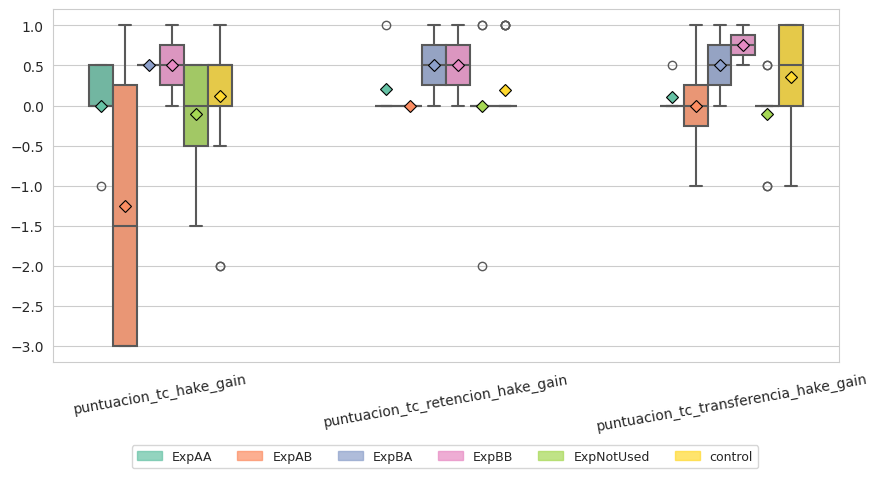

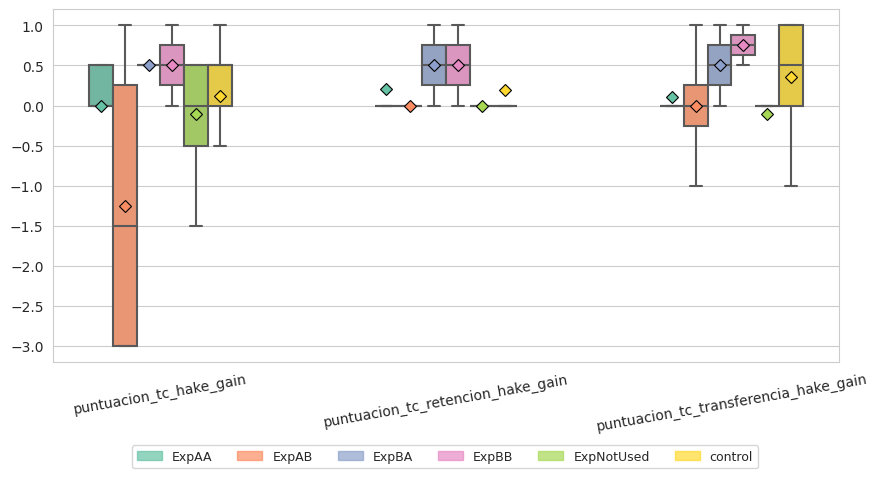


── CONDICIÓN: Media ──

n = 82


grupo_segmented_v3,count,prop
str,u32,f64
"""control""",41,0.5
"""ExpBA""",7,0.09
"""ExpBB""",6,0.07
"""ExpAA""",5,0.06
"""ExpNotUsed""",11,0.13
"""ExpAB""",12,0.15


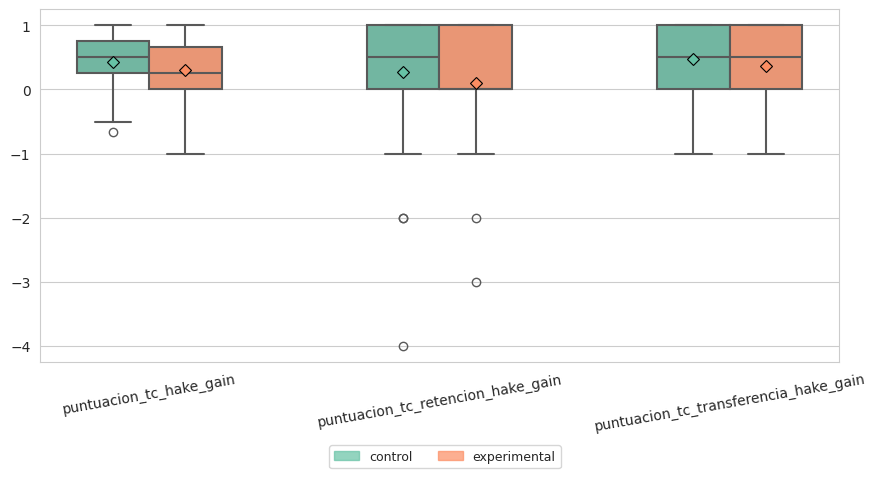

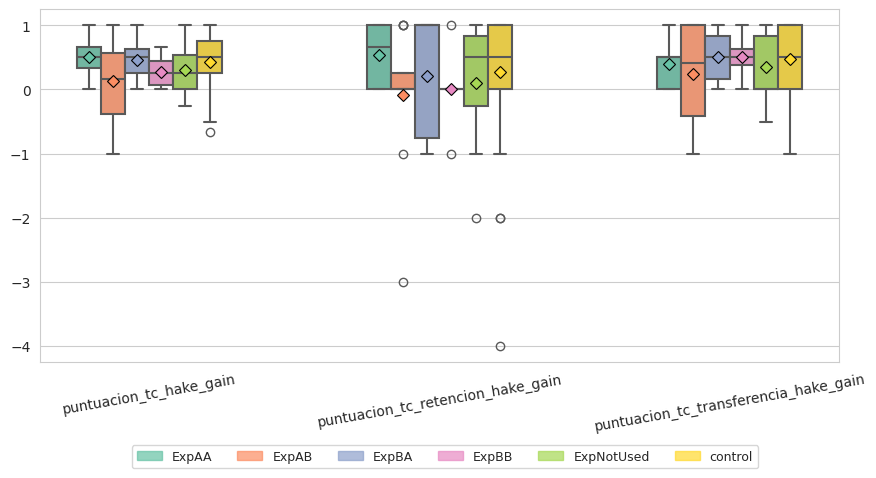

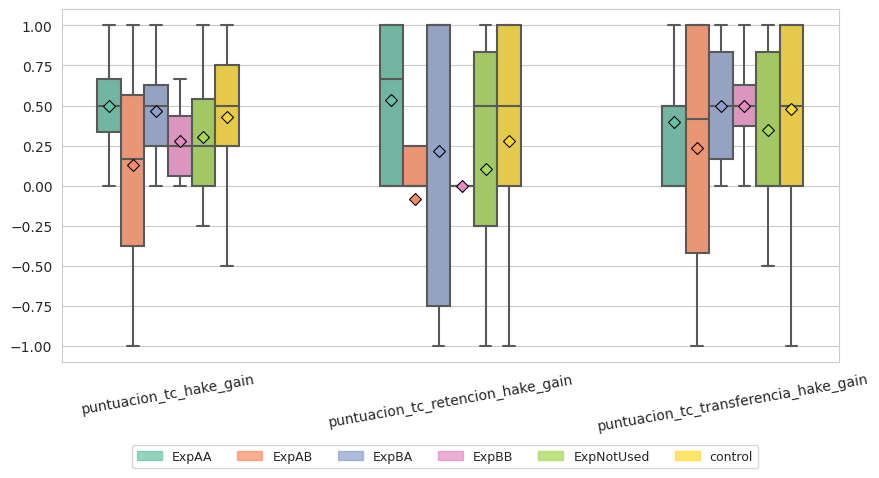


── CONDICIÓN: Baja ──

n = 63


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",9,0.14
"""control""",35,0.56
"""ExpNotUsed""",9,0.14
"""ExpAA""",2,0.03
"""ExpBB""",4,0.06
"""ExpBA""",4,0.06


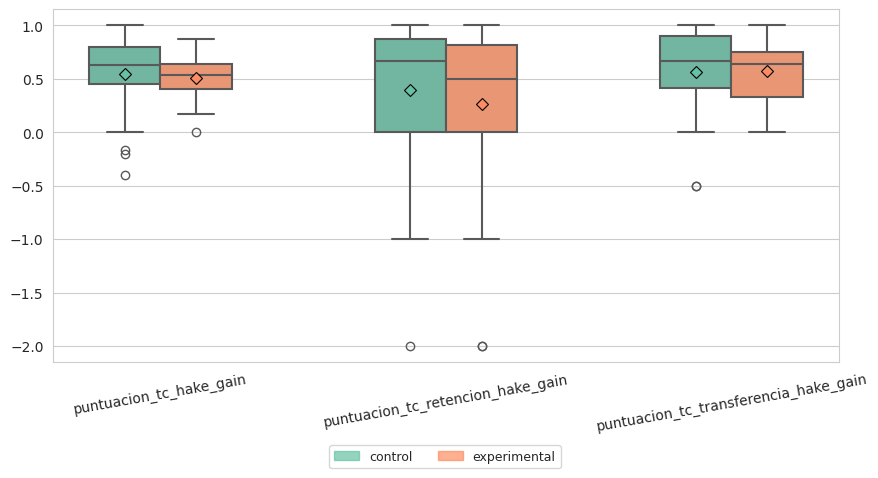

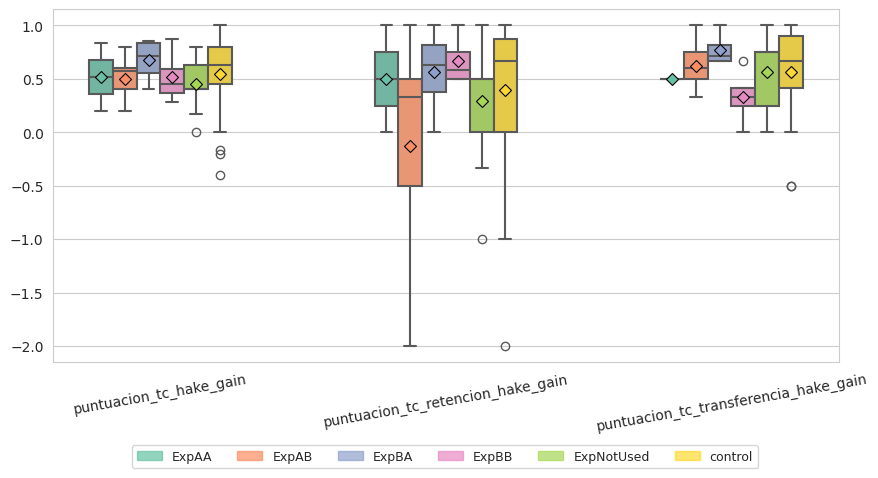

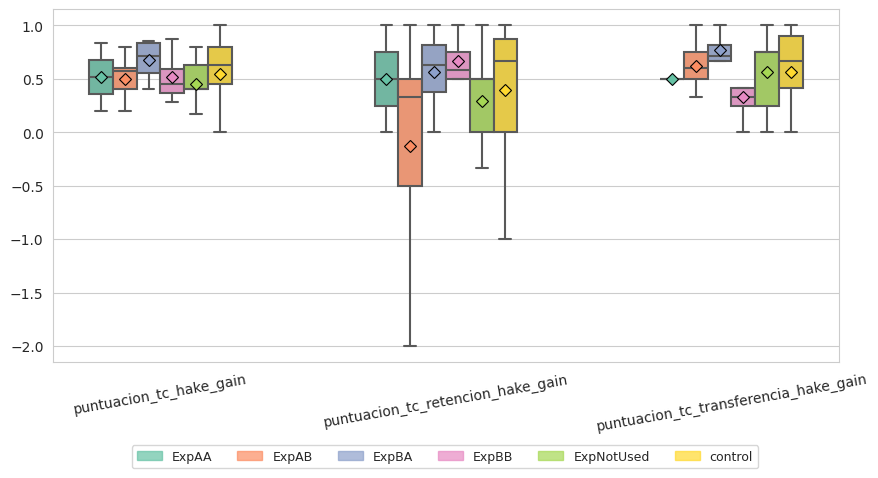

PUNTUACION_TC_CAT_POST

── CONDICIÓN: Media ──

n = 84


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",8,0.1
"""ExpBB""",4,0.05
"""ExpAB""",7,0.08
"""ExpAA""",9,0.11
"""ExpNotUsed""",11,0.13
"""control""",45,0.54


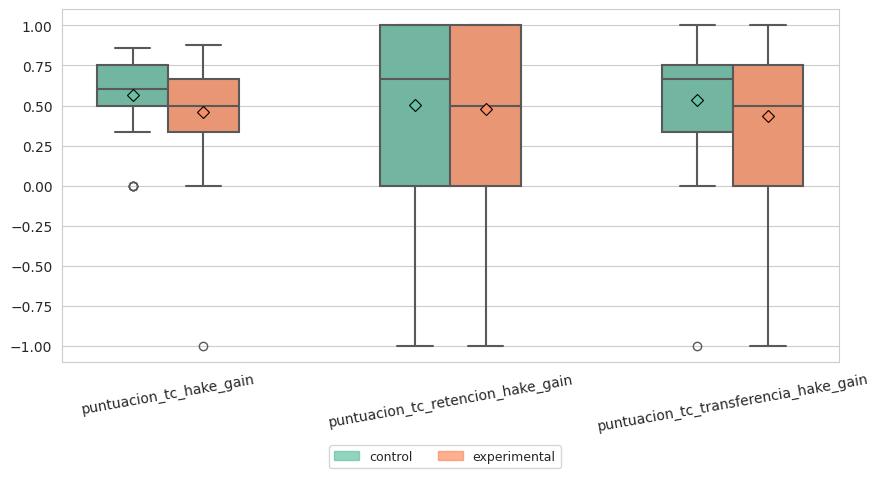

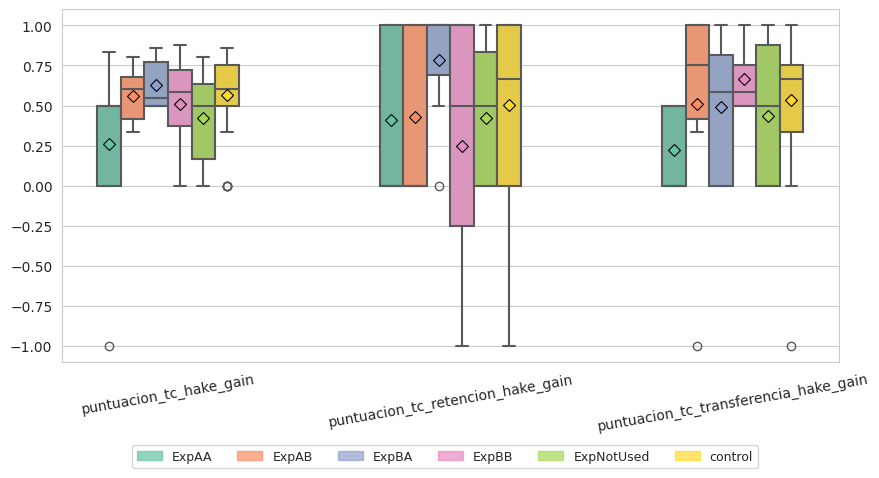

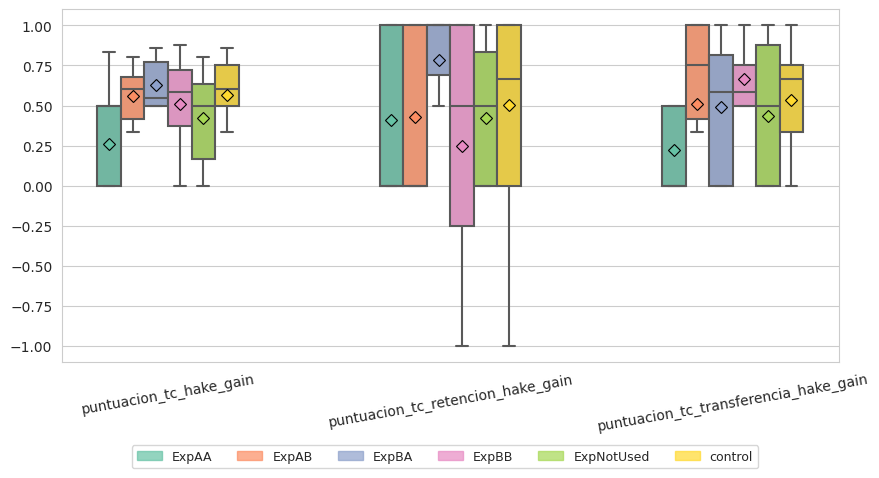


── CONDICIÓN: Alta ──

n = 25


grupo_segmented_v3,count,prop
str,u32,f64
"""control""",17,0.68
"""ExpBA""",1,0.04
"""ExpBB""",1,0.04
"""ExpAB""",3,0.12
"""ExpAA""",1,0.04
"""ExpNotUsed""",2,0.08


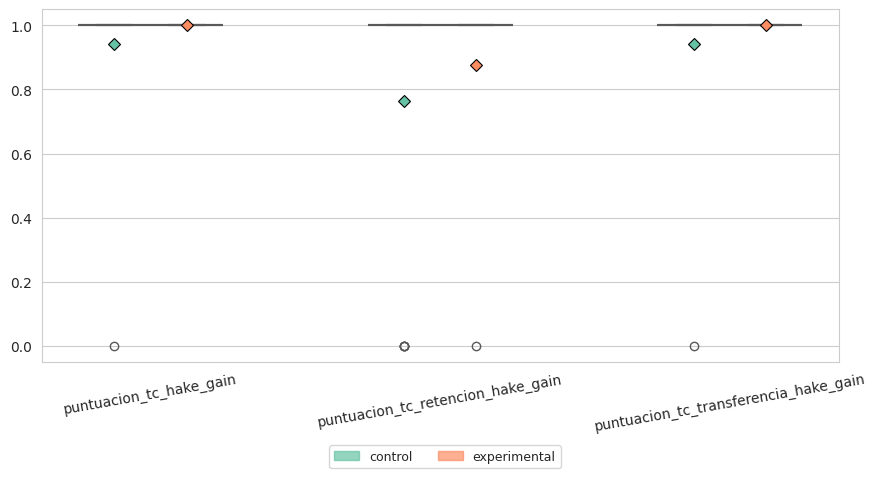

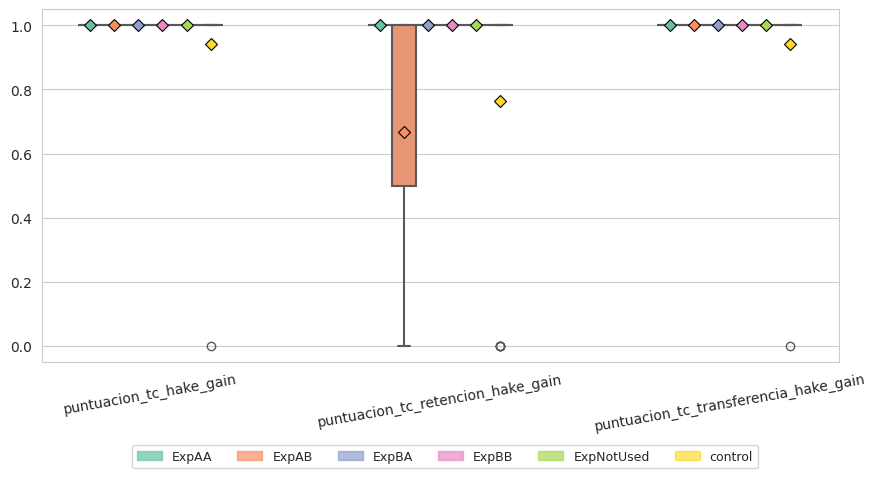

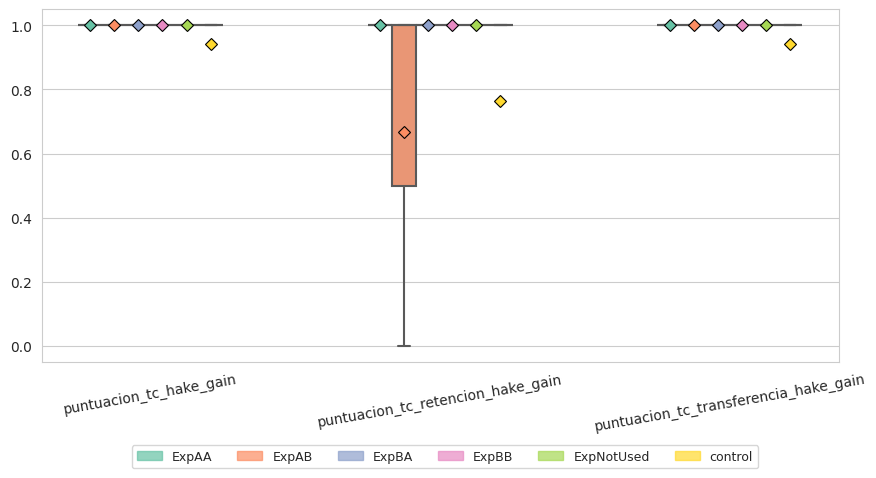


── CONDICIÓN: Baja ──

n = 79


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",15,0.19
"""ExpBA""",4,0.05
"""ExpNotUsed""",16,0.2
"""ExpBB""",7,0.09
"""control""",35,0.44
"""ExpAA""",2,0.03


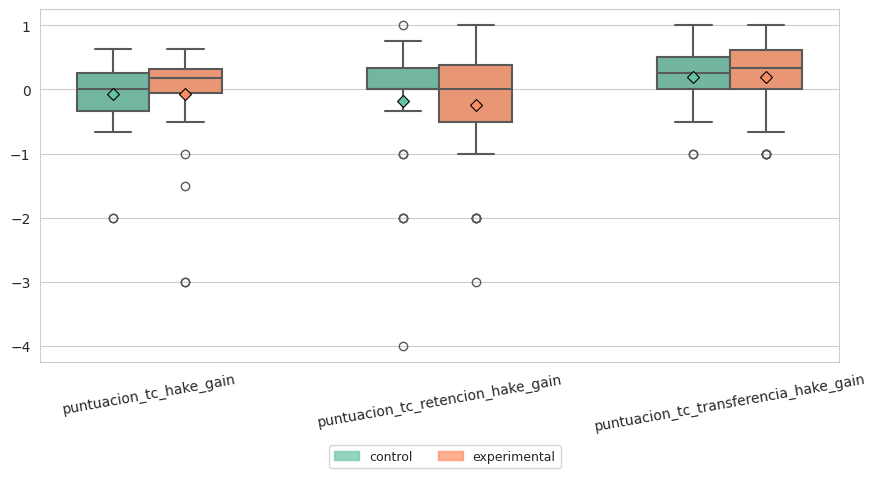

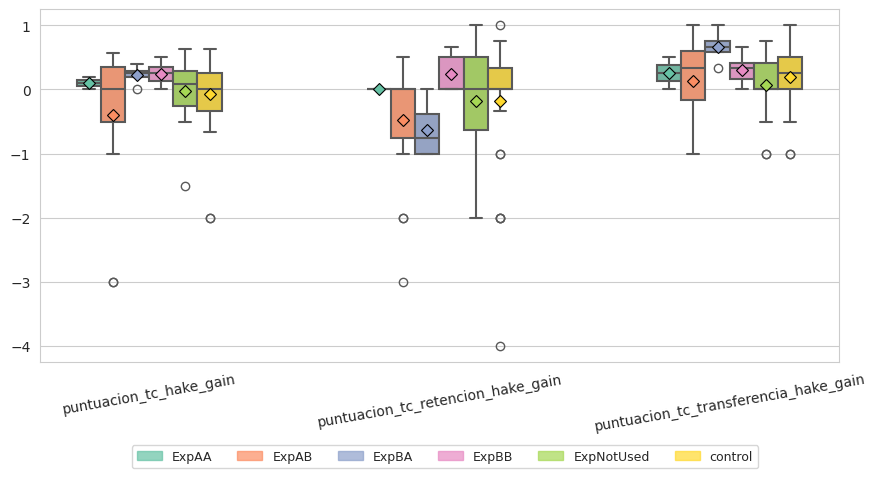

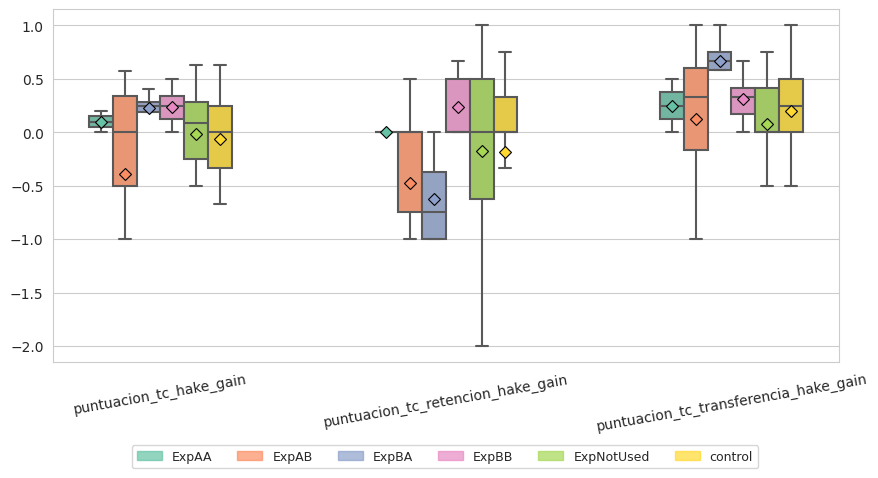

PUNTUACION_TC_CAT_TRAD_SCALE_PRE

── CONDICIÓN: bien ──

n = 53


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpNotUsed""",9,0.17
"""ExpBB""",3,0.06
"""ExpAA""",2,0.04
"""ExpBA""",7,0.13
"""control""",25,0.47
"""ExpAB""",7,0.13


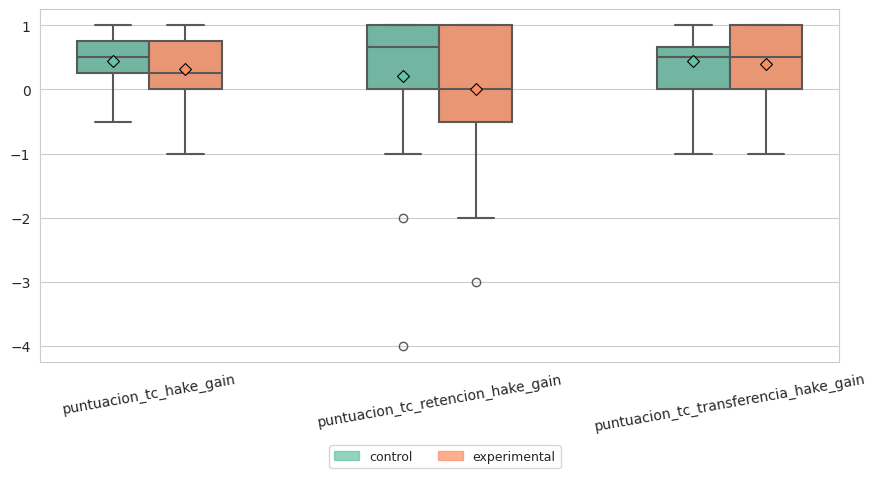

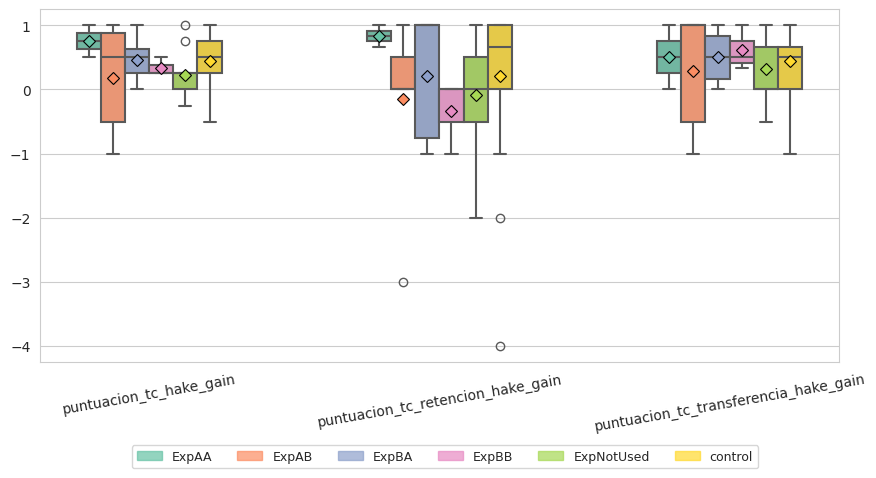

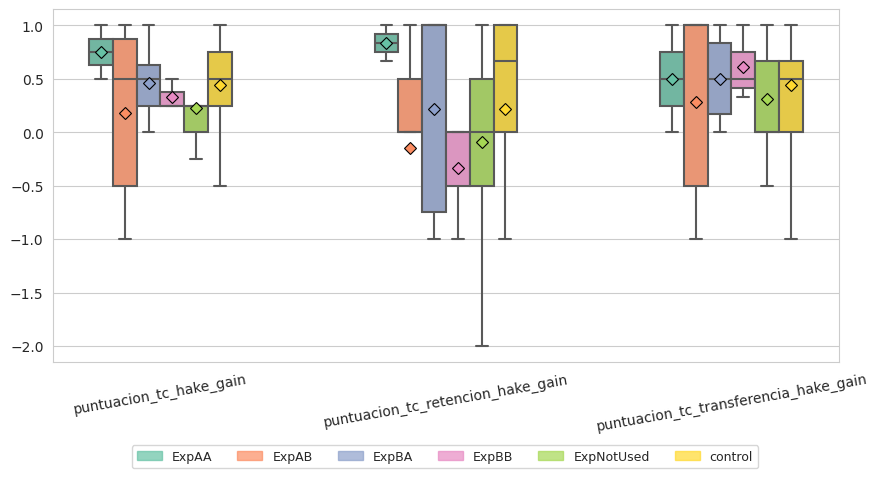


── CONDICIÓN: notable ──

n = 58


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",6,0.1
"""ExpBA""",2,0.03
"""control""",29,0.5
"""ExpAA""",7,0.12
"""ExpBB""",5,0.09
"""ExpNotUsed""",9,0.16


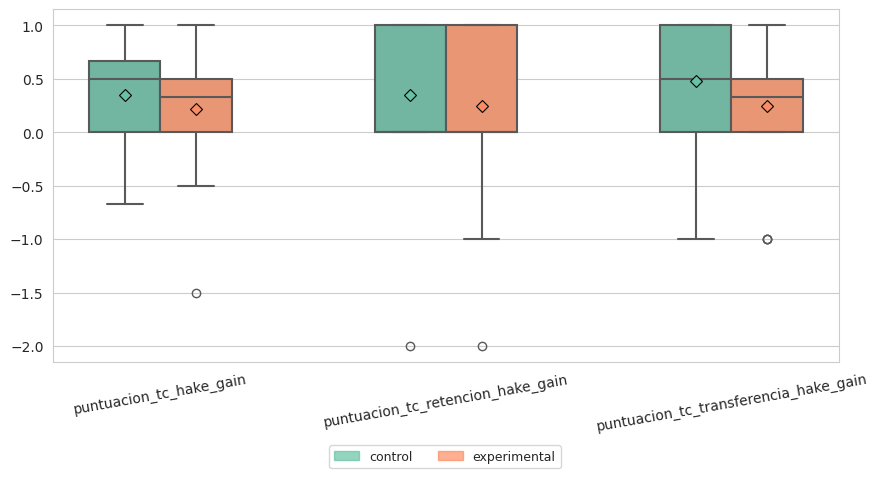

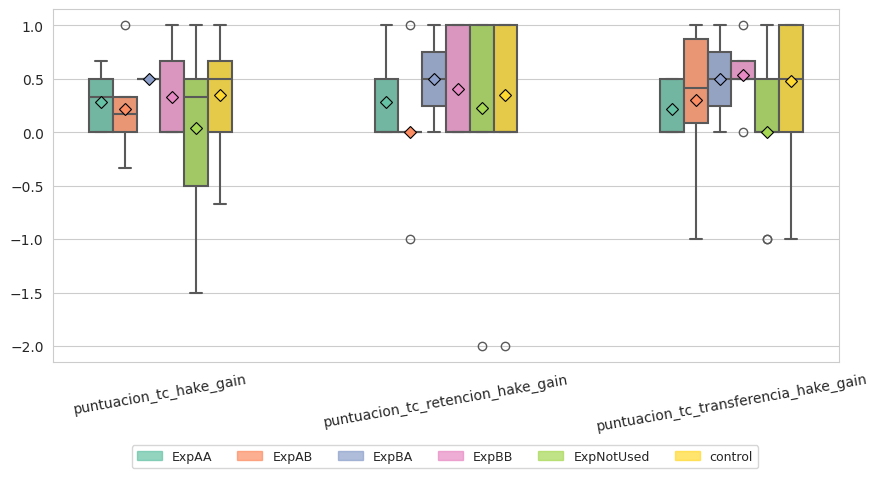

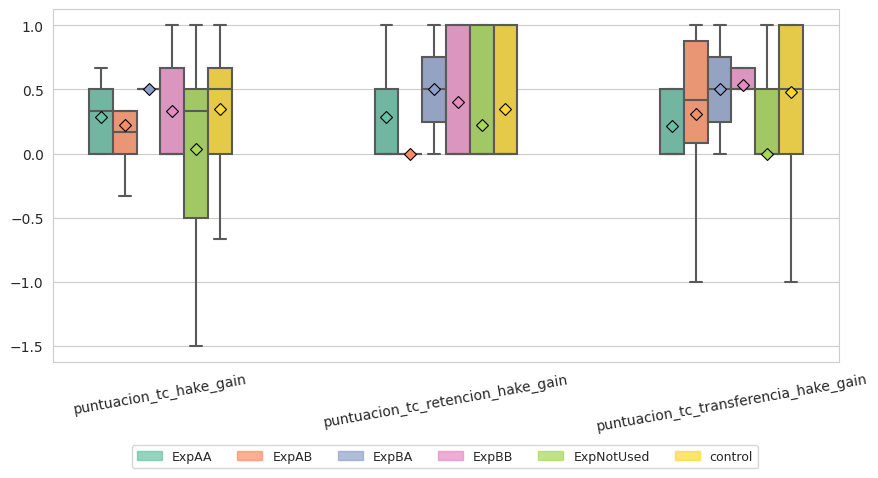


── CONDICIÓN: sobresaliente ──

n = 14


grupo_segmented_v3,count,prop
str,u32,f64
"""control""",8,0.57
"""ExpAA""",1,0.07
"""ExpNotUsed""",2,0.14
"""ExpAB""",3,0.21


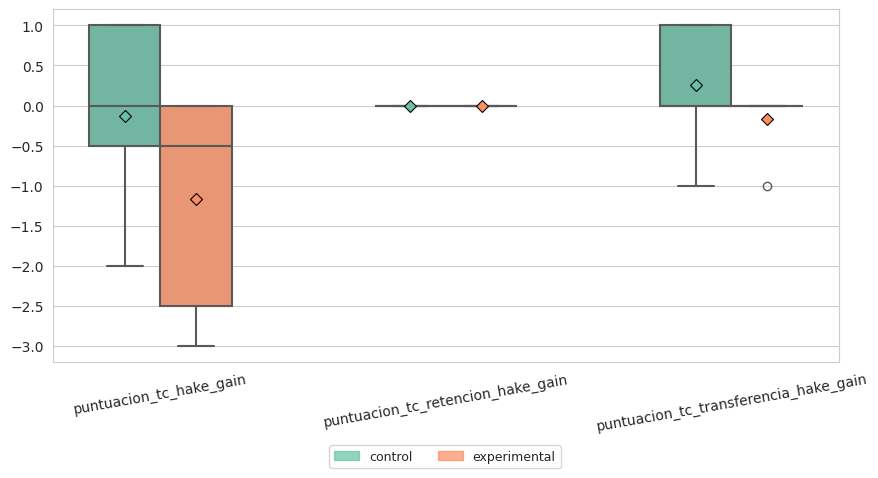

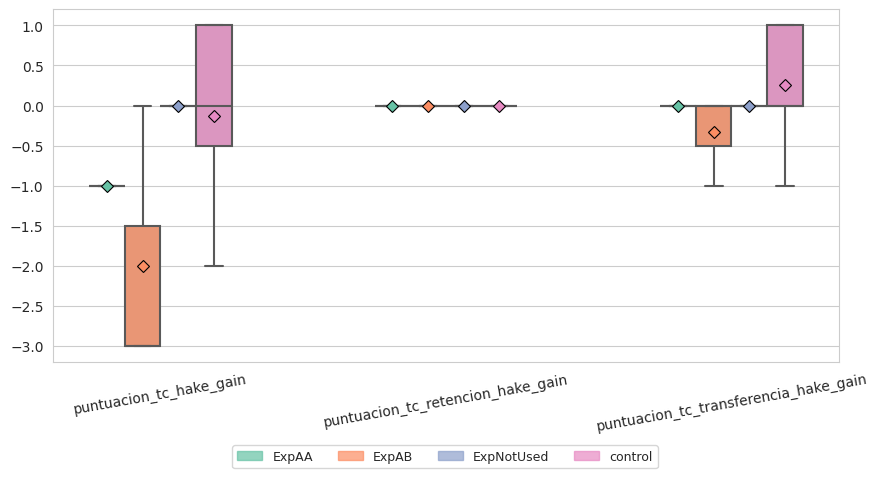

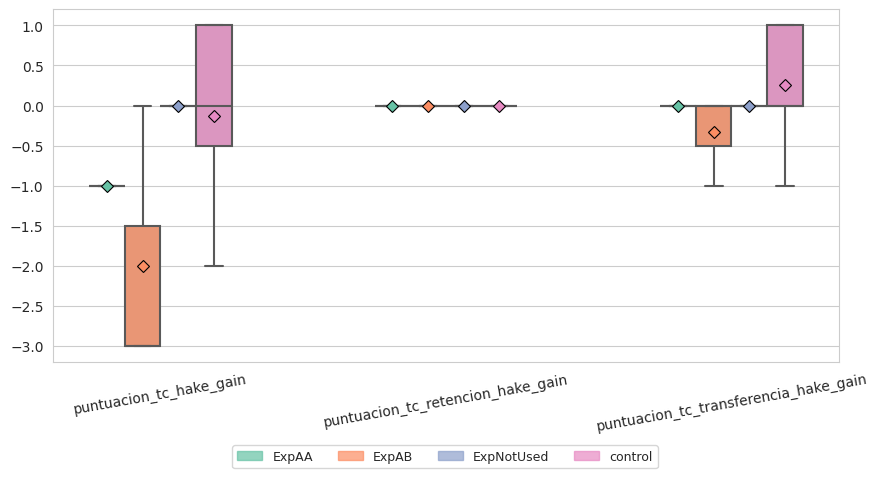


── CONDICIÓN: suspenso ──

n = 33


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBB""",3,0.09
"""ExpBA""",2,0.06
"""ExpAA""",1,0.03
"""control""",19,0.58
"""ExpNotUsed""",4,0.12
"""ExpAB""",4,0.12


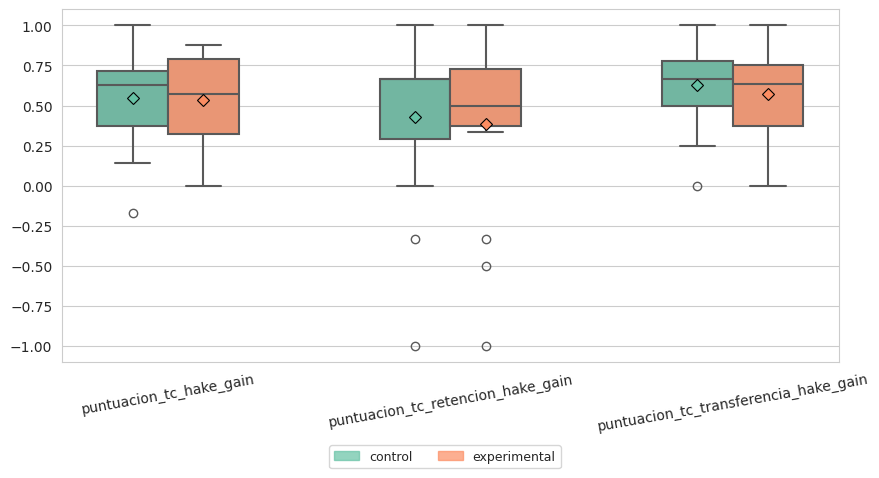

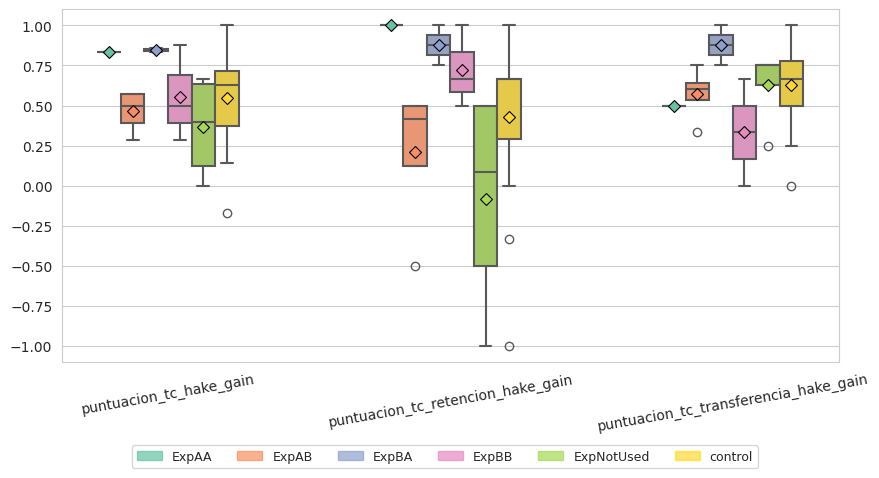

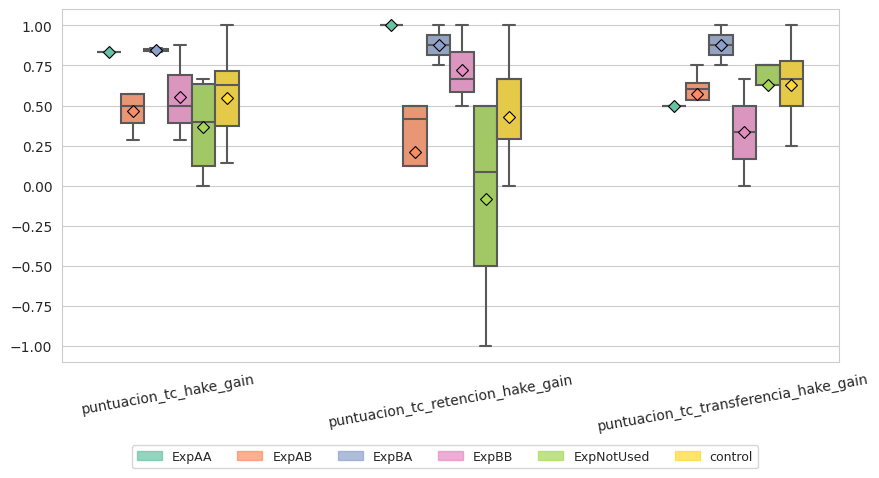


── CONDICIÓN: suficiente ──

n = 30


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",2,0.07
"""ExpNotUsed""",5,0.17
"""control""",16,0.53
"""ExpAA""",1,0.03
"""ExpAB""",5,0.17
"""ExpBB""",1,0.03


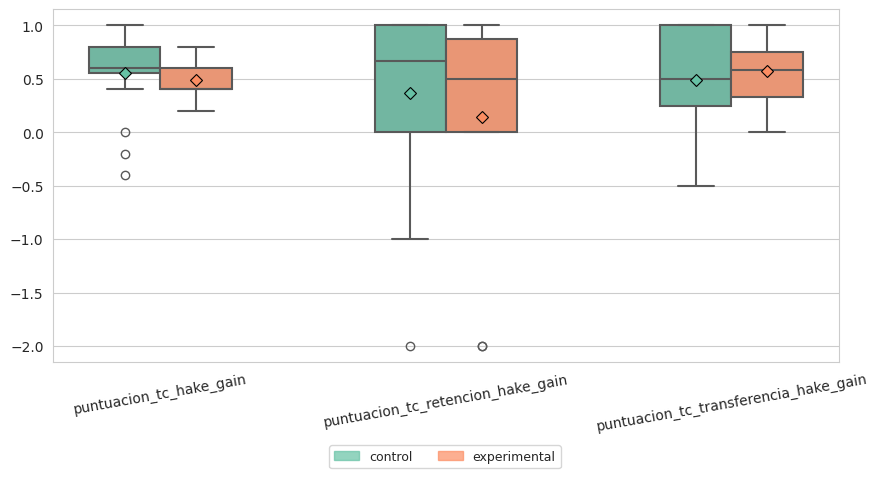

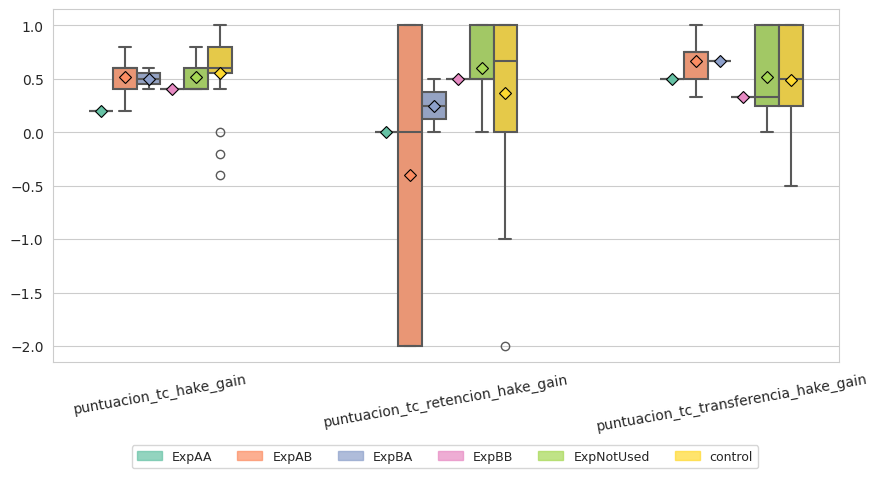

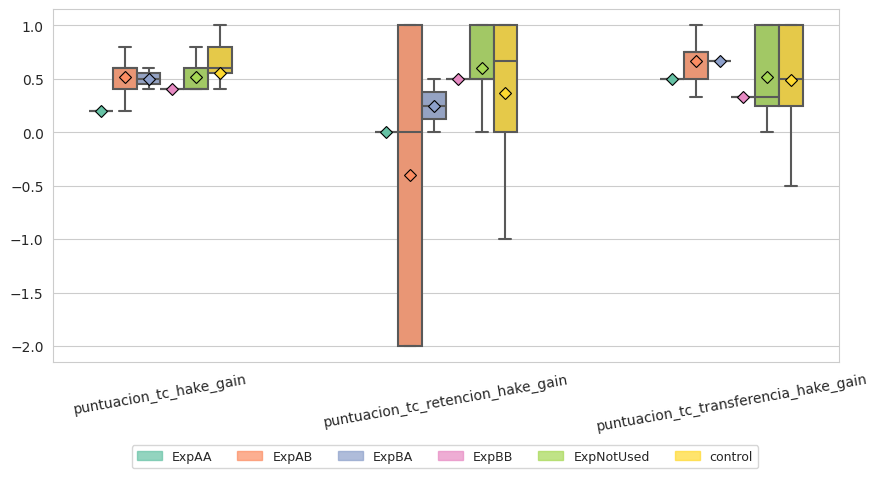

PUNTUACION_TC_CAT_TRAD_SCALE_POST

── CONDICIÓN: bien ──

n = 15


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpNotUsed""",2,0.13
"""ExpAB""",5,0.33
"""ExpAA""",1,0.07
"""ExpBA""",1,0.07
"""control""",6,0.4


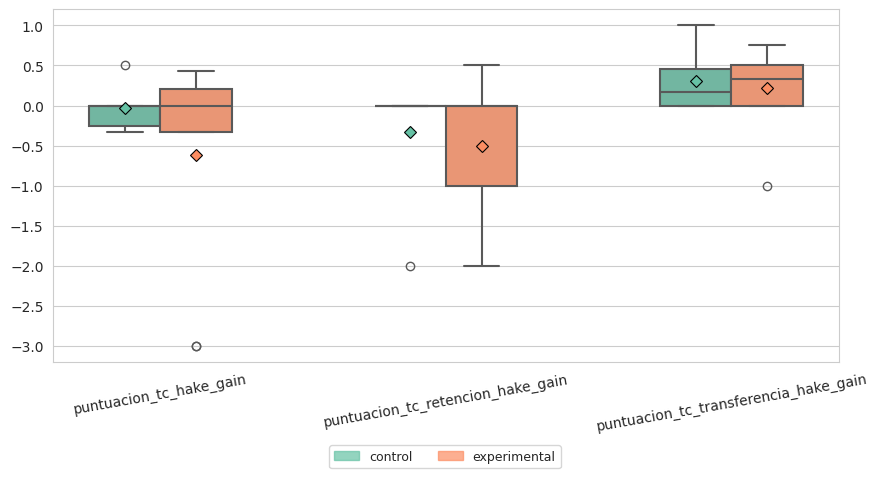

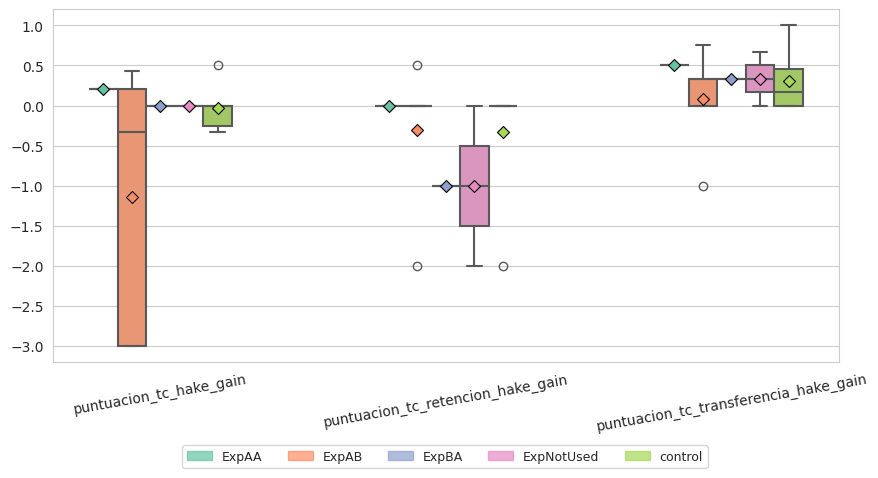

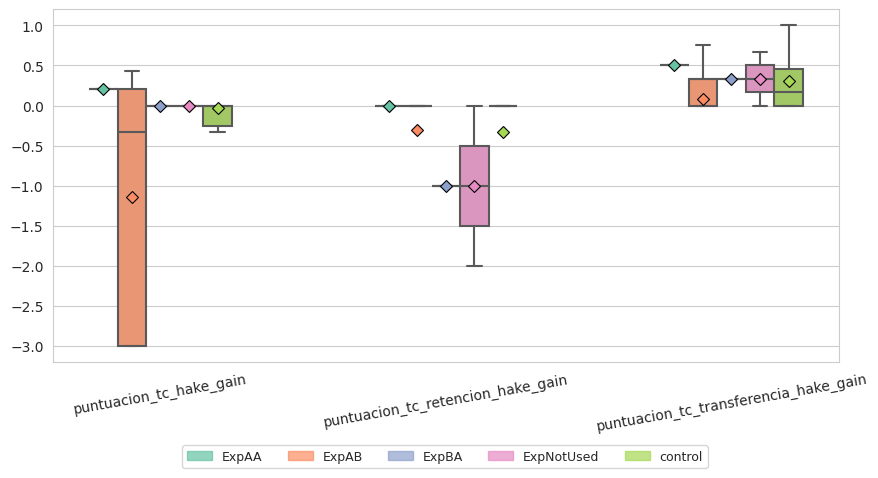


── CONDICIÓN: suficiente ──

n = 12


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpNotUsed""",4,0.33
"""control""",5,0.42
"""ExpBB""",1,0.08
"""ExpAB""",2,0.17


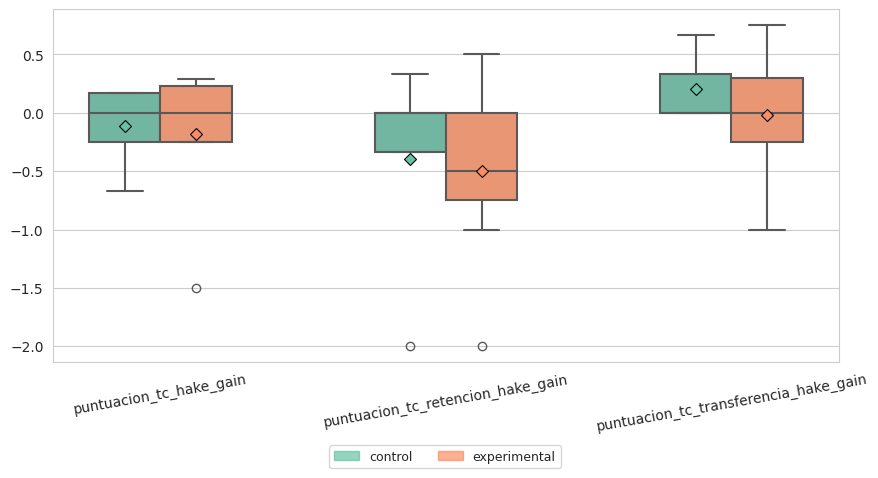

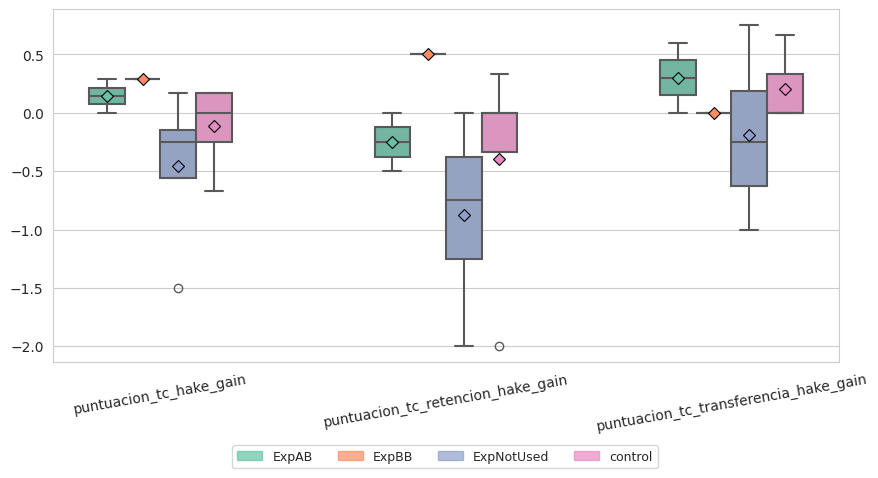

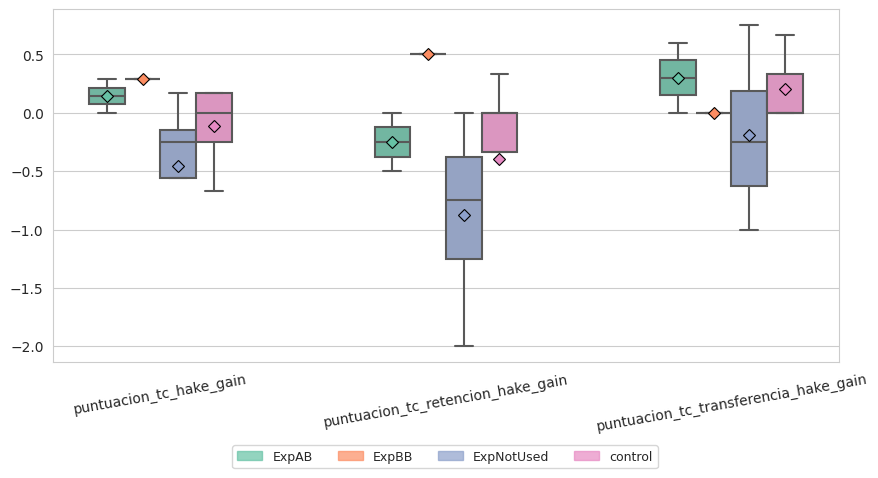


── CONDICIÓN: suspenso ──

n = 10


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",3,0.3
"""ExpNotUsed""",1,0.1
"""control""",6,0.6


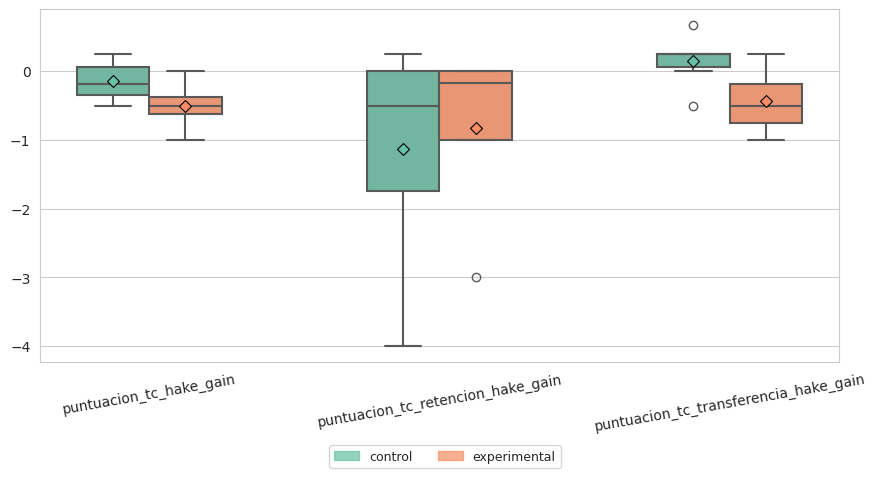

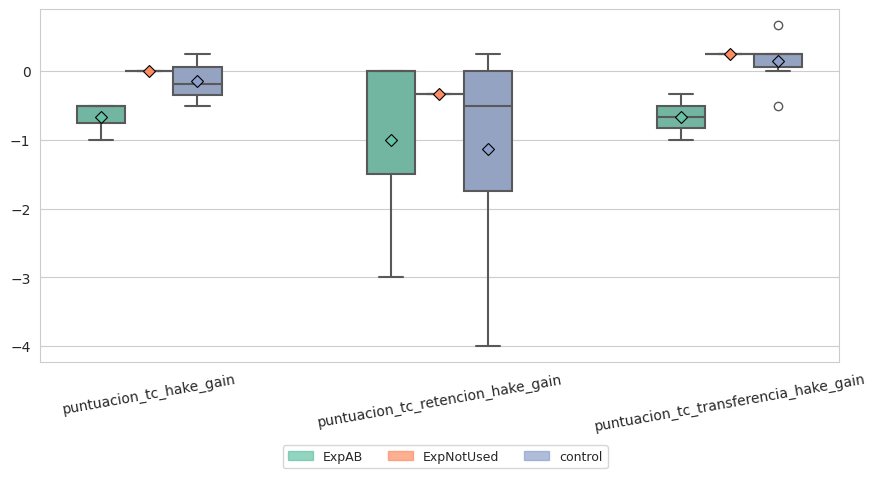

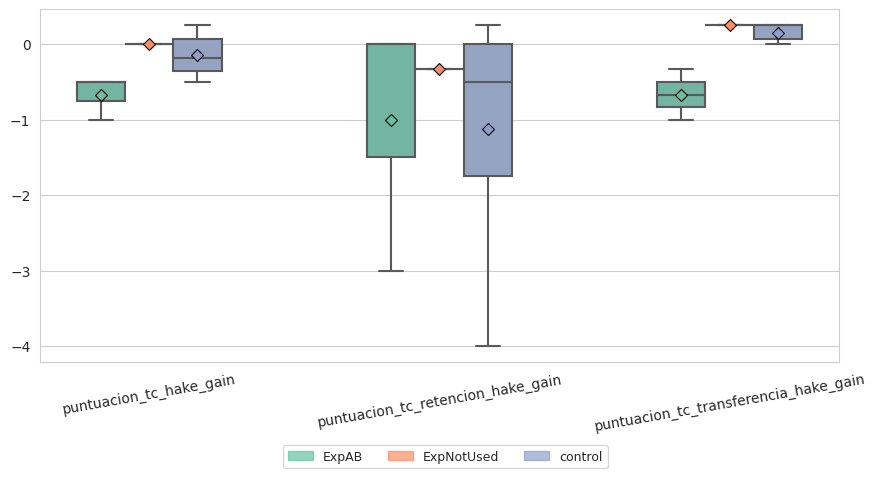


── CONDICIÓN: sobresaliente ──

n = 69


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",6,0.09
"""ExpBB""",3,0.04
"""ExpAA""",5,0.07
"""control""",42,0.61
"""ExpAB""",5,0.07
"""ExpNotUsed""",8,0.12


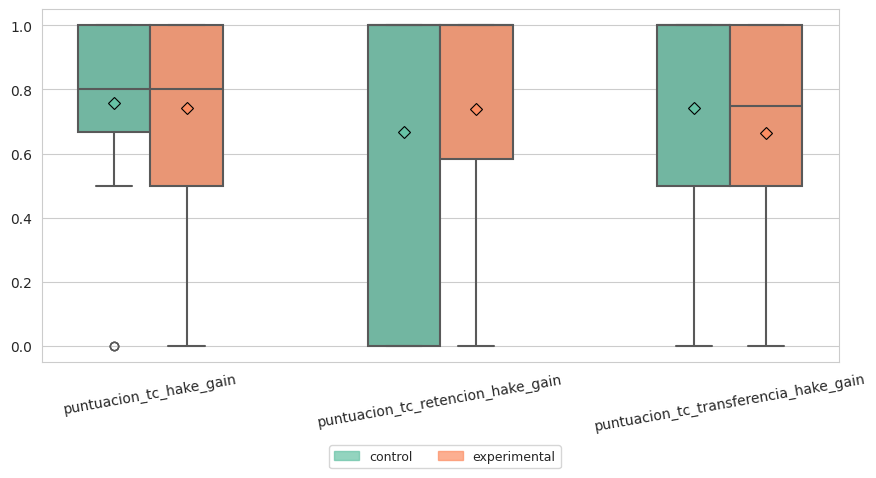

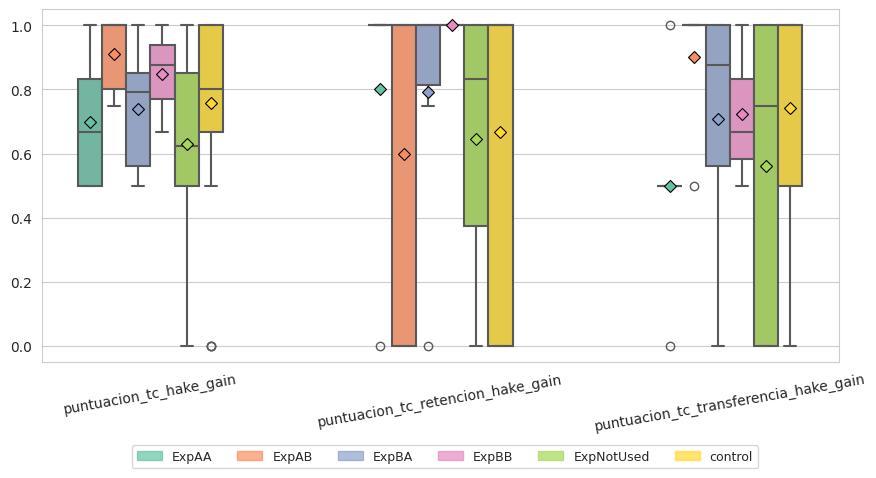

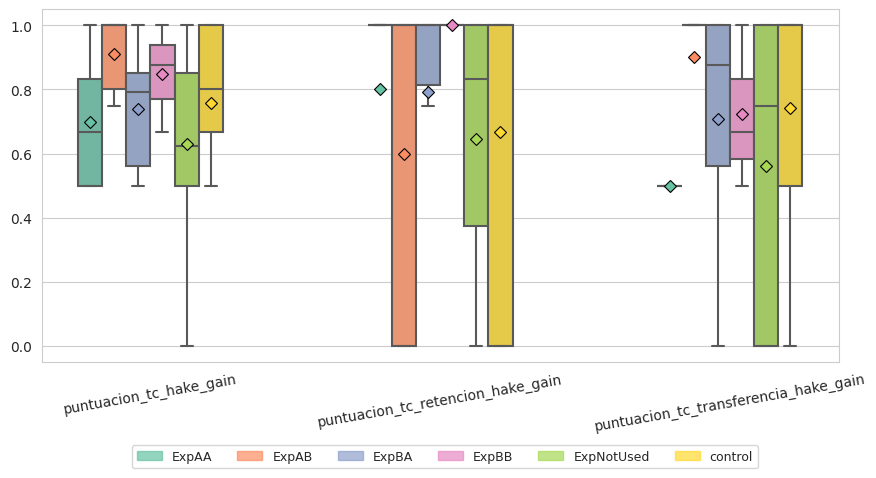


── CONDICIÓN: notable ──

n = 82


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",6,0.07
"""ExpAA""",6,0.07
"""ExpBB""",8,0.1
"""ExpAB""",10,0.12
"""ExpNotUsed""",14,0.17
"""control""",38,0.46


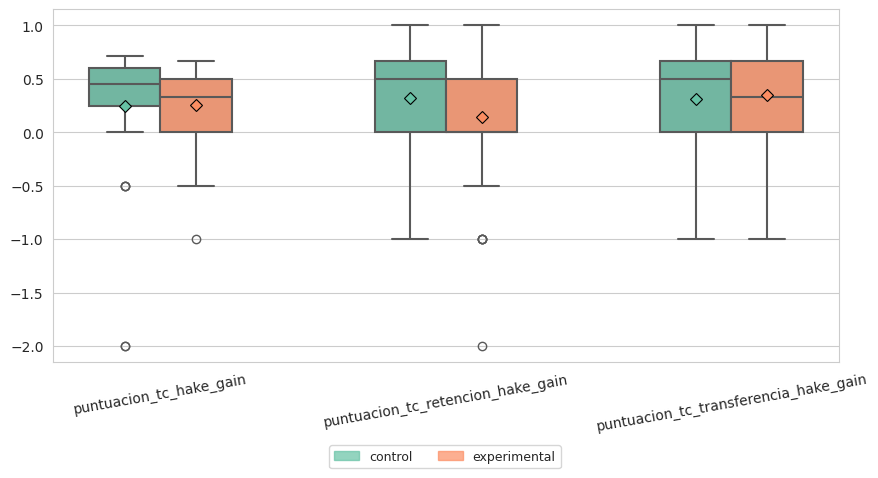

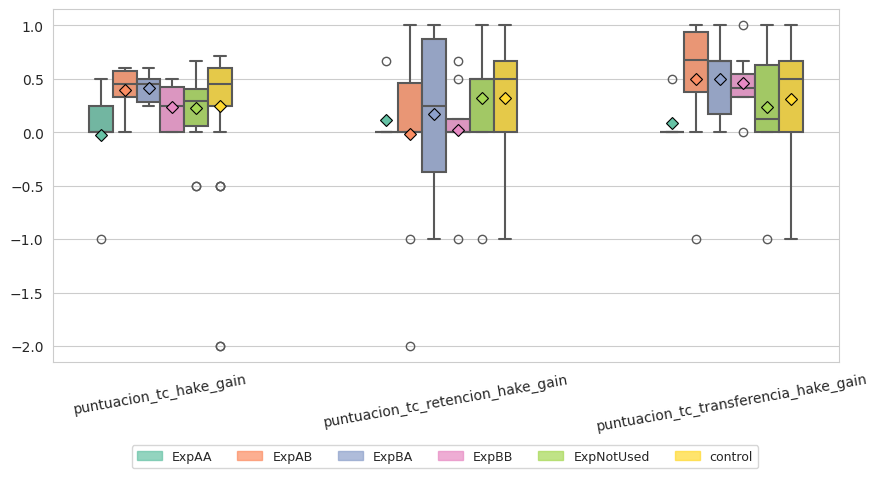

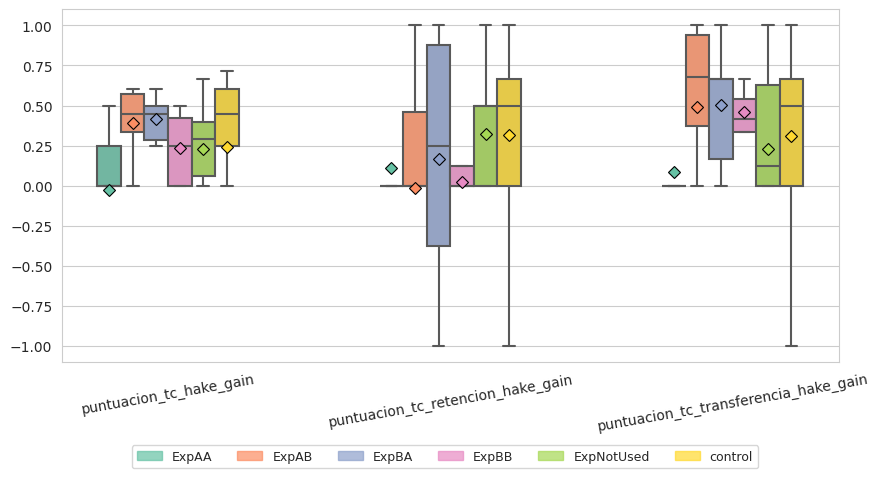

HIGH_QUALITY_USE

── CONDICIÓN: false ──

n = 37


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpAB""",25,0.68
"""ExpBB""",12,0.32


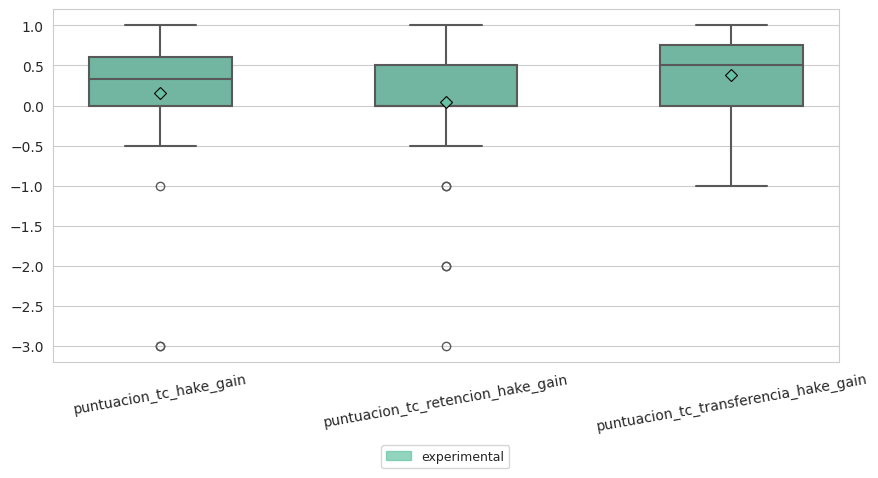

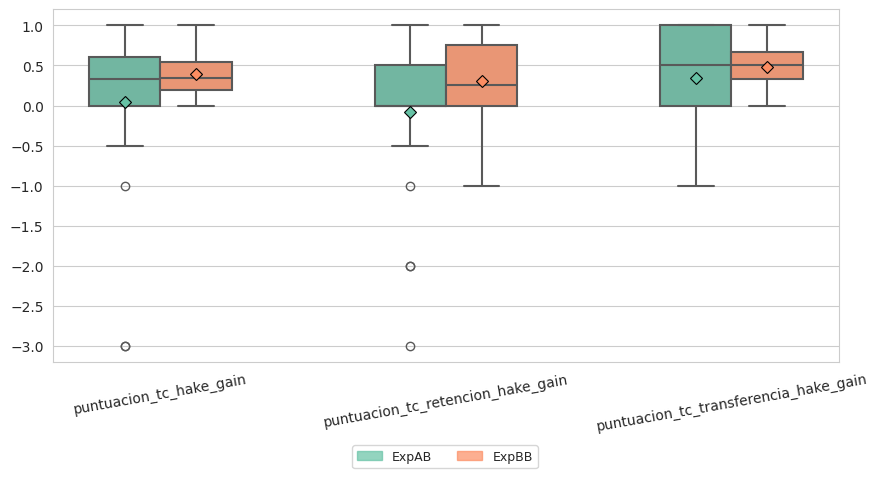

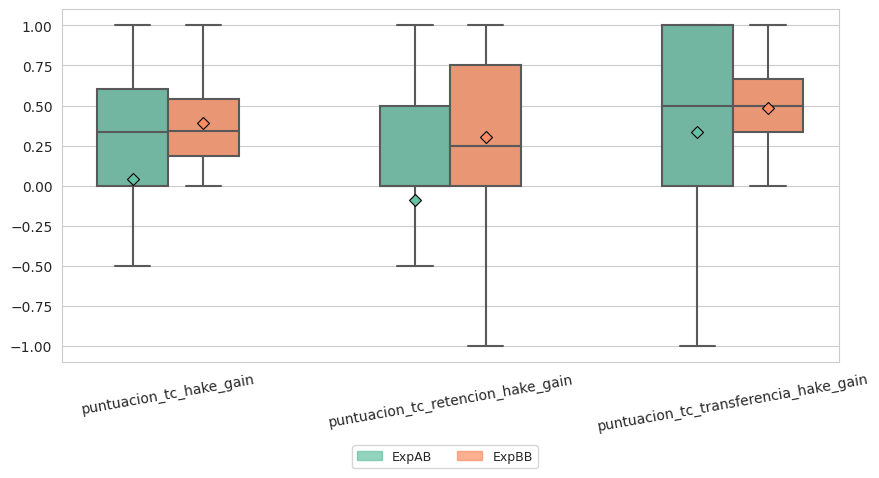


── CONDICIÓN: No Usado ──

n = 29


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpNotUsed""",29,1.0


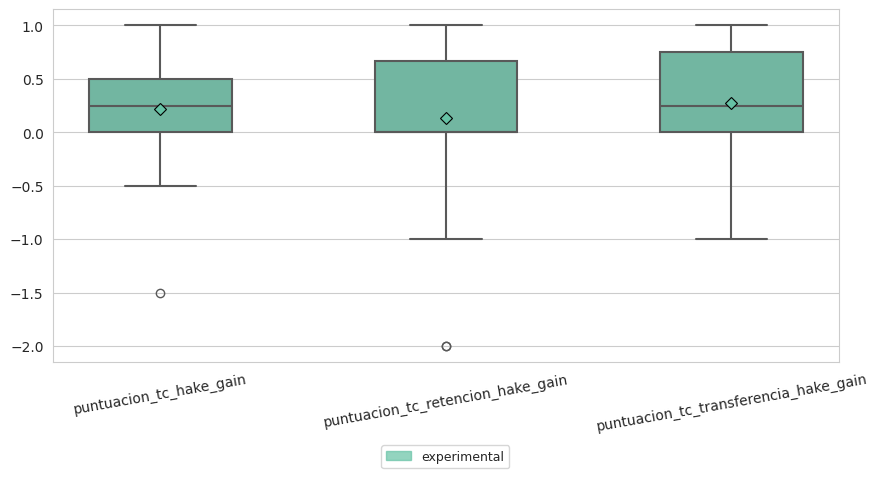

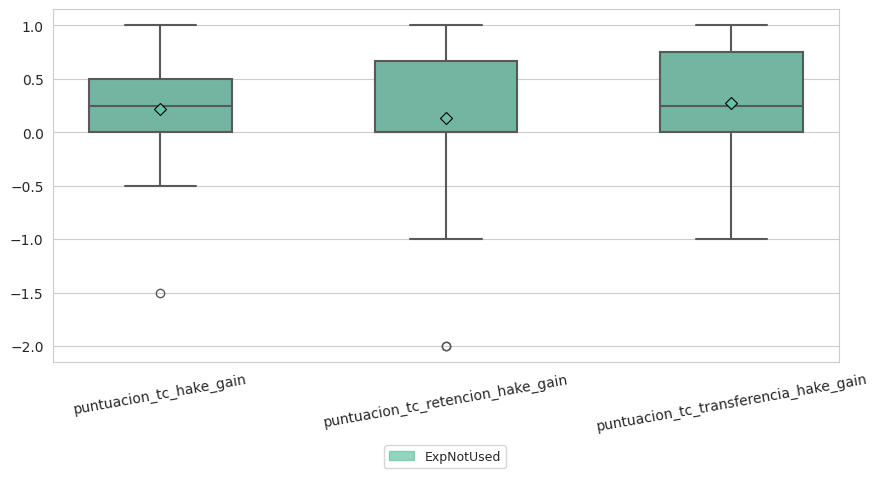

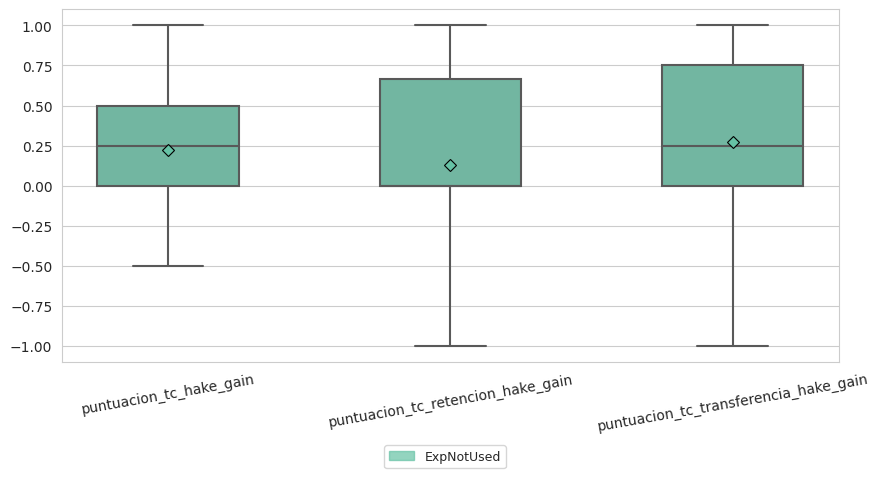


── CONDICIÓN: true ──

n = 25


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpBA""",13,0.52
"""ExpAA""",12,0.48


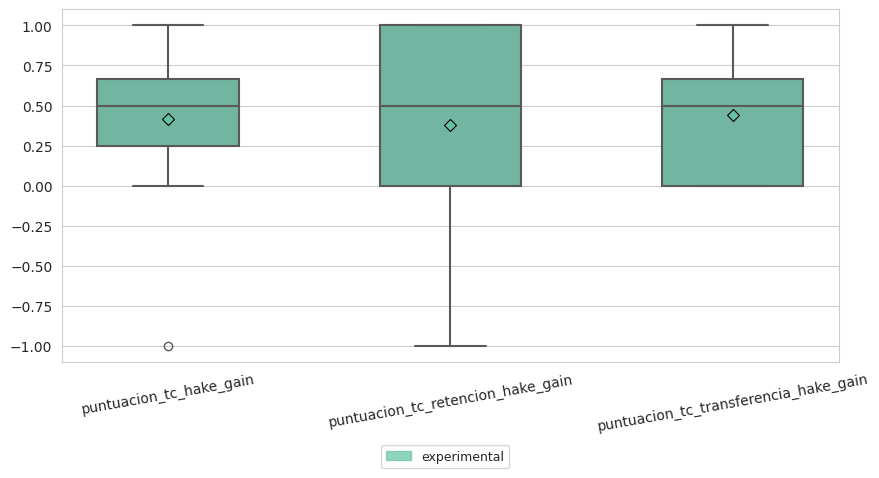

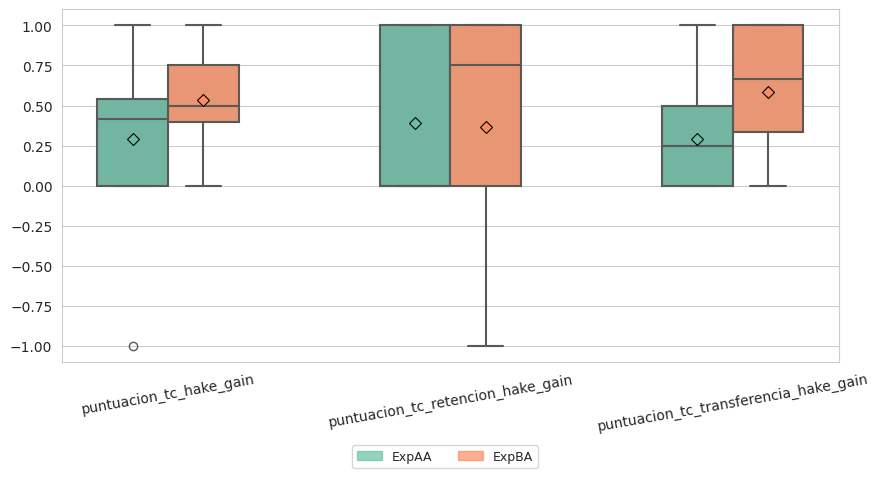

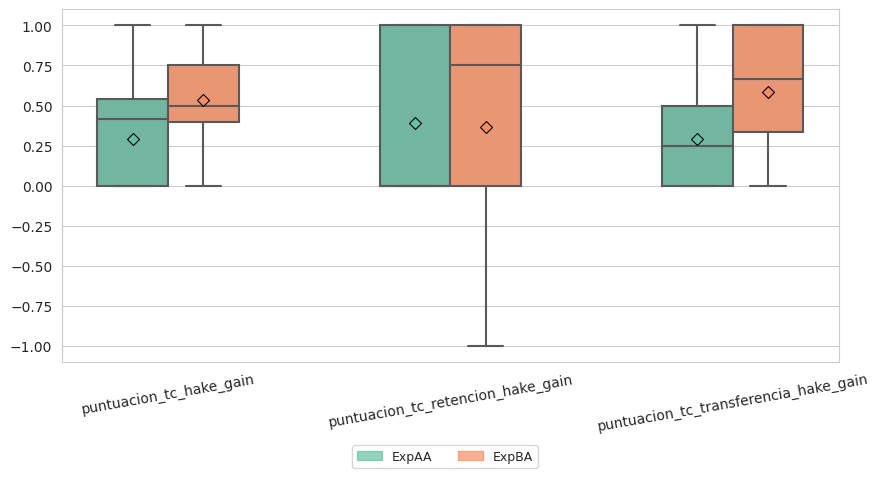

MEJORA

── CONDICIÓN: True ──

n = 137


grupo_segmented_v3,count,prop
str,u32,f64
"""ExpNotUsed""",18,0.13
"""control""",74,0.54
"""ExpAA""",8,0.06
"""ExpBB""",9,0.07
"""ExpBA""",12,0.09
"""ExpAB""",16,0.12


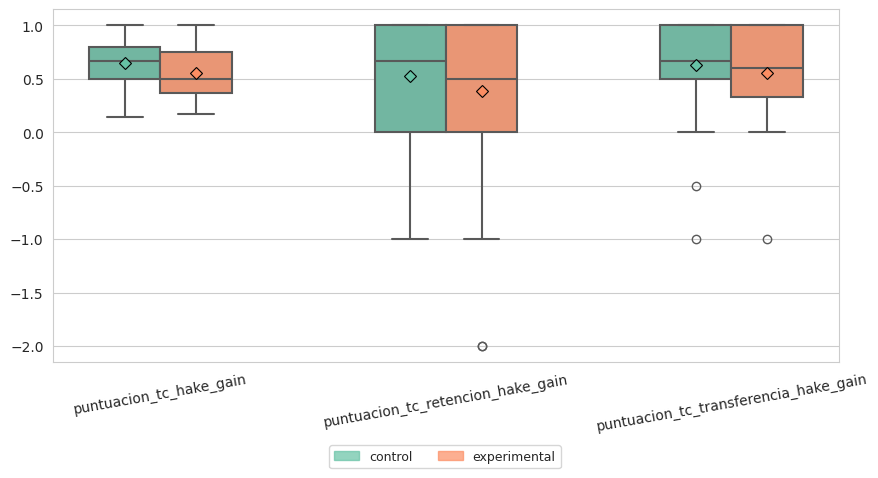

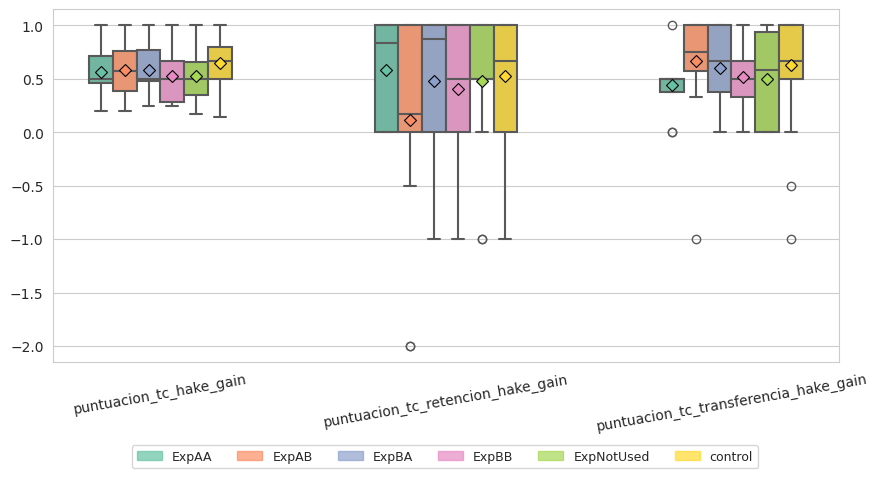

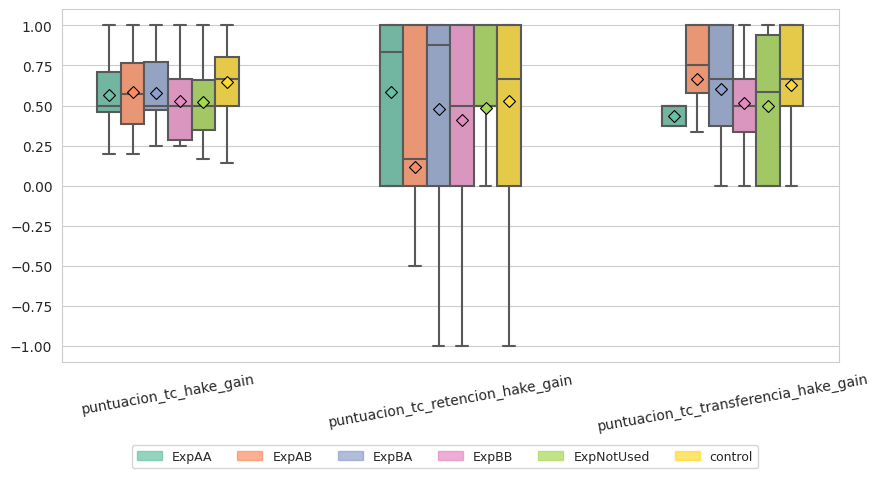

In [330]:
group_by_cols = [
    "centro",
    "puntuacion_tc_hake_gain_cat",
    "puntuacion_tcc_int_cat_post",
    "puntuacion_tcc_ext_cat_post",
    "puntuacion_tcc_rel_cat_post", 
    "puntuacion_ta_cat_pre",
    "puntuacion_ta_cat_post",
    "puntuacion_tc_cat_pre",
    "puntuacion_tc_cat_post",
    "puntuacion_tc_cat_trad_scale_pre",
    "puntuacion_tc_cat_trad_scale_post",
    "high_quality_use",
    "mejora"
    # TO DO: AÑADIR MÁS DE LAS NUEVAS VARIABLES
]


for col in group_by_cols:

    print("="*140)
    print(col.upper())
    print("="*140)

    col_vals = forms_interactions_df[col].unique().to_list()

    for value in col_vals:

        if value:

            df_filtered = (
                forms_interactions_df
                .filter(~pl.col('id').is_in(problematic_experimental_ids))
                .filter(pl.col(col) == value)
            )
            print(f"\n── CONDICIÓN: {value} ──\n")

            print(f"n = {len(df_filtered)}")
            display(df_filtered['grupo_segmented_v3'].value_counts().with_columns((pl.col('count') / pl.col('count').sum()).round(2).alias('prop')))

            plot_quant_comparison(
                figsize=(9, 4),
                df=df_filtered,
                comparisons=[
                    ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
                ],
                group_by='grupo',
                showfliers=True,
                title=False,
                labelbottom=True,
                xlabel_rotation=10,
                bbox_to_anchor=(0.5, -0.2)
            )

            plot_quant_comparison(
                figsize=(9, 4),
                df=df_filtered,
                comparisons=[
                    ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
                ],
                group_by='grupo_segmented_v3',
                showfliers=True,
                title=False,
                labelbottom=True,
                xlabel_rotation=10,
                bbox_to_anchor=(0.5, -0.2)
            )

            plot_quant_comparison(
                figsize=(9, 4),
                df=df_filtered,
                comparisons=[
                    ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
                ],
                group_by='grupo_segmented_v3',
                showfliers=False,
                title=False,
                labelbottom=True,
                xlabel_rotation=10,
                bbox_to_anchor=(0.5, -0.2)
            )